# Visualize nilearn GLM, 2nd level ROI analysis: Valuation (task)

In [2]:
import os
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from nilearn import image
from nilearn.image import load_img, math_img, threshold_img
from nilearn.plotting import (
    plot_stat_map, plot_glass_brain, plot_design_matrix,
    plot_anat, plot_img
)

# ---- Set these paths ----
OUTPUT_DIR = Path("/nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_task_valuation2")

# Optional: provide a template background; if None, nilearn will use MNI152 by default in some plots
BG_IMG = None  # e.g. "/path/to/MNI152_T1_2mm_brain.nii.gz"

# Subjects to QC (subset if you want)
SUBJECTS = None  # e.g. ["sub-007", "sub-030"]; None = auto-detect all in OUTPUT_DIR

# Contrasts you wrote in the GLM script
#CONTRASTS = ["Liked", "Disliked", "Neutral", "Liked_gt_Disliked", "Liked_gt_Neutral", "Value"]
CONTRASTS = ["stim_on", "resp", "outcome", "Value_init", "Value_Model_Derived"]


# Display defaults
DISPLAY_MODE = "ortho"
CUT_COORDS = (0, -20, 10)
Z_THRESHOLD = 3.1   # adjust
TOP_N_PEAKS = 10    # for peak table per map

# for anatomy
DERIVATIVES_ROOT = Path("/nfs/roberts/pi/pi_il77/Alex/foodvaluation/foodvaluation_BIDS/derivatives")

def subject_anat_bg(sub: str, ses: str = "1") -> Path | None:
    anat = (
        DERIVATIVES_ROOT
        / sub
        / f"ses-{ses}"
        / "anat"
        / f"{sub}_ses-{ses}_acq-mprage_space-MNI152NLin2009cAsym_res-2_desc-preproc_T1w.nii.gz"
    )
    return anat if anat.exists() else None


In [3]:
def list_subjects(output_dir: Path):
    if not output_dir.exists():
        print(f"[Error] OUTPUT_DIR does not exist: {output_dir}")
        return []
    subs = sorted([p.name for p in output_dir.glob("sub-*") if p.is_dir()])
    if len(subs) == 0:
        print(f"[Error] Found 0 sub-* folders under: {output_dir}")
        print("        Check that OUTPUT_DIR points to the directory that contains sub-XXX folders.")
    return subs

def find_maps_for_subject(output_dir: Path, sub: str):
    if sub is None:
        raise ValueError("sub is None. SUBJECTS is empty; fix OUTPUT_DIR or set SUB_TO_CHECK manually (e.g., 'sub-002').")
    out = {}
    sub_dir = output_dir / sub
    for contrast in CONTRASTS:
        out.setdefault(contrast, {})
        for maptype in ["z", "t", "effect", "variance"]:
            p = sub_dir / f"{sub}_{contrast}_{maptype}.nii.gz"
            if p.exists():
                out[contrast][maptype] = p
    return out

def find_design_matrices(output_dir: Path, sub: str):
    """Return list of (label, csv_path, png_path) for design matrices."""
    sub_dir = output_dir / sub
    csvs = sorted(sub_dir.glob(f"{sub}_*_design_matrix.csv"))
    results = []
    for csv_path in csvs:
        # label is whatever is between sub_ and _design_matrix.csv
        label = csv_path.name.replace(f"{sub}_", "").replace("_design_matrix.csv", "")
        png_path = sub_dir / f"{sub}_{label}_design_matrix.png"
        results.append((label, csv_path, png_path if png_path.exists() else None))
    return results

if SUBJECTS is None:
    SUBJECTS = list_subjects(OUTPUT_DIR)

print(f"Found {len(SUBJECTS)} subject folders under:\n  {OUTPUT_DIR}")
print("First few:", SUBJECTS[:10])

Found 50 subject folders under:
  /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_task_valuation2
First few: ['sub-002', 'sub-003', 'sub-004', 'sub-005', 'sub-006', 'sub-007', 'sub-008', 'sub-010', 'sub-011', 'sub-012']


In [4]:
def load_design_matrix(csv_path: Path) -> pd.DataFrame:
    dm = pd.read_csv(csv_path, index_col=0)
    return dm

def design_qc(dm: pd.DataFrame):
    """Return simple QC diagnostics for a design matrix."""
    # Identify suspicious columns: near-constant, huge variance, etc.
    variances = dm.var(axis=0)
    near_zero = variances[variances < 1e-8].index.tolist()

    # Correlation matrix (excluding constant if present)
    corr = dm.corr()
    # Max absolute correlation off-diagonal
    max_abs_corr = (corr.where(~np.eye(corr.shape[0], dtype=bool)).abs().max().max()
                    if corr.shape[0] > 1 else np.nan)

    return {
        "n_timepoints": dm.shape[0],
        "n_regressors": dm.shape[1],
        "near_zero_var_cols": near_zero,
        "max_abs_corr_offdiag": max_abs_corr,
    }

def show_design(sub: str, label: str, csv_path: Path):
    dm = load_design_matrix(csv_path)
    qc = design_qc(dm)

    # define fig_w based on number of regressors (columns)
    fig_w = max(12, dm.shape[1] * 0.35)
    fig_h = 15

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    plot_design_matrix(dm, ax=ax)
    
    ax.set_title(f"{sub} | {label}\n"
                 f"TP={qc['n_timepoints']}  Regr={qc['n_regressors']}  "
                 f"Max|r|={qc['max_abs_corr_offdiag']:.3f}  "
                 f"Near0Var={len(qc['near_zero_var_cols'])}")
    plt.tight_layout()
    plt.show()

    if qc["near_zero_var_cols"]:
        print("Near-zero variance columns (often OK for some confounds, but worth checking):")
        print(qc["near_zero_var_cols"][:50])


In [5]:
def img_basic_stats(img_path: Path):
    img = load_img(str(img_path))
    data = img.get_fdata()
    finite = np.isfinite(data)
    if finite.any():
        mn, mx = float(data[finite].min()), float(data[finite].max())
        mean, std = float(data[finite].mean()), float(data[finite].std())
    else:
        mn = mx = mean = std = np.nan
    return {
        "path": str(img_path),
        "shape": img.shape,
        "n_nan": int(np.size(data) - finite.sum()),
        "min": mn,
        "max": mx,
        "mean": mean,
        "std": std,
    }

def peak_table_from_z(z_img_path: Path, threshold=3.1, top_n=10):
    """
    Simple peak extraction without requiring masking/atlas:
    find top-N voxels by z value above threshold.
    """
    img = load_img(str(z_img_path))
    data = img.get_fdata()
    data = np.where(np.isfinite(data), data, -np.inf)
    mask = data > threshold
    if not np.any(mask):
        return pd.DataFrame(columns=["z", "i", "j", "k"])
    idx = np.argwhere(mask)
    vals = data[mask]
    order = np.argsort(vals)[::-1]
    idx = idx[order][:top_n]
    vals = vals[order][:top_n]
    return pd.DataFrame({"z": vals, "i": idx[:,0], "j": idx[:,1], "k": idx[:,2]})


In [6]:
# Replace plot_contrast_maps with this version (uses subject anat when available)
from IPython.display import display as ipy_display

def plot_contrast_maps(sub: str, contrast: str, maps: dict,
                       z_threshold=3.1, cut_coords=(0, -20, 10),
                       display_mode="ortho", bg_img=None, ses_for_anat="1"):
    if contrast not in maps or "z" not in maps[contrast]:
        print(f"[Missing] {sub} {contrast} z-map not found.")
        return

    z_path = maps[contrast]["z"]
    t_path = maps[contrast].get("t")
    eff_path = maps[contrast].get("effect")
    var_path = maps[contrast].get("variance")

    print(f"\n{sub} | {contrast}")
    print("Z map stats:", img_basic_stats(z_path))
    if t_path:   print("T map stats:", img_basic_stats(t_path))
    if eff_path: print("Effect map stats:", img_basic_stats(eff_path))
    if var_path: print("Variance map stats:", img_basic_stats(var_path))

    z_img = load_img(str(z_path))

    # Prefer subject-specific anat background for non-glassbrain plots
    subj_anat = subject_anat_bg(sub, ses=ses_for_anat)
    bg = subj_anat if subj_anat is not None else bg_img
    if subj_anat is None and bg_img is None:
        print("  [Note] No subject anat found and BG_IMG is None; background may look blank.")

    # Thresholded stat map (with anat background)
    plot_stat_map(
        z_img, bg_img=str(bg) if bg is not None else None,
        threshold=z_threshold, cut_coords=cut_coords, display_mode=display_mode,
        title=f"{sub} | {contrast} | z (thr={z_threshold})"
    )

    # Glass brain (background irrelevant)
    plot_glass_brain(
        z_img, threshold=z_threshold, display_mode="lyrz",
        title=f"{sub} | {contrast} | glass brain (thr={z_threshold})"
    )

    # Unthresholded stat map (with anat background)
    plot_stat_map(
        z_img, bg_img=str(bg) if bg is not None else None,
        threshold=None, cut_coords=cut_coords, display_mode=display_mode,
        title=f"{sub} | {contrast} | z (unthresholded)"
    )

    plt.show()

    peaks = peak_table_from_z(z_path, threshold=z_threshold, top_n=TOP_N_PEAKS)
    if len(peaks) == 0:
        print(f"No voxels above z>{z_threshold}.")
    else:
        print(f"Top peaks above z>{z_threshold}:")
        ipy_display(peaks)

# First Level

SUB_TO_CHECK = sub-005
Design matrices found: 1


/tmp/ipykernel_3954881/3045882041.py:33: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(dm, ax=ax)


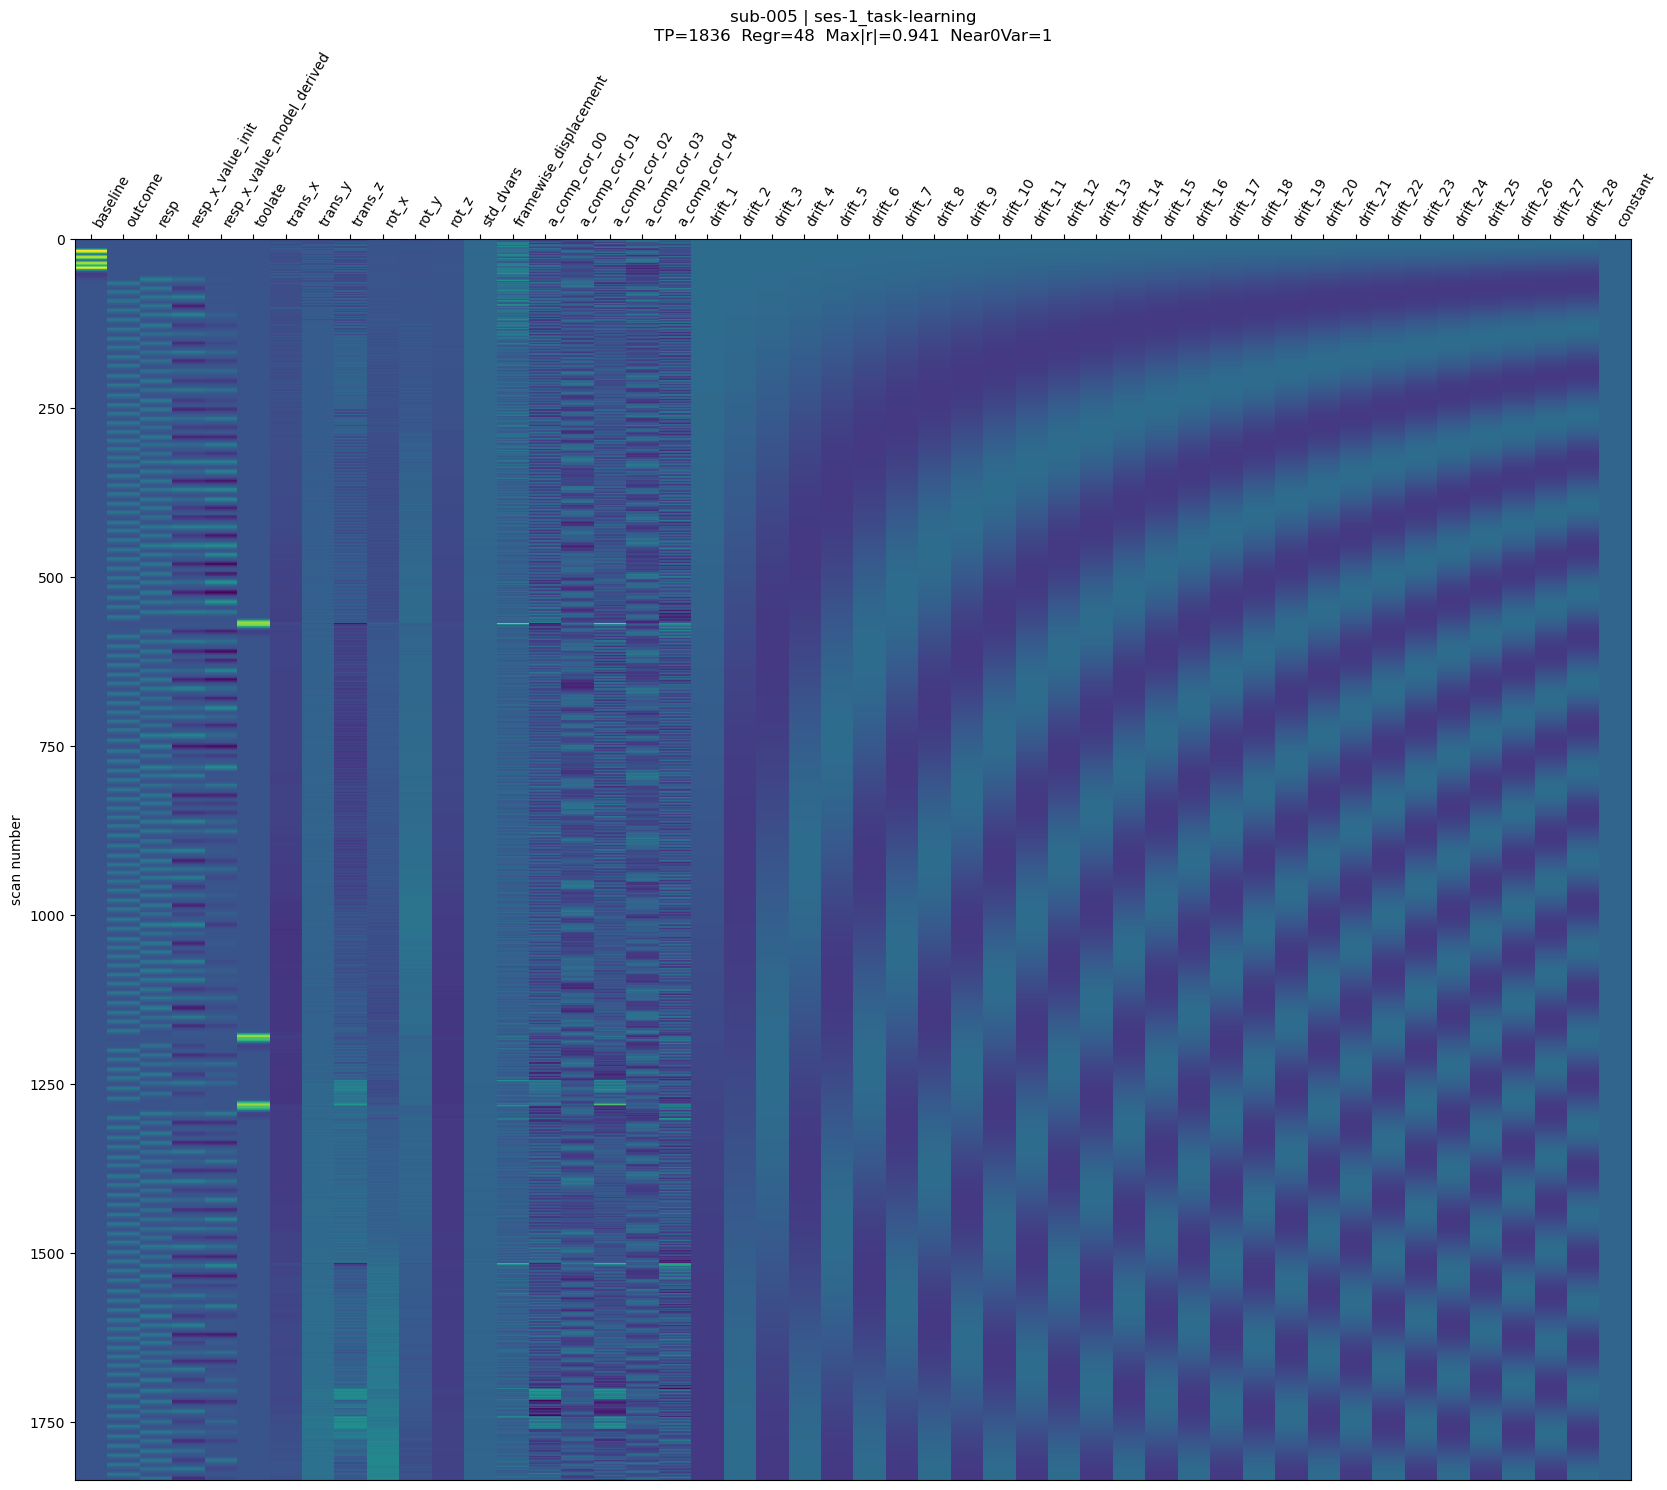

Near-zero variance columns (often OK for some confounds, but worth checking):
['constant']


In [7]:
SUB_TO_CHECK = SUBJECTS[3] if SUBJECTS else None
print("SUB_TO_CHECK =", SUB_TO_CHECK)

maps = find_maps_for_subject(OUTPUT_DIR, SUB_TO_CHECK)

# Design matrices
dms = find_design_matrices(OUTPUT_DIR, SUB_TO_CHECK)
print(f"Design matrices found: {len(dms)}")
for label, csv_path, png_path in dms:
    show_design(SUB_TO_CHECK, label, csv_path)

# Contrast maps
#for c in CONTRASTS:
#    plot_contrast_maps(
#        SUB_TO_CHECK, c, maps,
#        z_threshold=Z_THRESHOLD, cut_coords=CUT_COORDS,
#        display_mode=DISPLAY_MODE, bg_img=BG_IMG,
#        ses_for_anat="1"
#    )


# Second Level

In [15]:
def qc_inventory(output_dir: Path, subjects: list):
    rows = []
    for sub in subjects:
        sub_dir = output_dir / sub
        maps = find_maps_for_subject(output_dir, sub)
        dm = find_design_matrices(output_dir, sub)
        for contrast in CONTRASTS:
            row = {
                "sub": sub,
                "contrast": contrast,
                "has_z": int("z" in maps.get(contrast, {})),
                "has_t": int("t" in maps.get(contrast, {})),
                "has_effect": int("effect" in maps.get(contrast, {})),
                "has_variance": int("variance" in maps.get(contrast, {})),
                "n_design_matrices": len(dm),
                "sub_dir_exists": int(sub_dir.exists()),
            }
            rows.append(row)
    return pd.DataFrame(rows)

inv = qc_inventory(OUTPUT_DIR, SUBJECTS)
inv.head()

print("\nMissing z-maps (by contrast):")
missing = inv[inv["has_z"] == 0].groupby("contrast")["sub"].count().sort_values(ascending=False)
print(missing)

print("\nSubjects with 0 design matrices saved:")
print(inv.groupby("sub")["n_design_matrices"].max().loc[lambda s: s==0])




Missing z-maps (by contrast):
Series([], Name: sub, dtype: int64)

Subjects with 0 design matrices saved:
Series([], Name: n_design_matrices, dtype: int64)


In [16]:
MEAN_ANAT = Path("/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/sub_average.nii.gz")
BG_IMG = str(MEAN_ANAT) if MEAN_ANAT.exists() else BG_IMG

## Whole brain

In [ ]:
from pathlib import Path
import pandas as pd
from scipy.stats import norm

from nilearn.image import load_img
from nilearn.glm.second_level import SecondLevelModel
from nilearn.plotting import plot_stat_map, plot_glass_brain
import matplotlib.pyplot as plt

MEAN_ANAT = Path("/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/sub_average.nii.gz")
BG_IMG = str(MEAN_ANAT) if MEAN_ANAT.exists() else BG_IMG

def collect_existing_zmaps(output_dir: Path, subjects: list, contrast: str):
    paths = []
    for sub in subjects:
        p = output_dir / sub / f"{sub}_{contrast}_z.nii.gz"
        if p.exists():
            paths.append(str(p))
    return paths

def p_to_z(p, two_sided=True):
    return norm.isf(p / 2.0) if two_sided else norm.isf(p)

P_THR_MAIN  = 0.01
P_THR_GLASS = 0.01
TWO_SIDED = False

Z_THR_MAIN  = p_to_z(P_THR_MAIN,  two_sided=TWO_SIDED)
Z_THR_GLASS = p_to_z(P_THR_GLASS, two_sided=TWO_SIDED)

# --- choose what to run ---
SELECT_CONTRASTS = ["Value_init"]   # e.g., ["food>baseline"]

for contrast in SELECT_CONTRASTS:
    paths = collect_existing_zmaps(OUTPUT_DIR, SUBJECTS, contrast)
    if not paths:
        print(f"No z-maps found for contrast={contrast}")
        continue

    imgs = [load_img(p) for p in paths]
    design_matrix = pd.DataFrame({"intercept": [1] * len(imgs)})

    slm = SecondLevelModel(smoothing_fwhm=None).fit(imgs, design_matrix=design_matrix)
    z_map = slm.compute_contrast(second_level_contrast="intercept", output_type="z_score")

    plot_stat_map(
        z_map, bg_img=BG_IMG, cmap="inferno", threshold=Z_THR_MAIN,
        cut_coords=CUT_COORDS, display_mode=DISPLAY_MODE,
        title=f"2nd-level z | {contrast} (N={len(imgs)}) | p<{P_THR_MAIN} ({'2s' if TWO_SIDED else '1s'})"
    )
#    plot_glass_brain(
#        z_map, threshold=Z_THR_GLASS, display_mode="lyrz",
#        title=f"2nd-level z glass | {contrast} (N={len(imgs)}) | p<{P_THR_GLASS} ({'2s' if TWO_SIDED else '1s'})"
#    )
#    plt.show()

#    z_map.to_filename(str(OUTPUT_DIR / f"secondlevel_{contrast}_z.nii.gz"))

## Concetate into 4D image

In [26]:
import os
from pathlib import Path
import numpy as np
import nibabel as nib
from nilearn.image import load_img, concat_imgs
from nilearn import plotting

# -----------------------------
# Build a 4D image by concatenating 1st-level "Value" contrast maps (one per subject)
# so you can extract ROI means per subject with your NiftiMasker code.
# -----------------------------

# Set these to match your filenames
firstlevel_dir = Path(OUTPUT_DIR)
contrast_name = "Value_init"                                      
# Example expected file per subject:
#   <firstlevel_dir>/<sub>/<sub>_Value_con.nii.gz
# or adjust pattern below to match your pipeline.

def collect_firstlevel_contrasts(firstlevel_dir: Path, subjects: list, contrast: str):
    paths = []
    missing = []
    for sub in subjects:
        p = firstlevel_dir / sub / f"{sub}_{contrast}_effect.nii.gz"
        if p.exists():
            paths.append(str(p))
        else:
            missing.append(str(p))
    return paths, missing

# Collect subject maps
con_paths, missing = collect_firstlevel_contrasts(firstlevel_dir, SUBJECTS, contrast_name)

print(f"Found {len(con_paths)} subject maps for {contrast_name}")
if missing:
    print("Missing (showing up to 10):")
    for m in missing[:10]:
        print("  ", m)

if len(con_paths) == 0:
    raise RuntimeError("No first-level contrast maps found; fix firstlevel_dir/pattern/contrast_name.")

# Concatenate into a single 4D image: (X, Y, Z, Nsubjects)
con_imgs_4d = concat_imgs(con_paths)

# Save the 4D image for downstream ROI extraction/plotting
out_4d_path = Path(OUTPUT_DIR) / f"none_glm_{contrast_name}_all_sub_4d.nii.gz"
out_4d_path.parent.mkdir(parents=True, exist_ok=True)
con_imgs_4d.to_filename(str(out_4d_path))
print(f"Saved 4D concatenated image to: {out_4d_path}")


# Now point your extraction code at:
functional_img_path = str(out_4d_path)
print("Use this as functional_img_path:", functional_img_path)

Found 50 subject maps for Value_init
Saved 4D concatenated image to: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_task_valuation2/none_glm_Value_init_all_sub_4d.nii.gz
Use this as functional_img_path: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_task_valuation2/none_glm_Value_init_all_sub_4d.nii.gz


## ROI: nilearn parametric ROI obtained from food item ratings

### nilearn Value paramatric ROI

#### Value_init

/tmp/ipykernel_4178481/1690373068.py:14: DeprecationWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn import input_data, plotting


ROI voxels: 528


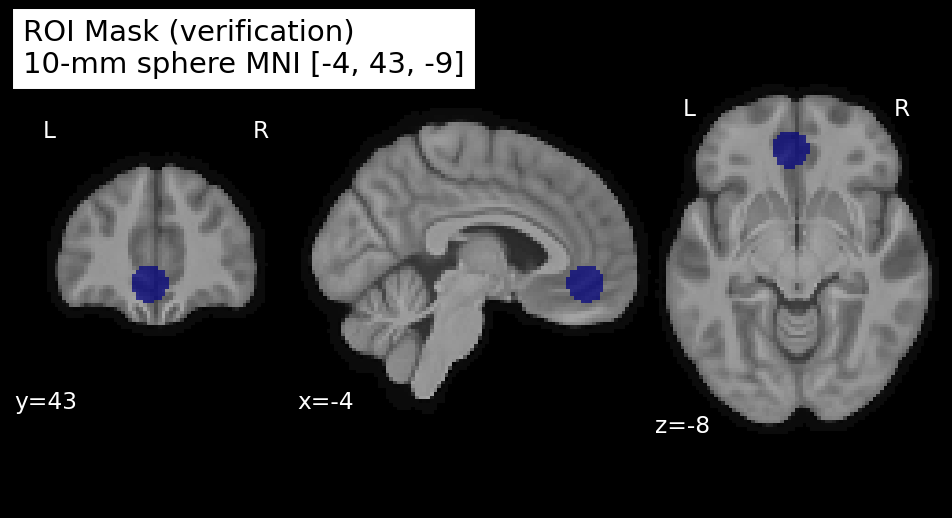

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures/roi41sphere_r10mm_ROIMaskOverlay.jpeg

One-sample ROI test (Value_init)
Contrast (key): Value_init
Contrast (label): Initial Value
Functional: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_task_valuation2/none_glm_Value_init_all_sub_4d.nii.gz
ROI mask: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz
ROI: 10-mm sphere MNI [-4, 43, -9]
N=50, df=49
Mean ROI signal: -0.004703 (SD=0.053083, SEM=0.007507)
t(49) = -0.626, p(two-sided) = 0.5339
p(one-sided, mean>0) = 0.7331
Cohen's d = -0.089
95% CI for mean: [-0.019789, 0.010383]


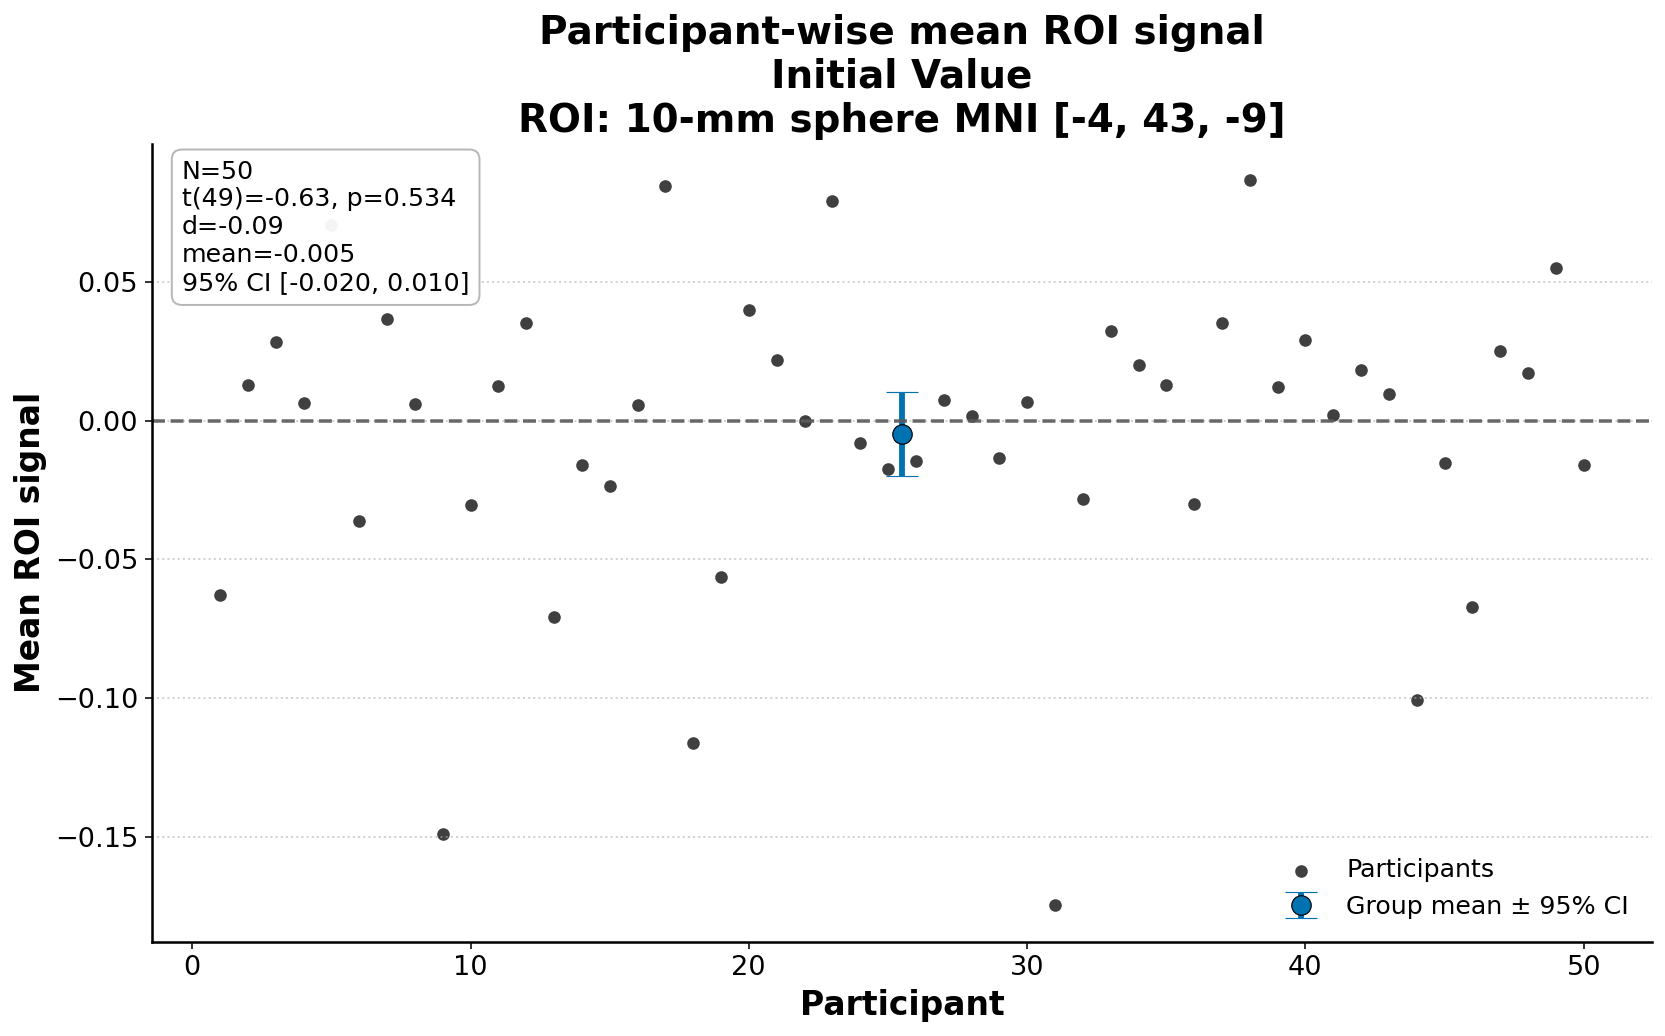

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures/roi41sphere_r10mm_Initial_Value_ParticipantScatter_MeanCI.jpeg


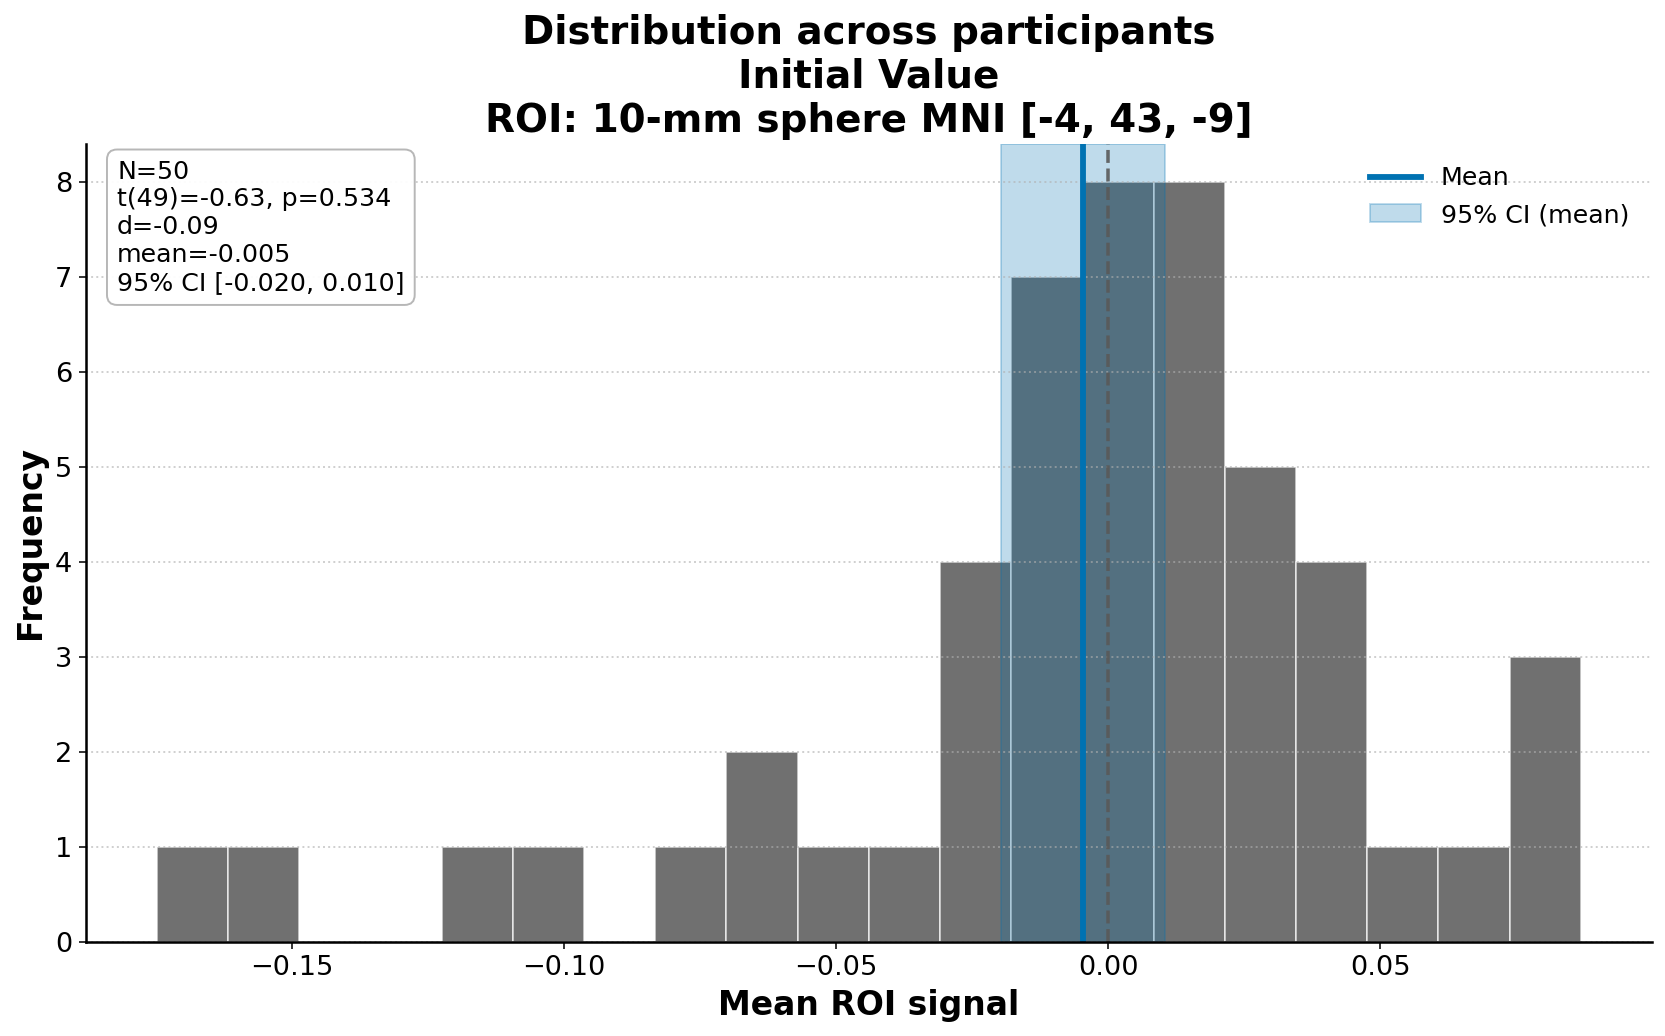

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures/roi41sphere_r10mm_Initial_Value_Histogram_MeanCI.jpeg


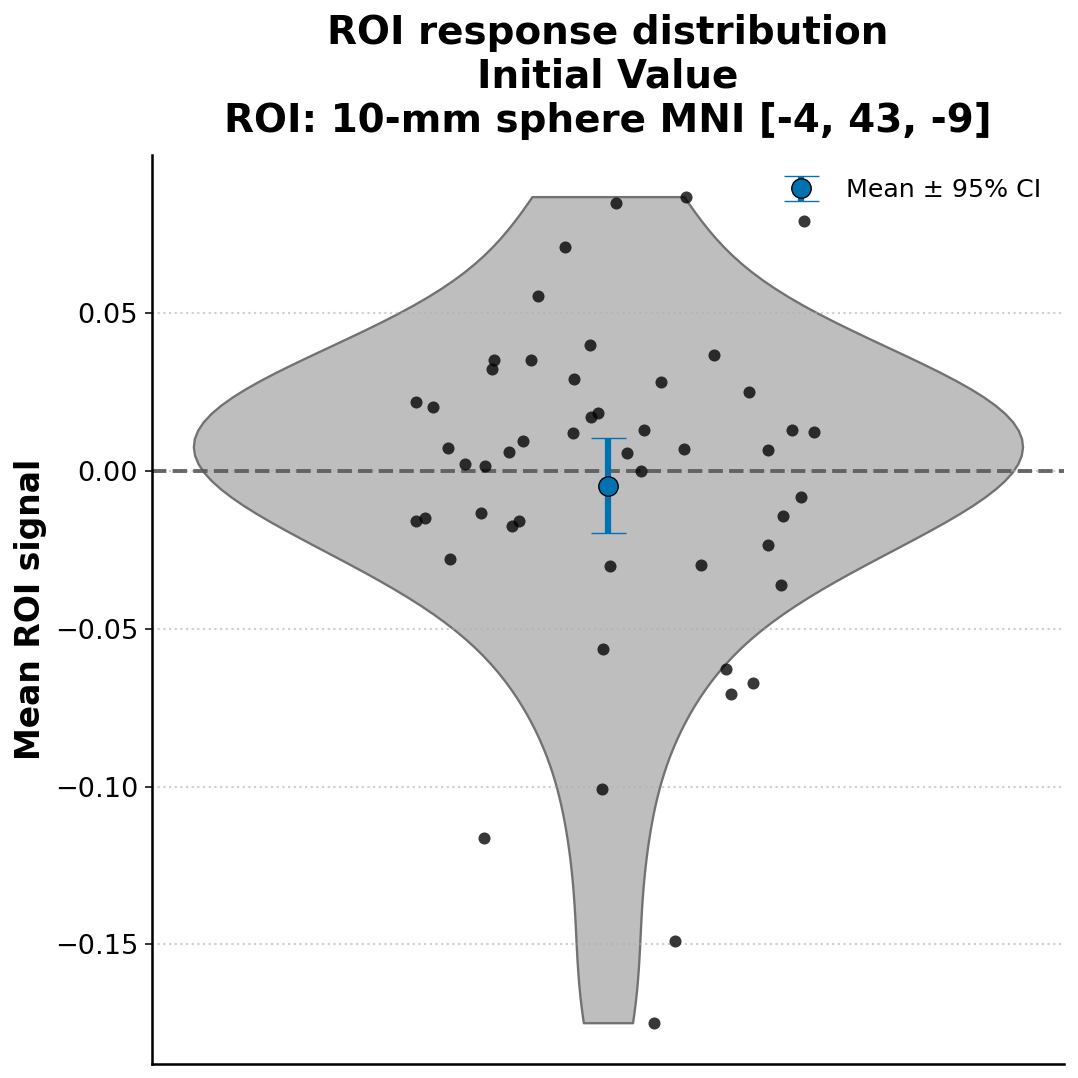

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures/roi41sphere_r10mm_Initial_Value_ViolinPoints_MeanCI.jpeg


In [8]:
# Value_init ROI test
# - Uses existing saved sphere ROI mask
# - Saves figures: ROI overlay + participant scatter (mean ± 95% CI) + histogram (mean ± 95% CI) + violin (mean ± 95% CI)
# - One-sample t-test vs 0 + Cohen's d + 95% CI (t-based)
#
# Saves to:
# /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures

import os
import re
import numpy as np
import nibabel as nib
import seaborn as sns
from nilearn import input_data, plotting
from nilearn.image import load_img
from scipy import stats
import matplotlib.pyplot as plt

# -----------------------
# Helpers: stats + CI + effect size + filenames
# -----------------------
def mean_ci_t(x, confidence=0.95):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.size
    mean = float(np.mean(x))
    sem = float(stats.sem(x))
    df = n - 1
    tcrit = float(stats.t.ppf((1 + confidence) / 2, df))
    half = tcrit * sem
    return mean, (mean - half, mean + half)

def cohens_d_onesample(x, mu0=0.0):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    sd = float(np.std(x, ddof=1))
    return float((np.mean(x) - mu0) / sd) if sd != 0 else np.nan

def safe_filename(s: str, maxlen: int = 140) -> str:
    s = s.strip()
    s = s.replace(">", "gt").replace("<", "lt")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s[:maxlen]

# -----------------------
# Settings (readability + high-def saving)
# -----------------------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "axes.titlesize": 20,
    "axes.titleweight": "bold",
    "axes.labelsize": 17,
    "axes.labelweight": "bold",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "axes.linewidth": 1.3,
})

MEAN_COLOR = "#0072B2"   # Okabe–Ito blue
ZERO_COLOR = "0.35"
VIOLIN_COLOR = "#BEBEBE"

# -----------------------
# Inputs
# -----------------------
contrast_key = "Value_init"
contrast_label = "Initial Value"  # <<< display label on plots (requested)

functional_img_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_init_all_sub_4d.nii.gz")
roi_mask_path = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz"

anat_img = load_img(str(MEAN_ANAT))  # for overlay background + consistent geometry display

# Filenames
contrast_slug = safe_filename(contrast_label)

coords = (-4, 43, -9)
roi_label_plot = f"10-mm sphere MNI [{coords[0]}, {coords[1]}, {coords[2]}]"

# Keep filenames stable/short
roi_slug = safe_filename("roi41sphere_r10mm")

# -----------------------
# Output folder
# -----------------------
FIG_DIR = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures"
os.makedirs(FIG_DIR, exist_ok=True)

# -----------------------
# Load data
# -----------------------
functional_img = nib.load(functional_img_path)
roi_mask_img = nib.load(roi_mask_path)

print("ROI voxels:", int(np.sum(roi_mask_img.get_fdata() > 0)))

# -----------------------
# Figure 1: ROI mask overlay (SHOW + SAVE; no colorbar)
# -----------------------
display = plotting.plot_roi(
    roi_mask_img,
    bg_img=anat_img,
    title=f"ROI Mask (verification)\n{roi_label_plot}",
    display_mode="ortho",
    draw_cross=False,
    colorbar=False
)

plotting.show()

roi_plot_title = "ROIMaskOverlay"
roi_out = os.path.join(FIG_DIR, f"{roi_slug}_{roi_plot_title}.jpeg")
display.savefig(roi_out, dpi=600)
display.close()
print(f"[OK] Saved: {roi_out}")

# -----------------------
# Extract mean ROI signal per subject
# -----------------------
masker = input_data.NiftiMasker(mask_img=roi_mask_img, standardize=False)
roi_vox = masker.fit_transform(functional_img)  # (n_subjects, n_voxels)
x = np.asarray(roi_vox.mean(axis=1)).ravel().astype(float)
x = x[~np.isnan(x)]

n = int(x.size)
df = n - 1

# -----------------------
# One-sample stats vs 0
# -----------------------
group_mean = float(np.mean(x))
group_sd = float(np.std(x, ddof=1))
group_sem = float(stats.sem(x))

t_stat, p_val = stats.ttest_1samp(x, popmean=0.0, nan_policy="omit")
t_stat = float(t_stat)
p_val = float(p_val)

d = cohens_d_onesample(x, mu0=0.0)
_, (ci_lo, ci_hi) = mean_ci_t(x, confidence=0.95)

# One-sided p for H1: mean > 0 (optional; printed for completeness)
p_one_sided = (p_val / 2.0) if (t_stat > 0) else (1.0 - p_val / 2.0)

print("\nOne-sample ROI test (Value_init)")
print(f"Contrast (key): {contrast_key}")
print(f"Contrast (label): {contrast_label}")
print(f"Functional: {functional_img_path}")
print(f"ROI mask: {roi_mask_path}")
print(f"ROI: {roi_label_plot}")
print(f"N={n}, df={df}")
print(f"Mean ROI signal: {group_mean:.6f} (SD={group_sd:.6f}, SEM={group_sem:.6f})")
print(f"t({df}) = {t_stat:.3f}, p(two-sided) = {p_val:.4g}")
print(f"p(one-sided, mean>0) = {p_one_sided:.4g}")
print(f"Cohen's d = {d:.3f}")
print(f"95% CI for mean: [{ci_lo:.6f}, {ci_hi:.6f}]")

stats_text = (
    f"N={n}\n"
    f"t({df})={t_stat:.2f}, p={p_val:.3g}\n"
    f"d={d:.2f}\n"
    f"mean={group_mean:.3f}\n"
    f"95% CI [{ci_lo:.3f}, {ci_hi:.3f}]"
)

# -----------------------
# Figure 2: participant scatter + mean ± 95% CI (SAVE)
# -----------------------
fig1, ax1 = plt.subplots(figsize=(12, 7.5))
x_subjects = np.arange(1, n + 1)

ax1.scatter(
    x_subjects, x,
    color="black", alpha=0.75, s=42, linewidths=0,
    label="Participants"
)

ax1.errorbar(
    x=float(np.mean(x_subjects)),
    y=group_mean,
    yerr=np.array([[group_mean - ci_lo], [ci_hi - group_mean]]),
    fmt="o",
    color=MEAN_COLOR,
    ecolor=MEAN_COLOR,
    elinewidth=3.0,
    capsize=8,
    markersize=10,
    markeredgecolor="black",
    markeredgewidth=0.6,
    label="Group mean ± 95% CI"
)

ax1.axhline(y=0, color=ZERO_COLOR, linestyle="--", linewidth=1.8, alpha=0.9)
ax1.set_xlabel("Participant")
ax1.set_ylabel("Mean ROI signal")

plot1_title = "ParticipantScatter_MeanCI"
ax1.set_title(f"Participant-wise mean ROI signal\n{contrast_label}\nROI: {roi_label_plot}")

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)

ax1.text(
    0.02, 0.98, stats_text,
    transform=ax1.transAxes, va="top", ha="left",
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.40", facecolor="white", edgecolor="0.7", alpha=0.95)
)

ax1.legend(frameon=False, loc="lower right")
plt.tight_layout()

fname1 = f"{roi_slug}_{contrast_slug}_{plot1_title}.jpeg"
out1 = os.path.join(FIG_DIR, fname1)
fig1.savefig(out1, format="jpeg", dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {out1}")

# -----------------------
# Figure 3: histogram + mean and 95% CI (SAVE)
# -----------------------
fig2, ax2 = plt.subplots(figsize=(12, 7.5))

ax2.hist(x, bins=20, color="0.25", alpha=0.75, edgecolor="white", linewidth=0.8)
ax2.axvline(x=0, color=ZERO_COLOR, linestyle="--", linewidth=1.8, alpha=0.9)

ax2.axvline(group_mean, color=MEAN_COLOR, linewidth=3.0, label="Mean")
ax2.axvspan(ci_lo, ci_hi, color=MEAN_COLOR, alpha=0.25, label="95% CI (mean)")

ax2.set_xlabel("Mean ROI signal")
ax2.set_ylabel("Frequency")

plot2_title = "Histogram_MeanCI"
ax2.set_title(f"Distribution across participants\n{contrast_label}\nROI: {roi_label_plot}")

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)

ax2.text(
    0.02, 0.98, stats_text,
    transform=ax2.transAxes, va="top", ha="left",
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.40", facecolor="white", edgecolor="0.7", alpha=0.95)
)

ax2.legend(frameon=False, loc="upper right")
plt.tight_layout()

fname2 = f"{roi_slug}_{contrast_slug}_{plot2_title}.jpeg"
out2 = os.path.join(FIG_DIR, fname2)
fig2.savefig(out2, format="jpeg", dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {out2}")

# -----------------------
# Figure 4: violin + subject points + mean ± 95% CI (SAVE)
# -----------------------
figV, axV = plt.subplots(figsize=(7.8, 7.8))

sns.violinplot(
    y=x,
    ax=axV,
    color=VIOLIN_COLOR,
    inner=None,
    cut=0,
    linewidth=1.2
)

sns.stripplot(
    y=x,
    ax=axV,
    color="black",
    alpha=0.78,
    jitter=0.20,
    size=6.2,
    zorder=4
)

axV.errorbar(
    x=0,
    y=group_mean,
    yerr=np.array([[group_mean - ci_lo], [ci_hi - group_mean]]),
    fmt="o",
    color=MEAN_COLOR,
    ecolor=MEAN_COLOR,
    elinewidth=3.2,
    capsize=9,
    markersize=10,
    markeredgecolor="black",
    markeredgewidth=0.7,
    zorder=5,
    label="Mean ± 95% CI"
)

axV.axhline(0, color=ZERO_COLOR, linestyle="--", linewidth=2.0, alpha=0.9)
axV.set_xticks([])
axV.set_xlabel("")
axV.set_ylabel("Mean ROI signal")

violin_title = "ViolinPoints_MeanCI"
axV.set_title(f"ROI response distribution\n{contrast_label}\nROI: {roi_label_plot}", pad=12)

axV.spines["top"].set_visible(False)
axV.spines["right"].set_visible(False)
axV.grid(True, axis="y", linestyle=":", linewidth=1.1, alpha=0.6)
axV.legend(frameon=False, loc="upper right")

plt.tight_layout()
outV = os.path.join(FIG_DIR, f"{roi_slug}_{contrast_slug}_{violin_title}.jpeg")
figV.savefig(outV, format="jpeg", dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {outV}")

#### Value_Model_Derived

/tmp/ipykernel_3235106/1429223541.py:14: DeprecationWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn import input_data, plotting


ROI voxels: 528


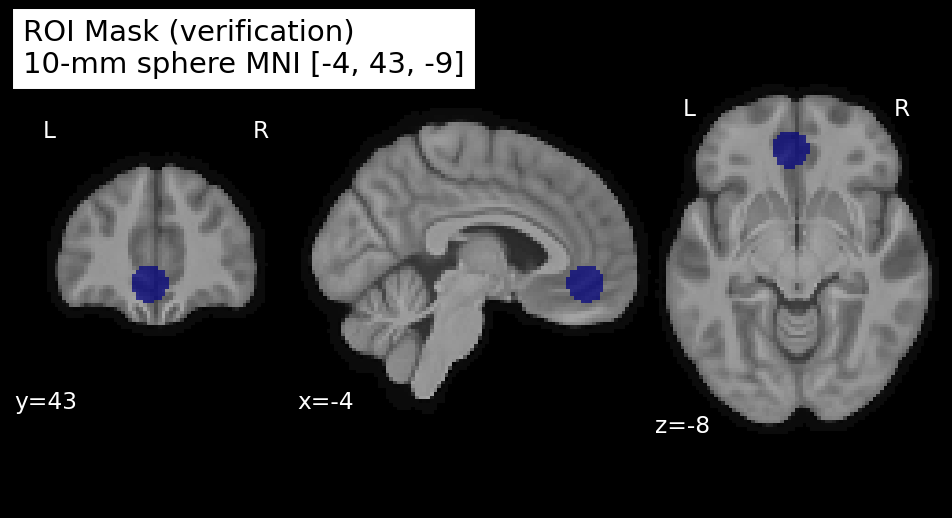

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_Model_Derived_figures/roi41sphere_r10mm_ROIMaskOverlay.jpeg

One-sample ROI test (Value_init)
Contrast (key): Value_Model_Derived
Contrast (label): Model-Derived Value
Functional: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_task_valuation2/none_glm_Value_Model_Derived_all_sub_4d.nii.gz
ROI mask: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz
ROI: 10-mm sphere MNI [-4, 43, -9]
N=50, df=49
Mean ROI signal: 0.039409 (SD=0.457909, SEM=0.064758)
t(49) = 0.609, p(two-sided) = 0.5456
p(one-sided, mean>0) = 0.2728
Cohen's d = 0.086
95% CI for mean: [-0.090727, 0.169545]


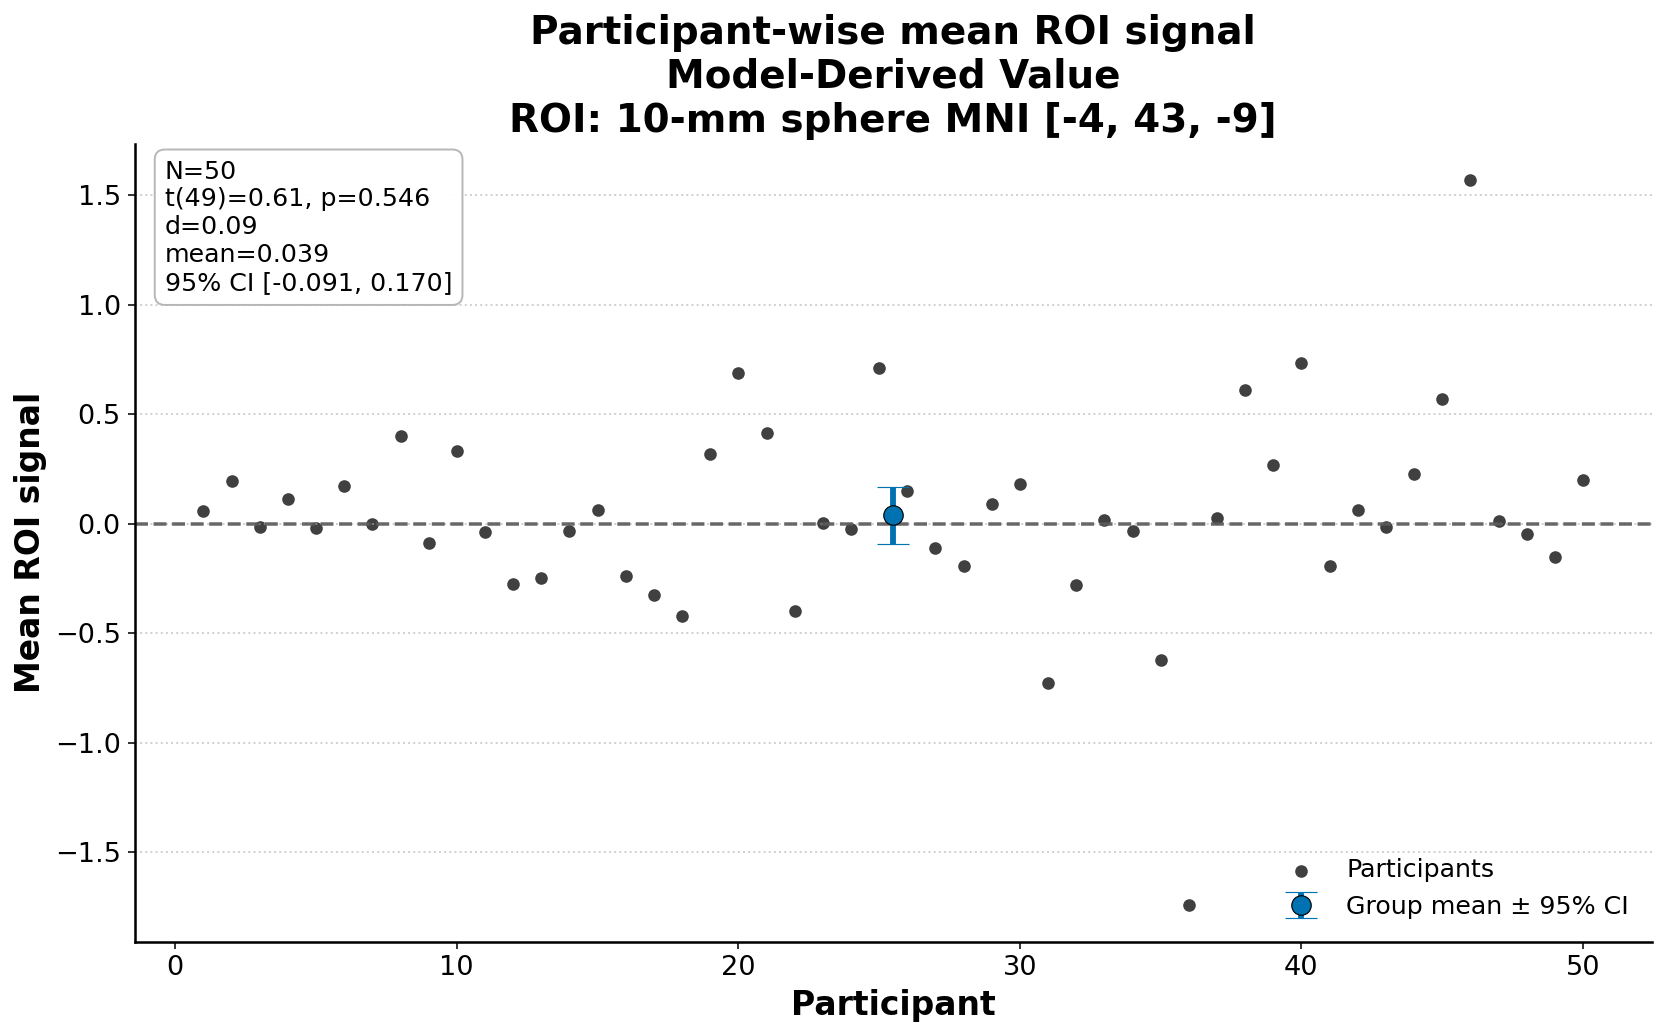

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_Model_Derived_figures/roi41sphere_r10mm_Model-Derived_Value_ParticipantScatter_MeanCI.jpeg


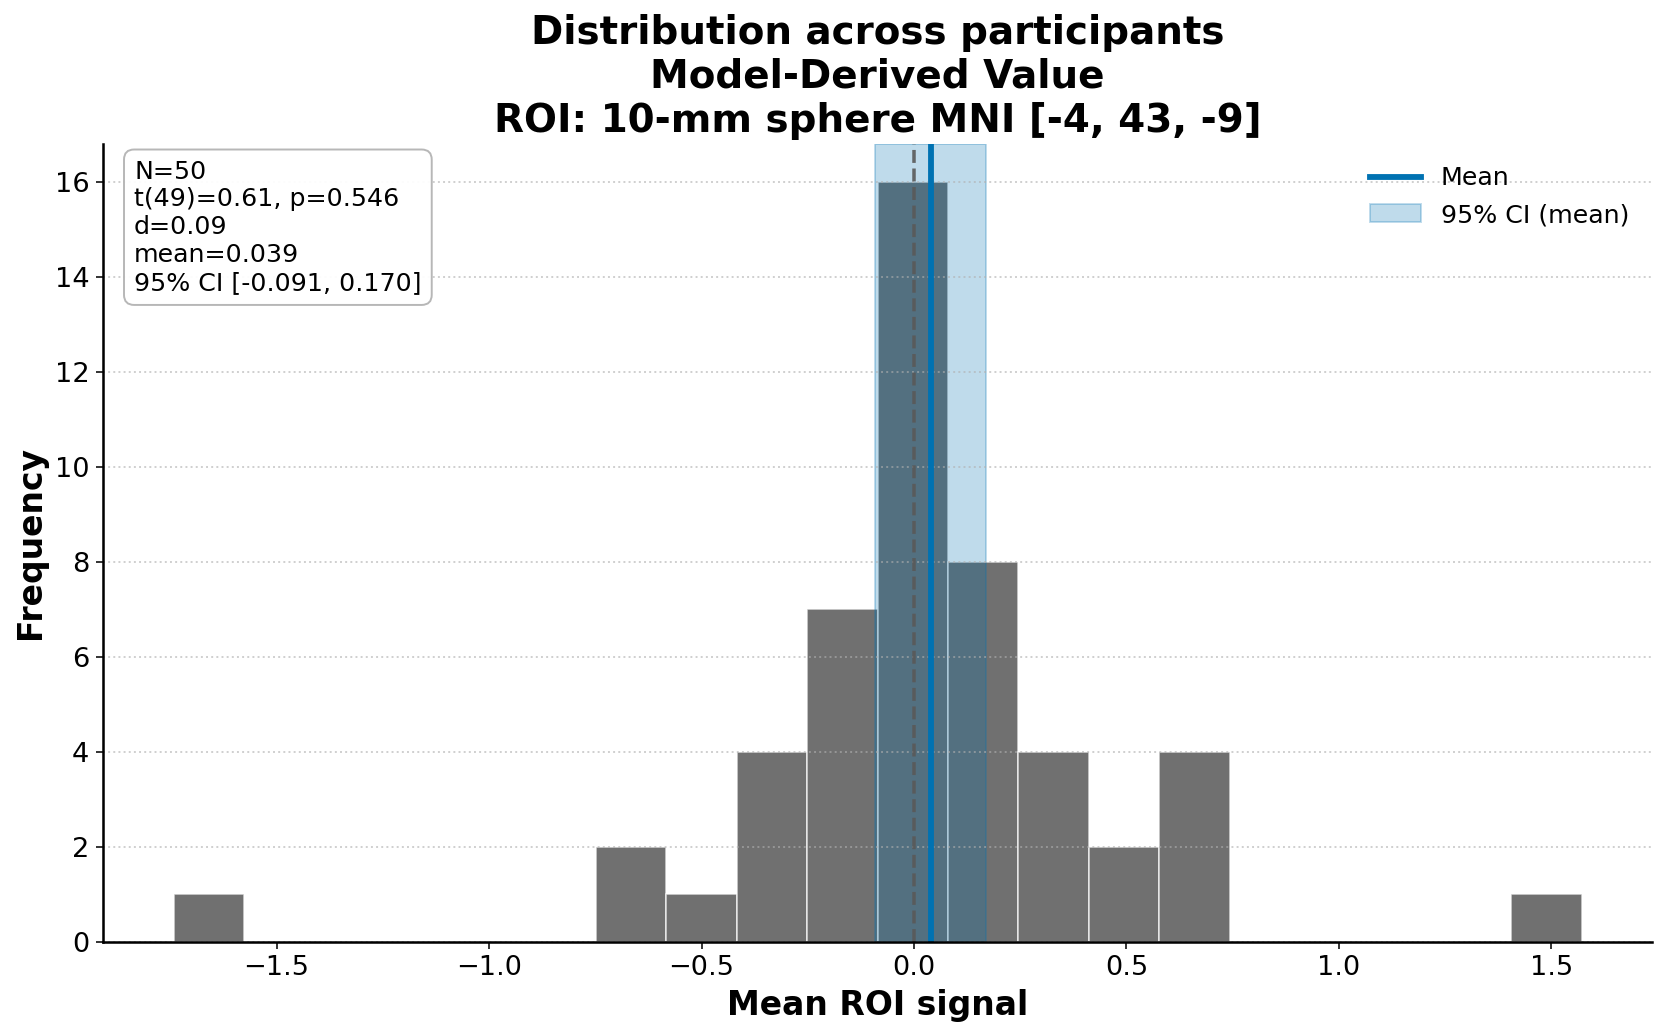

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_Model_Derived_figures/roi41sphere_r10mm_Model-Derived_Value_Histogram_MeanCI.jpeg


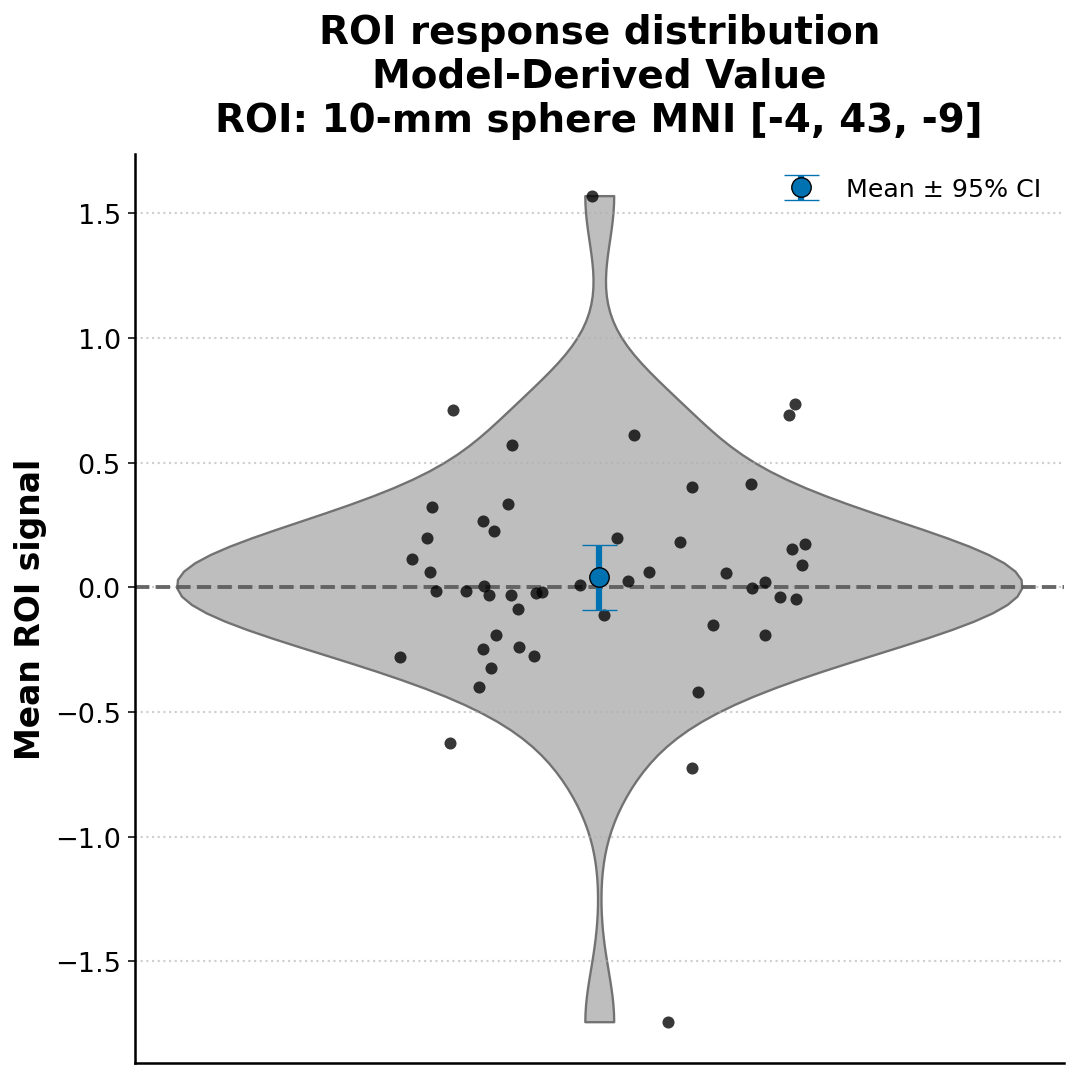

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_Model_Derived_figures/roi41sphere_r10mm_Model-Derived_Value_ViolinPoints_MeanCI.jpeg


In [20]:
# Value_init ROI test — formatted/saved like your other ROI scripts
# - Uses existing saved sphere ROI mask
# - Saves figures: ROI overlay + participant scatter (mean ± 95% CI) + histogram (mean ± 95% CI) + violin (mean ± 95% CI)
# - One-sample t-test vs 0 + Cohen's d + 95% CI (t-based)
#
# Saves to:
# /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures

import os
import re
import numpy as np
import nibabel as nib
import seaborn as sns
from nilearn import input_data, plotting
from nilearn.image import load_img
from scipy import stats
import matplotlib.pyplot as plt

# -----------------------
# Helpers: stats + CI + effect size + filenames
# -----------------------
def mean_ci_t(x, confidence=0.95):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.size
    mean = float(np.mean(x))
    sem = float(stats.sem(x))
    df = n - 1
    tcrit = float(stats.t.ppf((1 + confidence) / 2, df))
    half = tcrit * sem
    return mean, (mean - half, mean + half)

def cohens_d_onesample(x, mu0=0.0):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    sd = float(np.std(x, ddof=1))
    return float((np.mean(x) - mu0) / sd) if sd != 0 else np.nan

def safe_filename(s: str, maxlen: int = 140) -> str:
    s = s.strip()
    s = s.replace(">", "gt").replace("<", "lt")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s[:maxlen]

# -----------------------
# Settings (readability + high-def saving)
# -----------------------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "axes.titlesize": 20,
    "axes.titleweight": "bold",
    "axes.labelsize": 17,
    "axes.labelweight": "bold",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "axes.linewidth": 1.3,
})

MEAN_COLOR = "#0072B2"   # Okabe–Ito blue
ZERO_COLOR = "0.35"
VIOLIN_COLOR = "#BEBEBE"

# -----------------------
# Inputs
# -----------------------
contrast_key = "Value_Model_Derived"
contrast_label = "Model-Derived Value"  # <<< display label on plots (requested)

functional_img_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_Model_Derived_all_sub_4d.nii.gz")
roi_mask_path = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz"

anat_img = load_img(str(MEAN_ANAT))  # for overlay background + consistent geometry display

# Filenames
contrast_slug = safe_filename(contrast_label)

coords = (-4, 43, -9)
roi_label_plot = f"10-mm sphere MNI [{coords[0]}, {coords[1]}, {coords[2]}]"

# Keep filenames stable/short
roi_slug = safe_filename("roi41sphere_r10mm")

# -----------------------
# Output folder
# -----------------------
FIG_DIR = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_Model_Derived_figures"
os.makedirs(FIG_DIR, exist_ok=True)

# -----------------------
# Load data
# -----------------------
functional_img = nib.load(functional_img_path)
roi_mask_img = nib.load(roi_mask_path)

print("ROI voxels:", int(np.sum(roi_mask_img.get_fdata() > 0)))

# -----------------------
# Figure 1: ROI mask overlay (SHOW + SAVE; no colorbar)
# -----------------------
display = plotting.plot_roi(
    roi_mask_img,
    bg_img=anat_img,
    title=f"ROI Mask (verification)\n{roi_label_plot}",
    display_mode="ortho",
    draw_cross=False,
    colorbar=False
)

plotting.show()

roi_plot_title = "ROIMaskOverlay"
roi_out = os.path.join(FIG_DIR, f"{roi_slug}_{roi_plot_title}.jpeg")
display.savefig(roi_out, dpi=600)
display.close()
print(f"[OK] Saved: {roi_out}")

# -----------------------
# Extract mean ROI signal per subject
# -----------------------
masker = input_data.NiftiMasker(mask_img=roi_mask_img, standardize=False)
roi_vox = masker.fit_transform(functional_img)  # (n_subjects, n_voxels)
x = np.asarray(roi_vox.mean(axis=1)).ravel().astype(float)
x = x[~np.isnan(x)]

n = int(x.size)
df = n - 1

# -----------------------
# One-sample stats vs 0
# -----------------------
group_mean = float(np.mean(x))
group_sd = float(np.std(x, ddof=1))
group_sem = float(stats.sem(x))

t_stat, p_val = stats.ttest_1samp(x, popmean=0.0, nan_policy="omit")
t_stat = float(t_stat)
p_val = float(p_val)

d = cohens_d_onesample(x, mu0=0.0)
_, (ci_lo, ci_hi) = mean_ci_t(x, confidence=0.95)

# One-sided p for H1: mean > 0 (optional; printed for completeness)
p_one_sided = (p_val / 2.0) if (t_stat > 0) else (1.0 - p_val / 2.0)

print("\nOne-sample ROI test (Value_init)")
print(f"Contrast (key): {contrast_key}")
print(f"Contrast (label): {contrast_label}")
print(f"Functional: {functional_img_path}")
print(f"ROI mask: {roi_mask_path}")
print(f"ROI: {roi_label_plot}")
print(f"N={n}, df={df}")
print(f"Mean ROI signal: {group_mean:.6f} (SD={group_sd:.6f}, SEM={group_sem:.6f})")
print(f"t({df}) = {t_stat:.3f}, p(two-sided) = {p_val:.4g}")
print(f"p(one-sided, mean>0) = {p_one_sided:.4g}")
print(f"Cohen's d = {d:.3f}")
print(f"95% CI for mean: [{ci_lo:.6f}, {ci_hi:.6f}]")

stats_text = (
    f"N={n}\n"
    f"t({df})={t_stat:.2f}, p={p_val:.3g}\n"
    f"d={d:.2f}\n"
    f"mean={group_mean:.3f}\n"
    f"95% CI [{ci_lo:.3f}, {ci_hi:.3f}]"
)

# -----------------------
# Figure 2: participant scatter + mean ± 95% CI (SAVE)
# -----------------------
fig1, ax1 = plt.subplots(figsize=(12, 7.5))
x_subjects = np.arange(1, n + 1)

ax1.scatter(
    x_subjects, x,
    color="black", alpha=0.75, s=42, linewidths=0,
    label="Participants"
)

ax1.errorbar(
    x=float(np.mean(x_subjects)),
    y=group_mean,
    yerr=np.array([[group_mean - ci_lo], [ci_hi - group_mean]]),
    fmt="o",
    color=MEAN_COLOR,
    ecolor=MEAN_COLOR,
    elinewidth=3.0,
    capsize=8,
    markersize=10,
    markeredgecolor="black",
    markeredgewidth=0.6,
    label="Group mean ± 95% CI"
)

ax1.axhline(y=0, color=ZERO_COLOR, linestyle="--", linewidth=1.8, alpha=0.9)
ax1.set_xlabel("Participant")
ax1.set_ylabel("Mean ROI signal")

plot1_title = "ParticipantScatter_MeanCI"
ax1.set_title(f"Participant-wise mean ROI signal\n{contrast_label}\nROI: {roi_label_plot}")

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)

ax1.text(
    0.02, 0.98, stats_text,
    transform=ax1.transAxes, va="top", ha="left",
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.40", facecolor="white", edgecolor="0.7", alpha=0.95)
)

ax1.legend(frameon=False, loc="lower right")
plt.tight_layout()

fname1 = f"{roi_slug}_{contrast_slug}_{plot1_title}.jpeg"
out1 = os.path.join(FIG_DIR, fname1)
fig1.savefig(out1, format="jpeg", dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {out1}")

# -----------------------
# Figure 3: histogram + mean and 95% CI (SAVE)
# -----------------------
fig2, ax2 = plt.subplots(figsize=(12, 7.5))

ax2.hist(x, bins=20, color="0.25", alpha=0.75, edgecolor="white", linewidth=0.8)
ax2.axvline(x=0, color=ZERO_COLOR, linestyle="--", linewidth=1.8, alpha=0.9)

ax2.axvline(group_mean, color=MEAN_COLOR, linewidth=3.0, label="Mean")
ax2.axvspan(ci_lo, ci_hi, color=MEAN_COLOR, alpha=0.25, label="95% CI (mean)")

ax2.set_xlabel("Mean ROI signal")
ax2.set_ylabel("Frequency")

plot2_title = "Histogram_MeanCI"
ax2.set_title(f"Distribution across participants\n{contrast_label}\nROI: {roi_label_plot}")

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)

ax2.text(
    0.02, 0.98, stats_text,
    transform=ax2.transAxes, va="top", ha="left",
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.40", facecolor="white", edgecolor="0.7", alpha=0.95)
)

ax2.legend(frameon=False, loc="upper right")
plt.tight_layout()

fname2 = f"{roi_slug}_{contrast_slug}_{plot2_title}.jpeg"
out2 = os.path.join(FIG_DIR, fname2)
fig2.savefig(out2, format="jpeg", dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {out2}")

# -----------------------
# Figure 4: violin + subject points + mean ± 95% CI (SAVE)
# -----------------------
figV, axV = plt.subplots(figsize=(7.8, 7.8))

sns.violinplot(
    y=x,
    ax=axV,
    color=VIOLIN_COLOR,
    inner=None,
    cut=0,
    linewidth=1.2
)

sns.stripplot(
    y=x,
    ax=axV,
    color="black",
    alpha=0.78,
    jitter=0.20,
    size=6.2,
    zorder=4
)

axV.errorbar(
    x=0,
    y=group_mean,
    yerr=np.array([[group_mean - ci_lo], [ci_hi - group_mean]]),
    fmt="o",
    color=MEAN_COLOR,
    ecolor=MEAN_COLOR,
    elinewidth=3.2,
    capsize=9,
    markersize=10,
    markeredgecolor="black",
    markeredgewidth=0.7,
    zorder=5,
    label="Mean ± 95% CI"
)

axV.axhline(0, color=ZERO_COLOR, linestyle="--", linewidth=2.0, alpha=0.9)
axV.set_xticks([])
axV.set_xlabel("")
axV.set_ylabel("Mean ROI signal")

violin_title = "ViolinPoints_MeanCI"
axV.set_title(f"ROI response distribution\n{contrast_label}\nROI: {roi_label_plot}", pad=12)

axV.spines["top"].set_visible(False)
axV.spines["right"].set_visible(False)
axV.grid(True, axis="y", linestyle=":", linewidth=1.1, alpha=0.6)
axV.legend(frameon=False, loc="upper right")

plt.tight_layout()
outV = os.path.join(FIG_DIR, f"{roi_slug}_{contrast_slug}_{violin_title}.jpeg")
figV.savefig(outV, format="jpeg", dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {outV}")

### Start Group comparison, BES correlation, and BMI correlation within rating-derived ROI for initial & model-derived value -- exploratory!

In [21]:
import re
from pathlib import Path
from nilearn.image import concat_imgs

# -----------------------------
# Build a 4D image by concatenating 1st-level contrast maps (one per subject)
# AND save the subject order (numeric-only, e.g., "002") that matches the 4th dimension.
# -----------------------------

firstlevel_dir = Path(OUTPUT_DIR)
contrast_name = "Value_Model_Derived"

out_4d_path = Path(OUTPUT_DIR) / f"none_glm_{contrast_name}_all_sub_4d.nii.gz"
out_order_path = Path(OUTPUT_DIR) / f"none_glm_{contrast_name}_all_sub_4d_subject_order.txt"

def normalize_to_digits3(s: str) -> str:
    """
    Returns a 3-digit subject code as a string (e.g., '002').
    Handles: 'FVsub-002', 'sub-FV002', 'FV002', '002', etc.
    """
    s = str(s).strip()
    m = re.search(r"\b(\d{3})\b", s)
    if m:
        return m.group(1)
    m = re.search(r"(\d+)", s)
    if not m:
        raise ValueError(f"Could not extract digits from subject id: {s}")
    digits = m.group(1)
    return digits[-3:].zfill(3)

def collect_firstlevel_contrasts(firstlevel_dir: Path, subjects: list, contrast: str):
    paths = []
    kept_subjects_digits = []
    missing = []

    for sub in subjects:
        p = firstlevel_dir / sub / f"{sub}_{contrast}_effect.nii.gz"
        if p.exists():
            paths.append(str(p))
            kept_subjects_digits.append(normalize_to_digits3(sub))  # <-- SUBJECT_ORDER for the 4D
        else:
            missing.append(str(p))

    return paths, kept_subjects_digits, missing

# Collect subject maps
con_paths, subject_order_digits, missing = collect_firstlevel_contrasts(firstlevel_dir, SUBJECTS, contrast_name)

print(f"Found {len(con_paths)} subject maps for {contrast_name}")
if missing:
    print("Missing (showing up to 10):")
    for m in missing[:10]:
        print("  ", m)

if len(con_paths) == 0:
    raise RuntimeError("No first-level contrast maps found; fix firstlevel_dir/pattern/contrast_name.")

# Concatenate into a single 4D image: (X, Y, Z, Nsubjects)
con_imgs_4d = concat_imgs(con_paths)

# Save the 4D image
out_4d_path.parent.mkdir(parents=True, exist_ok=True)
con_imgs_4d.to_filename(str(out_4d_path))
print(f"Saved 4D concatenated image to: {out_4d_path}")

# Save numeric-only subject order alongside the 4D image (critical!)
with open(out_order_path, "w") as f:
    for sub in subject_order_digits:
        f.write(f"{sub}\n")
print(f"Saved subject order to: {out_order_path}")

# For convenience in the current session
SUBJECT_ORDER = subject_order_digits

print("Use this as functional_img_path:", str(out_4d_path))

Found 50 subject maps for Value_Model_Derived
Saved 4D concatenated image to: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_task_valuation2/none_glm_Value_Model_Derived_all_sub_4d.nii.gz
Saved subject order to: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_task_valuation2/none_glm_Value_Model_Derived_all_sub_4d_subject_order.txt
Use this as functional_img_path: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_task_valuation2/none_glm_Value_Model_Derived_all_sub_4d.nii.gz


#### Comparing start groups

##### Value_init

ROI voxels: 528
[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures/roi41sphere_r10mm_x4_y43_z9_ROIMaskOverlay.jpeg
[NiftiMasker.wrapped] Resampling images
[INFO] Kept subjects: Congruent-start N=25, Incongruent-start N=25

Group comparison (Value_init, sphere ROI)
Contrast: Value_init
ROI: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz
------------------------------------------------------------
Congruent-start:   N=25, mean=-0.010347, 95% CI [-0.035388, 0.014693], t=-0.853, p=0.4022, d=-0.171
Incongruent-start: N=25, mean=0.000941, 95% CI [-0.017549, 0.019432], t=0.105, p=0.9172, d=0.021
------------------------------------------------------------
Between-group (Welch): t=-0.748, p=0.4581
Between-group (MWU):   U=273.000, p=0.4492
Effect size (Hedges g): g=-0.208


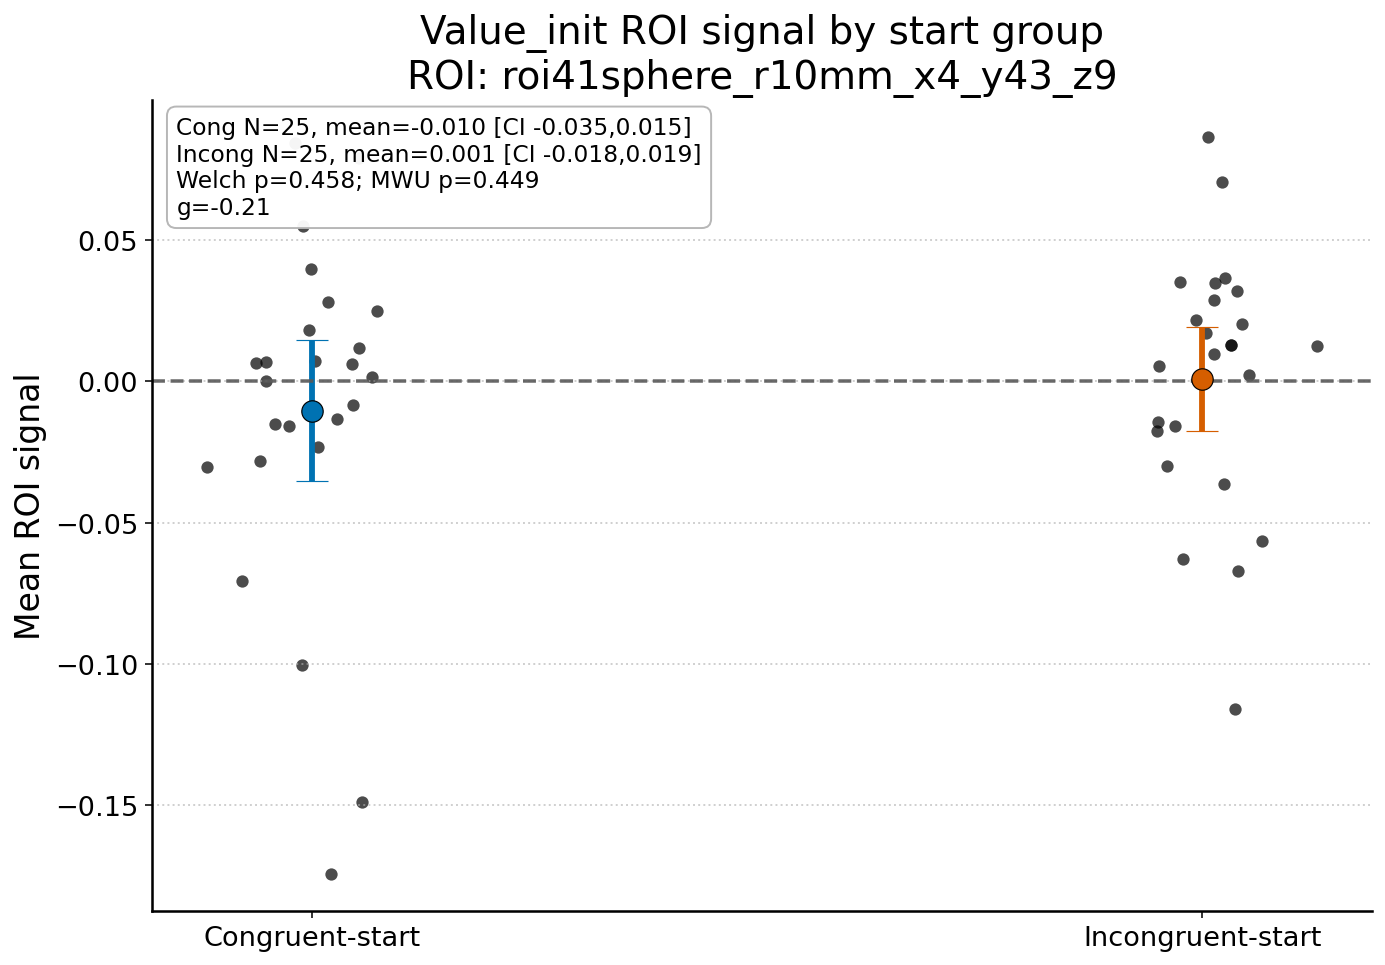

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures/roi41sphere_r10mm_x4_y43_z9_Value_init_StartGroups_Dots_MeanCI.jpeg


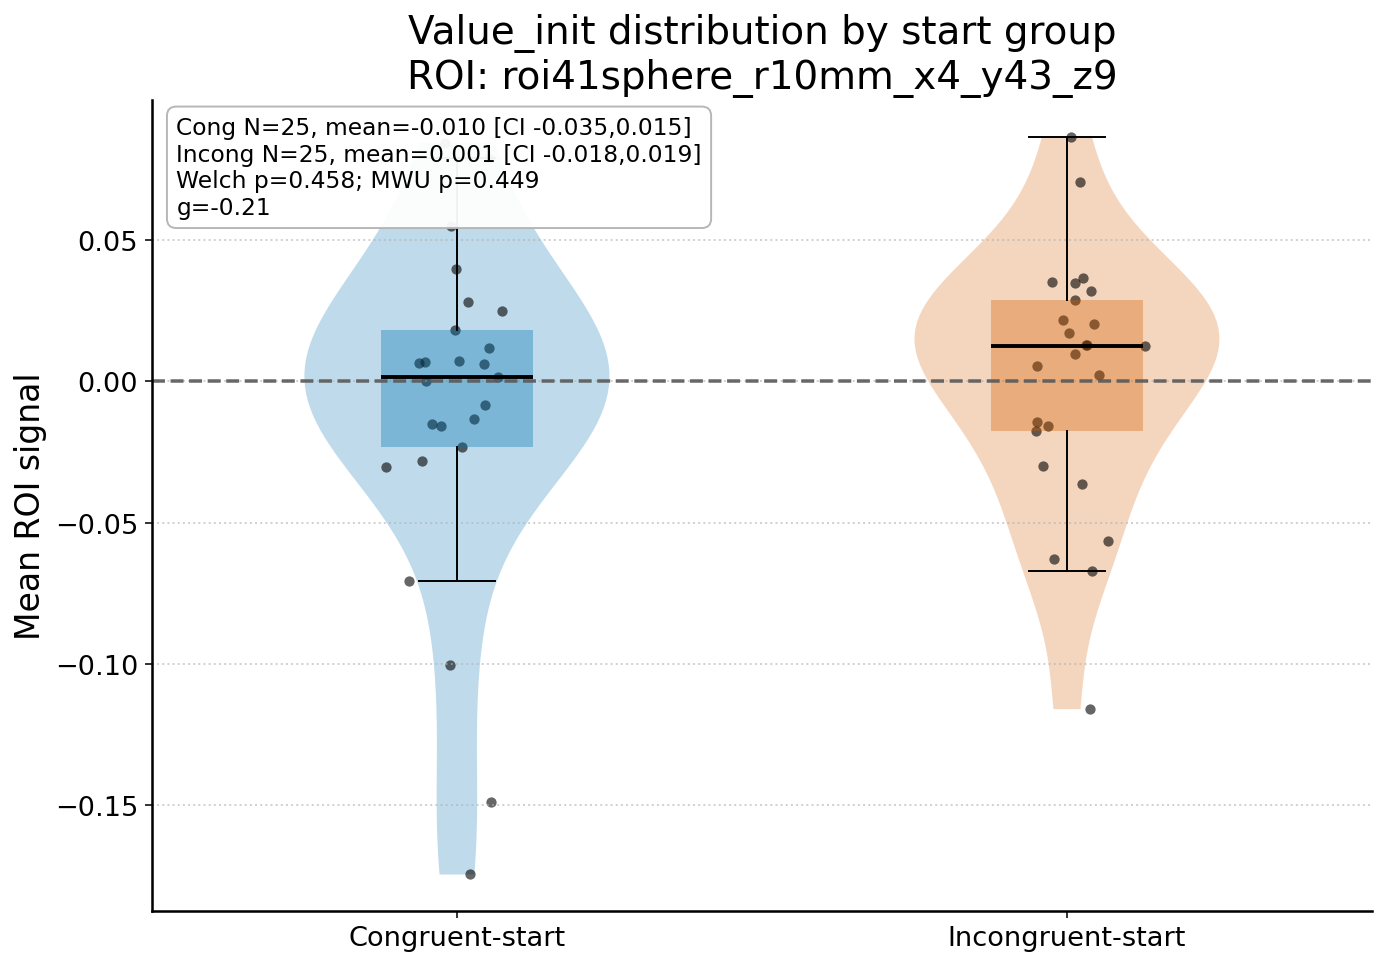

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures/roi41sphere_r10mm_x4_y43_z9_Value_init_StartGroups_ViolinBox.jpeg


In [10]:
import os
import re
import numpy as np
import nibabel as nib
from nilearn import input_data, plotting
from nilearn.image import load_img
from scipy import stats
import matplotlib.pyplot as plt

# ============================================================
# SUBJECT IDs by start group (numeric-only)
# ============================================================
CONGRUENT_START_IDS = [
    "004","005","010","011","012","017","020","022","025","027","028","029",
    "102","104","108","110","112","114","204","209","212","213","215","220","221"
]
INCONGRUENT_START_IDS = [
    "002","003","006","007","008","013","016","019","021","023","024","026","030",
    "101","116","117","119","121","124","201","205","207","211","214","219"
]

# -----------------------
# Helpers
# -----------------------
def normalize_to_digits3(s: str) -> str:
    s = str(s).strip()
    m = re.search(r"\b(\d{3})\b", s)
    if m:
        return m.group(1)
    m = re.search(r"(\d+)", s)
    if not m:
        raise ValueError(f"Could not extract digits from subject id: {s}")
    digits = m.group(1)
    return digits[-3:].zfill(3)

def mean_ci_t(x, confidence=0.95):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.size
    mean = float(np.mean(x))
    if n < 2:
        return mean, (np.nan, np.nan)
    sem = float(stats.sem(x))
    df = n - 1
    tcrit = float(stats.t.ppf((1 + confidence) / 2, df))
    half = tcrit * sem
    return mean, (mean - half, mean + half)

def cohens_d_onesample(x, mu0=0.0):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    sd = float(np.std(x, ddof=1))
    return float((np.mean(x) - mu0) / sd) if sd != 0 else np.nan

def hedges_g_independent(x1, x2):
    x1 = np.asarray(x1, dtype=float); x2 = np.asarray(x2, dtype=float)
    x1 = x1[~np.isnan(x1)]; x2 = x2[~np.isnan(x2)]
    n1, n2 = x1.size, x2.size
    if n1 < 2 or n2 < 2:
        return np.nan
    s1 = np.var(x1, ddof=1)
    s2 = np.var(x2, ddof=1)
    sp = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    d = (np.mean(x1) - np.mean(x2)) / sp
    J = 1 - (3 / (4*(n1 + n2) - 9))
    return float(J * d)

def safe_filename(s: str, maxlen: int = 140) -> str:
    s = s.strip()
    s = s.replace(">", "gt").replace("<", "lt")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s[:maxlen]

# -----------------------
# Plot settings
# -----------------------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "axes.titlesize": 20,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "axes.linewidth": 1.3,
})

MEAN_COLOR_A = "#0072B2"  # blue
MEAN_COLOR_B = "#D55E00"  # orange
ZERO_COLOR = "0.35"

# -----------------------
# Inputs (Value_init + sphere ROI)
# -----------------------
contrast_key = "Value_init"
functional_img_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_init_all_sub_4d.nii.gz")
subject_order_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_init_all_sub_4d_subject_order.txt")

roi_mask_path = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz"
anat_img = load_img(str(MEAN_ANAT))

# Labels for filenames
try:
    contrast_label = contrast_display_name(contrast_key)
except NameError:
    contrast_label = contrast_key

roi_label = "roi41sphere_r10mm_x4_y43_z9"
roi_slug = safe_filename(roi_label)
contrast_slug = safe_filename(contrast_label)

# -----------------------
# Output folder
# -----------------------
FIG_DIR = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures"
os.makedirs(FIG_DIR, exist_ok=True)

# -----------------------
# Load data
# -----------------------
functional_img = nib.load(functional_img_path)
roi_mask_img = nib.load(roi_mask_path)

print("ROI voxels:", int(np.sum(roi_mask_img.get_fdata() > 0)))

# -----------------------
# Figure 1: ROI mask overlay (SAVE)
# -----------------------
display = plotting.plot_roi(
    roi_mask_img,
    bg_img=anat_img,
    title=f"ROI Mask (verification): {roi_label}",
    display_mode="ortho",
    draw_cross=False,
    colorbar=False
)
roi_out = os.path.join(FIG_DIR, f"{roi_slug}_ROIMaskOverlay.jpeg")
display.savefig(roi_out, dpi=600)
display.close()
print(f"[OK] Saved: {roi_out}")

# -----------------------
# Load subject order (numeric-only) and extract ROI mean per subject
# -----------------------
with open(subject_order_path, "r") as f:
    SUBJECT_ORDER = [normalize_to_digits3(line.strip()) for line in f if line.strip()]

if functional_img.shape[3] != len(SUBJECT_ORDER):
    raise ValueError(
        f"Mismatch: 4D has {functional_img.shape[3]} volumes but SUBJECT_ORDER has {len(SUBJECT_ORDER)} IDs."
    )

# Reduce resampling overhead by aligning masker targets to the functional image grid
masker = input_data.NiftiMasker(
    mask_img=roi_mask_img,
    standardize=False,
    target_affine=functional_img.affine,
    target_shape=functional_img.shape[:3],
)

roi_vox = masker.fit_transform(functional_img)   # (n_subjects, n_voxels)
mean_signal = np.asarray(roi_vox.mean(axis=1)).ravel().astype(float)

# -----------------------
# Split into groups using SUBJECT_ORDER
# -----------------------
sub_to_idx = {s: i for i, s in enumerate(SUBJECT_ORDER)}

cong_ids = [normalize_to_digits3(s) for s in CONGRUENT_START_IDS]
incong_ids = [normalize_to_digits3(s) for s in INCONGRUENT_START_IDS]

missing_cong = [s for s in cong_ids if s not in sub_to_idx]
missing_incong = [s for s in incong_ids if s not in sub_to_idx]
if missing_cong or missing_incong:
    print("[WARN] Some subjects were not present in the 4D file (excluded):")
    if missing_cong: print("  Missing congruent-start:", missing_cong)
    if missing_incong: print("  Missing incongruent-start:", missing_incong)

cong_idx = [sub_to_idx[s] for s in cong_ids if s in sub_to_idx]
incong_idx = [sub_to_idx[s] for s in incong_ids if s in sub_to_idx]

x_cong = mean_signal[cong_idx]
x_incong = mean_signal[incong_idx]

# Drop NaNs just in case
x_cong = x_cong[~np.isnan(x_cong)]
x_incong = x_incong[~np.isnan(x_incong)]

n1, n2 = int(x_cong.size), int(x_incong.size)
print(f"[INFO] Kept subjects: Congruent-start N={n1}, Incongruent-start N={n2}")

if n1 == 0 or n2 == 0:
    raise RuntimeError("One or both groups are empty after matching. Check subject overlap with the imaging sample.")

# -----------------------
# Stats: within-group vs 0 and between-group
# -----------------------
m1, (ci1_lo, ci1_hi) = mean_ci_t(x_cong, 0.95)
m2, (ci2_lo, ci2_hi) = mean_ci_t(x_incong, 0.95)

t1, p1 = stats.ttest_1samp(x_cong, popmean=0.0, nan_policy="omit")
t2, p2 = stats.ttest_1samp(x_incong, popmean=0.0, nan_policy="omit")

# Between-group: Welch t-test (default)
t_welch, p_welch = stats.ttest_ind(x_cong, x_incong, equal_var=False, nan_policy="omit")

# Robustness check: Mann–Whitney U
u_stat, p_u = stats.mannwhitneyu(x_cong, x_incong, alternative="two-sided")

g = hedges_g_independent(x_cong, x_incong)
d1 = cohens_d_onesample(x_cong, 0.0)
d2 = cohens_d_onesample(x_incong, 0.0)

print("\nGroup comparison (Value_init, sphere ROI)")
print(f"Contrast: {contrast_label}")
print(f"ROI: {roi_mask_path}")
print("------------------------------------------------------------")
print(f"Congruent-start:   N={n1}, mean={m1:.6f}, 95% CI [{ci1_lo:.6f}, {ci1_hi:.6f}], t={float(t1):.3f}, p={float(p1):.4g}, d={d1:.3f}")
print(f"Incongruent-start: N={n2}, mean={m2:.6f}, 95% CI [{ci2_lo:.6f}, {ci2_hi:.6f}], t={float(t2):.3f}, p={float(p2):.4g}, d={d2:.3f}")
print("------------------------------------------------------------")
print(f"Between-group (Welch): t={float(t_welch):.3f}, p={float(p_welch):.4g}")
print(f"Between-group (MWU):   U={float(u_stat):.3f}, p={float(p_u):.4g}")
print(f"Effect size (Hedges g): g={g:.3f}")

stats_text = (
    f"Cong N={n1}, mean={m1:.3f} [CI {ci1_lo:.3f},{ci1_hi:.3f}]\n"
    f"Incong N={n2}, mean={m2:.3f} [CI {ci2_lo:.3f},{ci2_hi:.3f}]\n"
    f"Welch p={float(p_welch):.3g}; MWU p={float(p_u):.3g}\n"
    f"g={g:.2f}"
)

# -----------------------
# Figure 2: group comparison (dots + mean ± 95% CI)
# -----------------------
figA, axA = plt.subplots(figsize=(10, 7))

rng = np.random.default_rng(42)
xpos1 = 0 + rng.normal(0, 0.06, size=n1)
xpos2 = 1 + rng.normal(0, 0.06, size=n2)

axA.scatter(xpos1, x_cong, color="black", alpha=0.7, s=40, linewidths=0)
axA.scatter(xpos2, x_incong, color="black", alpha=0.7, s=40, linewidths=0)

axA.errorbar(0, m1, yerr=[[m1 - ci1_lo], [ci1_hi - m1]], fmt="o",
             color=MEAN_COLOR_A, ecolor=MEAN_COLOR_A, elinewidth=3, capsize=8,
             markersize=11, markeredgecolor="black", markeredgewidth=0.6,
             label="Mean ± 95% CI")
axA.errorbar(1, m2, yerr=[[m2 - ci2_lo], [ci2_hi - m2]], fmt="o",
             color=MEAN_COLOR_B, ecolor=MEAN_COLOR_B, elinewidth=3, capsize=8,
             markersize=11, markeredgecolor="black", markeredgewidth=0.6)

axA.axhline(0, color=ZERO_COLOR, linestyle="--", linewidth=1.8, alpha=0.9)
axA.set_xticks([0, 1])
axA.set_xticklabels(["Congruent-start", "Incongruent-start"])
axA.set_ylabel("Mean ROI signal")
axA.set_title(f"Value_init ROI signal by start group\nROI: {roi_label}")

axA.text(0.02, 0.98, stats_text, transform=axA.transAxes,
         va="top", ha="left", fontsize=12,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="0.7", alpha=0.95))

axA.spines["top"].set_visible(False)
axA.spines["right"].set_visible(False)
axA.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)

plt.tight_layout()
outA = os.path.join(FIG_DIR, f"{roi_slug}_{contrast_slug}_StartGroups_Dots_MeanCI.jpeg")
figA.savefig(outA, dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {outA}")

# -----------------------
# Figure 3: distribution (violin + box + points)
# -----------------------
figB, axB = plt.subplots(figsize=(10, 7))
data = [x_cong, x_incong]

vp = axB.violinplot(data, positions=[0, 1], showmeans=False, showextrema=False, showmedians=False)
for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(MEAN_COLOR_A if i == 0 else MEAN_COLOR_B)
    body.set_edgecolor("none")
    body.set_alpha(0.25)

bp = axB.boxplot(data, positions=[0, 1], widths=0.25, patch_artist=True, showfliers=False,
                 medianprops=dict(color="black", linewidth=2.0))
bp["boxes"][0].set(facecolor=MEAN_COLOR_A, alpha=0.35, edgecolor="none")
bp["boxes"][1].set(facecolor=MEAN_COLOR_B, alpha=0.35, edgecolor="none")

axB.scatter(xpos1, x_cong, color="black", alpha=0.6, s=28, linewidths=0)
axB.scatter(xpos2, x_incong, color="black", alpha=0.6, s=28, linewidths=0)

axB.axhline(0, color=ZERO_COLOR, linestyle="--", linewidth=1.8, alpha=0.9)
axB.set_xticks([0, 1])
axB.set_xticklabels(["Congruent-start", "Incongruent-start"])
axB.set_ylabel("Mean ROI signal")
axB.set_title(f"Value_init distribution by start group\nROI: {roi_label}")

axB.text(0.02, 0.98, stats_text, transform=axB.transAxes,
         va="top", ha="left", fontsize=12,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="0.7", alpha=0.95))

axB.spines["top"].set_visible(False)
axB.spines["right"].set_visible(False)
axB.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)

plt.tight_layout()
outB = os.path.join(FIG_DIR, f"{roi_slug}_{contrast_slug}_StartGroups_ViolinBox.jpeg")
figB.savefig(outB, dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {outB}")

##### Value_Model_Derived

ROI voxels: 528
[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_Model_Derived_figures/roi41sphere_r10mm_x4_y43_z9_ROIMaskOverlay.jpeg
[NiftiMasker.wrapped] Resampling images
[INFO] Kept subjects: Congruent-start N=25, Incongruent-start N=25

Group comparison (Value_init, sphere ROI)
Contrast: Value_Model_Derived
ROI: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz
------------------------------------------------------------
Congruent-start:   N=25, mean=0.026358, 95% CI [-0.101306, 0.154022], t=0.426, p=0.6738, d=0.085
Incongruent-start: N=25, mean=0.052461, 95% CI [-0.185413, 0.290334], t=0.455, p=0.6531, d=0.091
------------------------------------------------------------
Between-group (Welch): t=-0.200, p=0.8429
Between-group (MWU):   U=307.000, p=0.9227
Effect size (Hedges g): g=-0.056


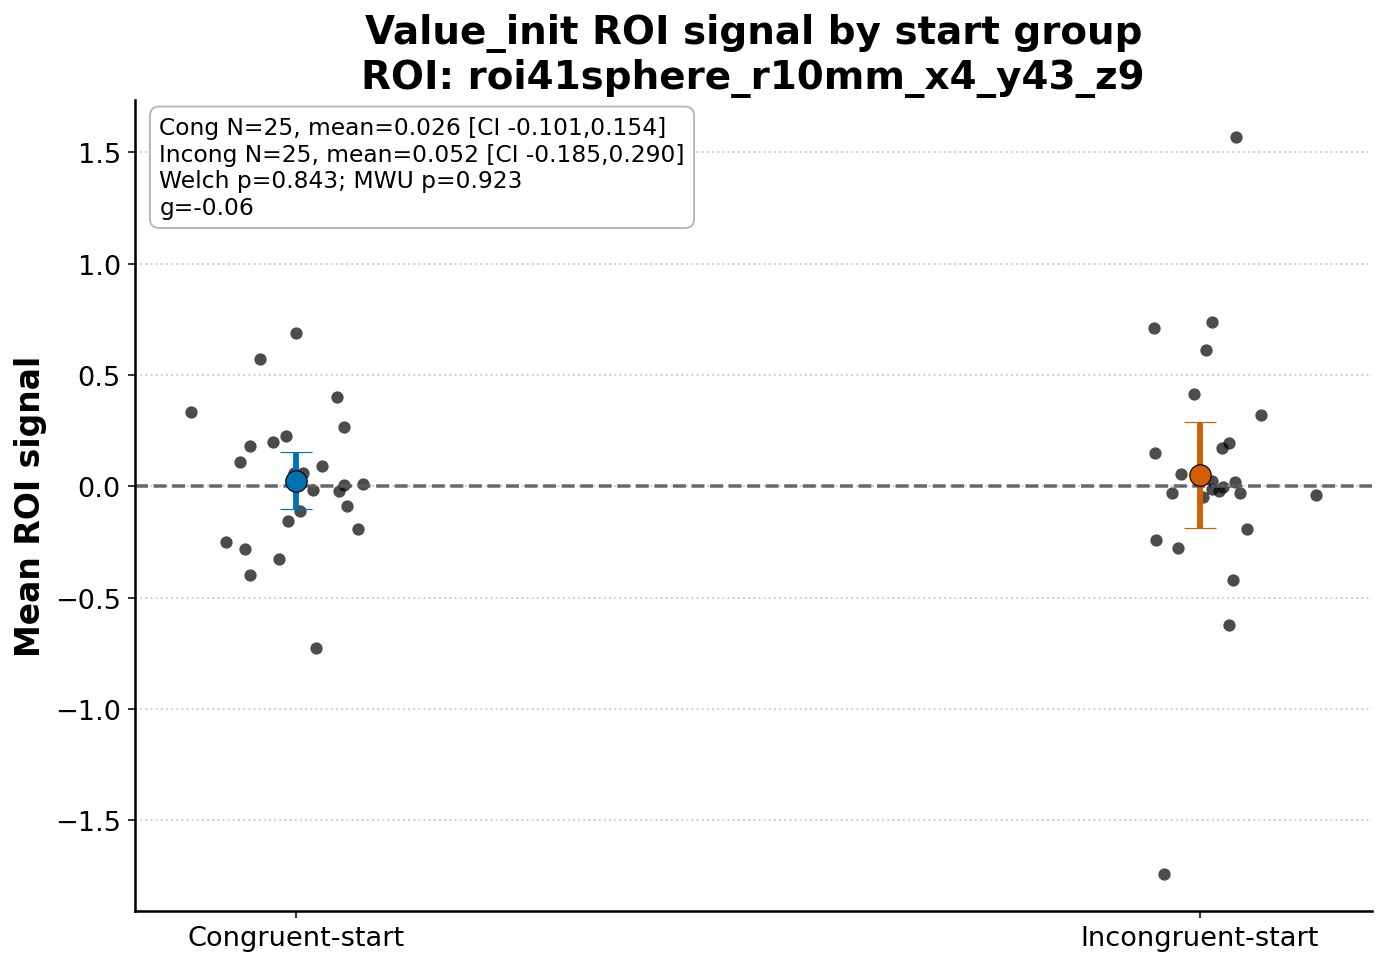

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_Model_Derived_figures/roi41sphere_r10mm_x4_y43_z9_Value_Model_Derived_StartGroups_Dots_MeanCI.jpeg


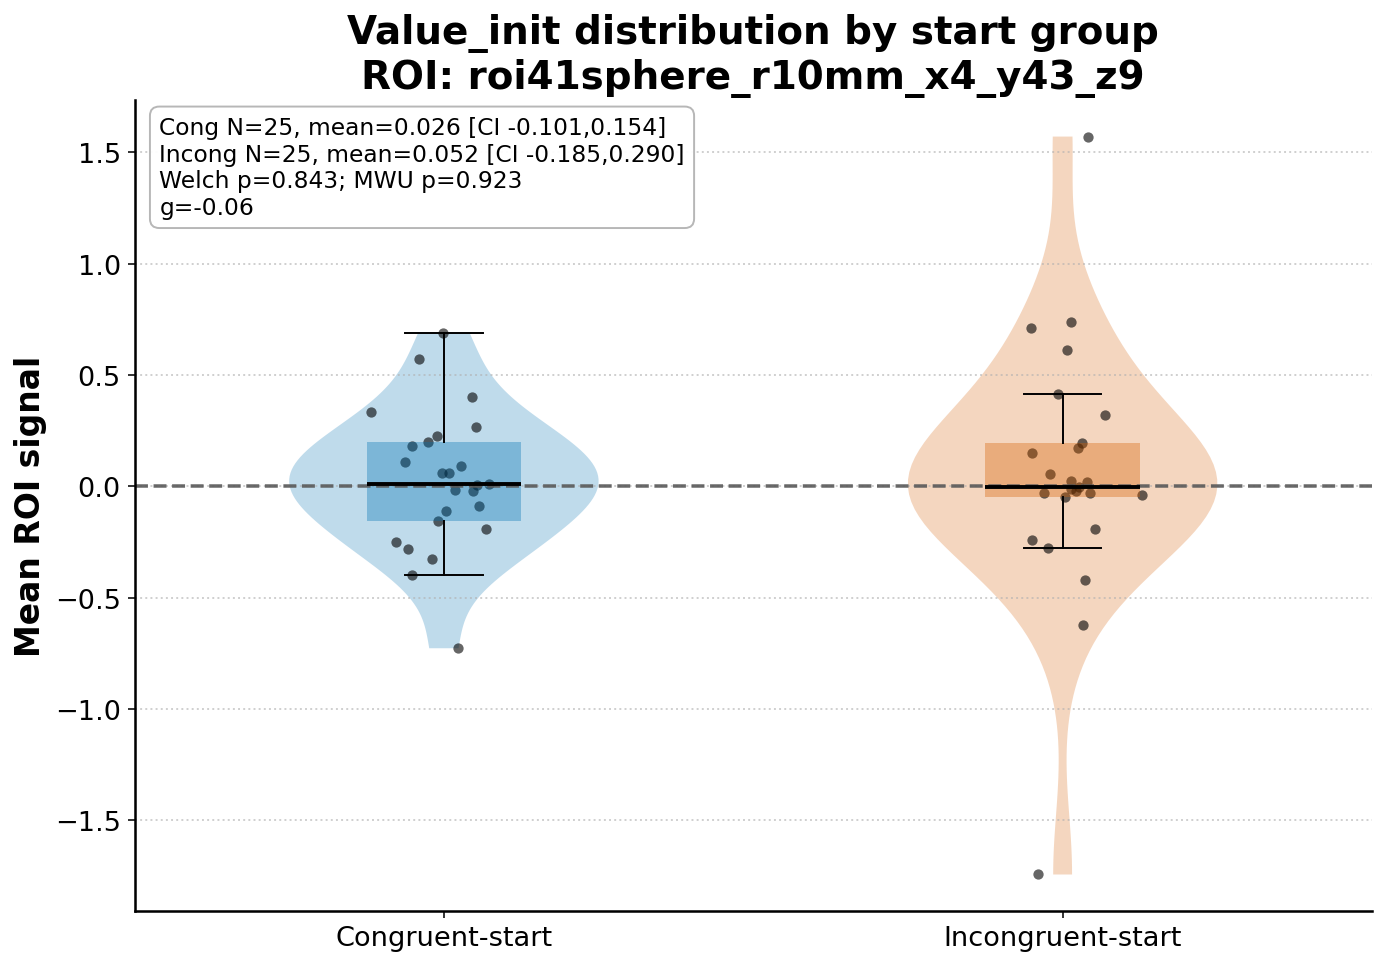

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_Model_Derived_figures/roi41sphere_r10mm_x4_y43_z9_Value_Model_Derived_StartGroups_ViolinBox.jpeg


In [22]:
import os
import re
import numpy as np
import nibabel as nib
from nilearn import input_data, plotting
from nilearn.image import load_img
from scipy import stats
import matplotlib.pyplot as plt

# ============================================================
# SUBJECT IDs by start group (numeric-only)
# ============================================================
CONGRUENT_START_IDS = [
    "004","005","010","011","012","017","020","022","025","027","028","029",
    "102","104","108","110","112","114","204","209","212","213","215","220","221"
]
INCONGRUENT_START_IDS = [
    "002","003","006","007","008","013","016","019","021","023","024","026","030",
    "101","116","117","119","121","124","201","205","207","211","214","219"
]

# -----------------------
# Helpers
# -----------------------
def normalize_to_digits3(s: str) -> str:
    s = str(s).strip()
    m = re.search(r"\b(\d{3})\b", s)
    if m:
        return m.group(1)
    m = re.search(r"(\d+)", s)
    if not m:
        raise ValueError(f"Could not extract digits from subject id: {s}")
    digits = m.group(1)
    return digits[-3:].zfill(3)

def mean_ci_t(x, confidence=0.95):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.size
    mean = float(np.mean(x))
    if n < 2:
        return mean, (np.nan, np.nan)
    sem = float(stats.sem(x))
    df = n - 1
    tcrit = float(stats.t.ppf((1 + confidence) / 2, df))
    half = tcrit * sem
    return mean, (mean - half, mean + half)

def cohens_d_onesample(x, mu0=0.0):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    sd = float(np.std(x, ddof=1))
    return float((np.mean(x) - mu0) / sd) if sd != 0 else np.nan

def hedges_g_independent(x1, x2):
    x1 = np.asarray(x1, dtype=float); x2 = np.asarray(x2, dtype=float)
    x1 = x1[~np.isnan(x1)]; x2 = x2[~np.isnan(x2)]
    n1, n2 = x1.size, x2.size
    if n1 < 2 or n2 < 2:
        return np.nan
    s1 = np.var(x1, ddof=1)
    s2 = np.var(x2, ddof=1)
    sp = np.sqrt(((n1 - 1)*s1 + (n2 - 1)*s2) / (n1 + n2 - 2))
    d = (np.mean(x1) - np.mean(x2)) / sp
    J = 1 - (3 / (4*(n1 + n2) - 9))
    return float(J * d)

def safe_filename(s: str, maxlen: int = 140) -> str:
    s = s.strip()
    s = s.replace(">", "gt").replace("<", "lt")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s[:maxlen]

# -----------------------
# Plot settings
# -----------------------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "axes.titlesize": 20,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "axes.linewidth": 1.3,
})

MEAN_COLOR_A = "#0072B2"  # blue
MEAN_COLOR_B = "#D55E00"  # orange
ZERO_COLOR = "0.35"

# -----------------------
# Inputs (Value_init + sphere ROI)
# -----------------------
contrast_key = "Value_Model_Derived"
functional_img_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_Model_Derived_all_sub_4d.nii.gz")
subject_order_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_Model_Derived_all_sub_4d_subject_order.txt")

roi_mask_path = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz"
anat_img = load_img(str(MEAN_ANAT))

# Labels for filenames
try:
    contrast_label = contrast_display_name(contrast_key)
except NameError:
    contrast_label = contrast_key

roi_label = "roi41sphere_r10mm_x4_y43_z9"
roi_slug = safe_filename(roi_label)
contrast_slug = safe_filename(contrast_label)

# -----------------------
# Output folder
# -----------------------
FIG_DIR = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_Model_Derived_figures"
os.makedirs(FIG_DIR, exist_ok=True)

# -----------------------
# Load data
# -----------------------
functional_img = nib.load(functional_img_path)
roi_mask_img = nib.load(roi_mask_path)

print("ROI voxels:", int(np.sum(roi_mask_img.get_fdata() > 0)))

# -----------------------
# Figure 1: ROI mask overlay (SAVE)
# -----------------------
display = plotting.plot_roi(
    roi_mask_img,
    bg_img=anat_img,
    title=f"ROI Mask (verification): {roi_label}",
    display_mode="ortho",
    draw_cross=False,
    colorbar=False
)
roi_out = os.path.join(FIG_DIR, f"{roi_slug}_ROIMaskOverlay.jpeg")
display.savefig(roi_out, dpi=600)
display.close()
print(f"[OK] Saved: {roi_out}")

# -----------------------
# Load subject order (numeric-only) and extract ROI mean per subject
# -----------------------
with open(subject_order_path, "r") as f:
    SUBJECT_ORDER = [normalize_to_digits3(line.strip()) for line in f if line.strip()]

if functional_img.shape[3] != len(SUBJECT_ORDER):
    raise ValueError(
        f"Mismatch: 4D has {functional_img.shape[3]} volumes but SUBJECT_ORDER has {len(SUBJECT_ORDER)} IDs."
    )

# Reduce resampling overhead by aligning masker targets to the functional image grid
masker = input_data.NiftiMasker(
    mask_img=roi_mask_img,
    standardize=False,
    target_affine=functional_img.affine,
    target_shape=functional_img.shape[:3],
)

roi_vox = masker.fit_transform(functional_img)   # (n_subjects, n_voxels)
mean_signal = np.asarray(roi_vox.mean(axis=1)).ravel().astype(float)

# -----------------------
# Split into groups using SUBJECT_ORDER
# -----------------------
sub_to_idx = {s: i for i, s in enumerate(SUBJECT_ORDER)}

cong_ids = [normalize_to_digits3(s) for s in CONGRUENT_START_IDS]
incong_ids = [normalize_to_digits3(s) for s in INCONGRUENT_START_IDS]

missing_cong = [s for s in cong_ids if s not in sub_to_idx]
missing_incong = [s for s in incong_ids if s not in sub_to_idx]
if missing_cong or missing_incong:
    print("[WARN] Some subjects were not present in the 4D file (excluded):")
    if missing_cong: print("  Missing congruent-start:", missing_cong)
    if missing_incong: print("  Missing incongruent-start:", missing_incong)

cong_idx = [sub_to_idx[s] for s in cong_ids if s in sub_to_idx]
incong_idx = [sub_to_idx[s] for s in incong_ids if s in sub_to_idx]

x_cong = mean_signal[cong_idx]
x_incong = mean_signal[incong_idx]

# Drop NaNs just in case
x_cong = x_cong[~np.isnan(x_cong)]
x_incong = x_incong[~np.isnan(x_incong)]

n1, n2 = int(x_cong.size), int(x_incong.size)
print(f"[INFO] Kept subjects: Congruent-start N={n1}, Incongruent-start N={n2}")

if n1 == 0 or n2 == 0:
    raise RuntimeError("One or both groups are empty after matching. Check subject overlap with the imaging sample.")

# -----------------------
# Stats: within-group vs 0 and between-group
# -----------------------
m1, (ci1_lo, ci1_hi) = mean_ci_t(x_cong, 0.95)
m2, (ci2_lo, ci2_hi) = mean_ci_t(x_incong, 0.95)

t1, p1 = stats.ttest_1samp(x_cong, popmean=0.0, nan_policy="omit")
t2, p2 = stats.ttest_1samp(x_incong, popmean=0.0, nan_policy="omit")

# Between-group: Welch t-test (default)
t_welch, p_welch = stats.ttest_ind(x_cong, x_incong, equal_var=False, nan_policy="omit")

# Robustness check: Mann–Whitney U
u_stat, p_u = stats.mannwhitneyu(x_cong, x_incong, alternative="two-sided")

g = hedges_g_independent(x_cong, x_incong)
d1 = cohens_d_onesample(x_cong, 0.0)
d2 = cohens_d_onesample(x_incong, 0.0)

print("\nGroup comparison (Value_init, sphere ROI)")
print(f"Contrast: {contrast_label}")
print(f"ROI: {roi_mask_path}")
print("------------------------------------------------------------")
print(f"Congruent-start:   N={n1}, mean={m1:.6f}, 95% CI [{ci1_lo:.6f}, {ci1_hi:.6f}], t={float(t1):.3f}, p={float(p1):.4g}, d={d1:.3f}")
print(f"Incongruent-start: N={n2}, mean={m2:.6f}, 95% CI [{ci2_lo:.6f}, {ci2_hi:.6f}], t={float(t2):.3f}, p={float(p2):.4g}, d={d2:.3f}")
print("------------------------------------------------------------")
print(f"Between-group (Welch): t={float(t_welch):.3f}, p={float(p_welch):.4g}")
print(f"Between-group (MWU):   U={float(u_stat):.3f}, p={float(p_u):.4g}")
print(f"Effect size (Hedges g): g={g:.3f}")

stats_text = (
    f"Cong N={n1}, mean={m1:.3f} [CI {ci1_lo:.3f},{ci1_hi:.3f}]\n"
    f"Incong N={n2}, mean={m2:.3f} [CI {ci2_lo:.3f},{ci2_hi:.3f}]\n"
    f"Welch p={float(p_welch):.3g}; MWU p={float(p_u):.3g}\n"
    f"g={g:.2f}"
)

# -----------------------
# Figure 2: group comparison (dots + mean ± 95% CI)
# -----------------------
figA, axA = plt.subplots(figsize=(10, 7))

rng = np.random.default_rng(42)
xpos1 = 0 + rng.normal(0, 0.06, size=n1)
xpos2 = 1 + rng.normal(0, 0.06, size=n2)

axA.scatter(xpos1, x_cong, color="black", alpha=0.7, s=40, linewidths=0)
axA.scatter(xpos2, x_incong, color="black", alpha=0.7, s=40, linewidths=0)

axA.errorbar(0, m1, yerr=[[m1 - ci1_lo], [ci1_hi - m1]], fmt="o",
             color=MEAN_COLOR_A, ecolor=MEAN_COLOR_A, elinewidth=3, capsize=8,
             markersize=11, markeredgecolor="black", markeredgewidth=0.6,
             label="Mean ± 95% CI")
axA.errorbar(1, m2, yerr=[[m2 - ci2_lo], [ci2_hi - m2]], fmt="o",
             color=MEAN_COLOR_B, ecolor=MEAN_COLOR_B, elinewidth=3, capsize=8,
             markersize=11, markeredgecolor="black", markeredgewidth=0.6)

axA.axhline(0, color=ZERO_COLOR, linestyle="--", linewidth=1.8, alpha=0.9)
axA.set_xticks([0, 1])
axA.set_xticklabels(["Congruent-start", "Incongruent-start"])
axA.set_ylabel("Mean ROI signal")
axA.set_title(f"Value_init ROI signal by start group\nROI: {roi_label}")

axA.text(0.02, 0.98, stats_text, transform=axA.transAxes,
         va="top", ha="left", fontsize=12,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="0.7", alpha=0.95))

axA.spines["top"].set_visible(False)
axA.spines["right"].set_visible(False)
axA.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)

plt.tight_layout()
outA = os.path.join(FIG_DIR, f"{roi_slug}_{contrast_slug}_StartGroups_Dots_MeanCI.jpeg")
figA.savefig(outA, dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {outA}")

# -----------------------
# Figure 3: distribution (violin + box + points)
# -----------------------
figB, axB = plt.subplots(figsize=(10, 7))
data = [x_cong, x_incong]

vp = axB.violinplot(data, positions=[0, 1], showmeans=False, showextrema=False, showmedians=False)
for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(MEAN_COLOR_A if i == 0 else MEAN_COLOR_B)
    body.set_edgecolor("none")
    body.set_alpha(0.25)

bp = axB.boxplot(data, positions=[0, 1], widths=0.25, patch_artist=True, showfliers=False,
                 medianprops=dict(color="black", linewidth=2.0))
bp["boxes"][0].set(facecolor=MEAN_COLOR_A, alpha=0.35, edgecolor="none")
bp["boxes"][1].set(facecolor=MEAN_COLOR_B, alpha=0.35, edgecolor="none")

axB.scatter(xpos1, x_cong, color="black", alpha=0.6, s=28, linewidths=0)
axB.scatter(xpos2, x_incong, color="black", alpha=0.6, s=28, linewidths=0)

axB.axhline(0, color=ZERO_COLOR, linestyle="--", linewidth=1.8, alpha=0.9)
axB.set_xticks([0, 1])
axB.set_xticklabels(["Congruent-start", "Incongruent-start"])
axB.set_ylabel("Mean ROI signal")
axB.set_title(f"Value_init distribution by start group\nROI: {roi_label}")

axB.text(0.02, 0.98, stats_text, transform=axB.transAxes,
         va="top", ha="left", fontsize=12,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="0.7", alpha=0.95))

axB.spines["top"].set_visible(False)
axB.spines["right"].set_visible(False)
axB.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)

plt.tight_layout()
outB = os.path.join(FIG_DIR, f"{roi_slug}_{contrast_slug}_StartGroups_ViolinBox.jpeg")
figB.savefig(outB, dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {outB}")

#### BES Global score correlation (exploratory)

##### Value_init

ROI voxels: 528
[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures/roi41sphere_r10mm_x4_y43_z9_ROIMaskOverlay.jpeg
Example subject_order: ['002', '003', '004', '005', '006', '007', '008', '010', '011', '012']
N in 4D: 50
[NiftiMasker.wrapped] Resampling images
[INFO] ROI means available: N=50
[INFO] bes_GLOBAL numeric values: N=49
[INFO] Overlap ROI x bes_GLOBAL: N=47

Correlation results (Value_init, sphere ROI):
Pearson:  r = -0.005, p = 0.9732
Spearman: ρ = -0.035, p = 0.8168


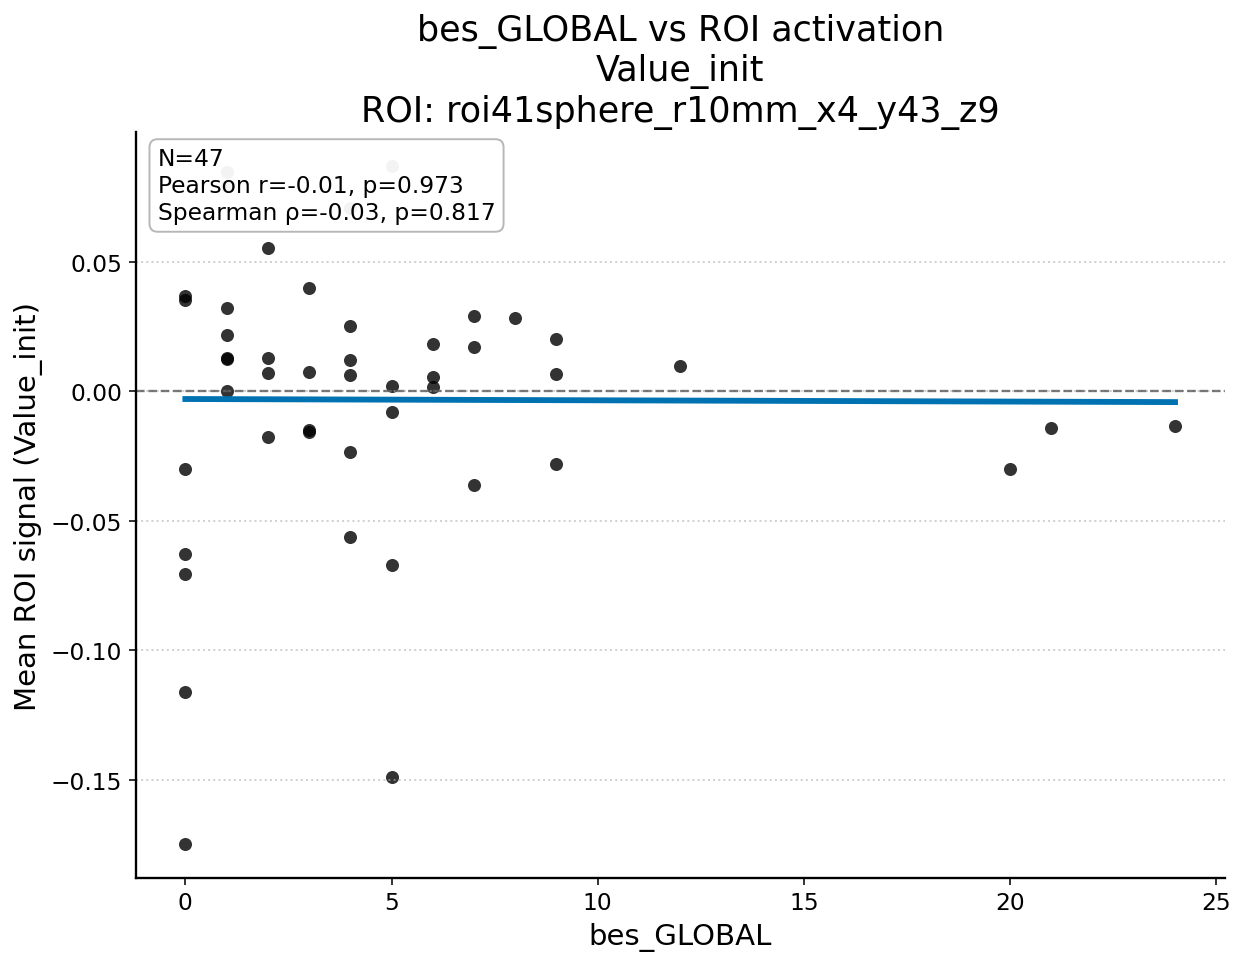

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures/roi41sphere_r10mm_x4_y43_z9_Value_init_besGLOBAL_correlation.jpeg
[OK] Saved merged data table: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures/roi41sphere_r10mm_x4_y43_z9_Value_init_besGLOBAL_roi_merged.csv


In [11]:
# Value_init sphere ROI: correlate bes_GLOBAL with mean ROI activation
# - Uses the existing sphere ROI mask
# - Uses the 4D Value_init file AND its saved subject order file
# - Loads survey_responses.csv, pulls bes_GLOBAL row (columns are subjects)
# - Aligns subjects by numeric 3-digit IDs (e.g., "2" -> "002")
# - Runs Pearson + Spearman correlations
# - Saves: ROI overlay (optional), correlation scatter with regression line, and merged data CSV

import os
import re
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn import input_data, plotting
from nilearn.image import load_img
from scipy import stats
import matplotlib.pyplot as plt

# -----------------------
# Helpers
# -----------------------
def safe_filename(s: str, maxlen: int = 140) -> str:
    s = s.strip()
    s = s.replace(">", "gt").replace("<", "lt")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s[:maxlen]

def normalize_to_digits3(s: str) -> str:
    """
    Canonical subject code: '002', '010', '221', etc.
    Works for: 2, '2', '002', 'FV002', 'sub-002', 'FVsub-002', etc.
    """
    s = str(s).strip()
    m = re.search(r"\b(\d{3})\b", s)
    if m:
        return m.group(1)
    m = re.search(r"(\d+)", s)
    if not m:
        raise ValueError(f"Could not extract digits from subject id: {s}")
    digits = m.group(1)
    return digits[-3:].zfill(3)

# -----------------------
# Plot settings
# -----------------------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
})

LINE_COLOR = "#0072B2"
ZERO_COLOR = "0.35"

# -----------------------
# Inputs
# -----------------------
contrast_key = "Value_init"

functional_img_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_init_all_sub_4d.nii.gz")
subject_order_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_init_all_sub_4d_subject_order.txt")

roi_mask_path = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz"
anat_img = load_img(str(MEAN_ANAT))

survey_csv = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/data/survey_responses.csv"
survey_row_name = "bes_GLOBAL"

# Labels for filenames
try:
    contrast_label = contrast_display_name(contrast_key)
except NameError:
    contrast_label = contrast_key

roi_label = "roi41sphere_r10mm_x4_y43_z9"

roi_slug = safe_filename(roi_label)
contrast_slug = safe_filename(contrast_label)

# Output folder
FIG_DIR = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures"
os.makedirs(FIG_DIR, exist_ok=True)

# -----------------------
# Load images
# -----------------------
functional_img = nib.load(functional_img_path)
roi_mask_img = nib.load(roi_mask_path)

print("ROI voxels:", int(np.sum(roi_mask_img.get_fdata() > 0)))

# -----------------------
# (Optional) Save ROI overlay
# -----------------------
display = plotting.plot_roi(
    roi_mask_img,
    bg_img=anat_img,
    title=f"ROI Mask (verification): {roi_label}",
    display_mode="ortho",
    draw_cross=False,
    colorbar=False,
)
roi_out = os.path.join(FIG_DIR, f"{roi_slug}_ROIMaskOverlay.jpeg")
display.savefig(roi_out, dpi=600)
display.close()
print(f"[OK] Saved: {roi_out}")

# -----------------------
# Load subject order (needed to align ROI values to survey columns)
# -----------------------
if not os.path.exists(subject_order_path):
    raise FileNotFoundError(
        f"Missing subject order file:\n{subject_order_path}\n"
        "Rebuild the 4D file with a builder that saves subject order."
    )

with open(subject_order_path, "r") as f:
    subject_order = [normalize_to_digits3(line.strip()) for line in f if line.strip()]

if functional_img.shape[3] != len(subject_order):
    raise ValueError(
        f"Mismatch: 4D has {functional_img.shape[3]} volumes but subject_order has {len(subject_order)} IDs."
    )

print("Example subject_order:", subject_order[:10])
print("N in 4D:", functional_img.shape[3])

# -----------------------
# Extract mean ROI signal per subject
# -----------------------
masker = input_data.NiftiMasker(
    mask_img=roi_mask_img,
    standardize=False,
    target_affine=functional_img.affine,
    target_shape=functional_img.shape[:3],
)
roi_vox = masker.fit_transform(functional_img)  # (n_subjects, n_voxels)
roi_mean = np.asarray(roi_vox.mean(axis=1)).ravel().astype(float)

roi_df = pd.DataFrame({
    "subject": subject_order,
    "roi_mean": roi_mean,
}).dropna(subset=["roi_mean"])

print(f"[INFO] ROI means available: N={len(roi_df)}")

# -----------------------
# Load survey CSV and pull bes_GLOBAL row
# -----------------------
survey_wide = pd.read_csv(survey_csv, sep=None, engine="python")  # auto-detect delimiter
row_label_col = survey_wide.columns[0]
survey_wide = survey_wide.set_index(row_label_col)

if survey_row_name not in survey_wide.index:
    raise KeyError(
        f"Row '{survey_row_name}' not found in {survey_csv}. "
        f"Check spelling/case. Example rows: {survey_wide.index[:20].tolist()} ..."
    )

bes_series = survey_wide.loc[survey_row_name]  # columns are subject IDs

survey_long = (
    bes_series.rename("bes_GLOBAL")
    .reset_index()
    .rename(columns={"index": "subject_raw"})
)

survey_long["subject"] = survey_long["subject_raw"].apply(normalize_to_digits3)
survey_long["bes_GLOBAL"] = pd.to_numeric(survey_long["bes_GLOBAL"], errors="coerce")
survey_long = survey_long.dropna(subset=["bes_GLOBAL"])

print(f"[INFO] bes_GLOBAL numeric values: N={len(survey_long)}")

# -----------------------
# Merge and correlate
# -----------------------
merged = pd.merge(
    roi_df,
    survey_long[["subject", "bes_GLOBAL"]],
    on="subject",
    how="inner",
).dropna(subset=["roi_mean", "bes_GLOBAL"])

n = int(len(merged))
print(f"[INFO] Overlap ROI x bes_GLOBAL: N={n}")
if n < 3:
    raise RuntimeError("Not enough overlapping subjects to compute correlation (need at least 3).")

x = merged["bes_GLOBAL"].to_numpy(dtype=float)
y = merged["roi_mean"].to_numpy(dtype=float)

r, p_r = stats.pearsonr(x, y)
rho, p_rho = stats.spearmanr(x, y)

print("\nCorrelation results (Value_init, sphere ROI):")
print(f"Pearson:  r = {r:.3f}, p = {p_r:.4g}")
print(f"Spearman: ρ = {rho:.3f}, p = {p_rho:.4g}")

# -----------------------
# Plot: scatter + regression line + stats box
# -----------------------
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(x, y, color="black", alpha=0.8, s=45, linewidths=0)

slope, intercept = np.polyfit(x, y, 1)
xx = np.linspace(np.min(x), np.max(x), 200)
yy = slope * xx + intercept
ax.plot(xx, yy, color=LINE_COLOR, linewidth=3)

ax.axhline(0, color=ZERO_COLOR, linestyle="--", linewidth=1.2, alpha=0.8)

ax.set_xlabel("bes_GLOBAL")
ax.set_ylabel("Mean ROI signal (Value_init)")
ax.set_title(f"bes_GLOBAL vs ROI activation\n{contrast_label}\nROI: {roi_label}")

stats_text = (
    f"N={n}\n"
    f"Pearson r={r:.2f}, p={p_r:.3g}\n"
    f"Spearman ρ={rho:.2f}, p={p_rho:.3g}"
)
ax.text(
    0.02, 0.98, stats_text,
    transform=ax.transAxes, va="top", ha="left",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.7", alpha=0.95),
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)

plt.tight_layout()

out_plot = os.path.join(FIG_DIR, f"{roi_slug}_{contrast_slug}_besGLOBAL_correlation.jpeg")
fig.savefig(out_plot, dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {out_plot}")

# -----------------------
# Save merged analysis table
# -----------------------
out_table = os.path.join(FIG_DIR, f"{roi_slug}_{contrast_slug}_besGLOBAL_roi_merged.csv")
merged.to_csv(out_table, index=False)
print(f"[OK] Saved merged data table: {out_table}")

##### Value_Model_Derived

ROI voxels: 528
[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_Model_Derived_figures/roi41sphere_r10mm_x4_y43_z9_ROIMaskOverlay.jpeg
Example subject_order: ['002', '003', '004', '005', '006', '007', '008', '010', '011', '012']
N in 4D: 50
[NiftiMasker.wrapped] Resampling images
[INFO] ROI means available: N=50
[INFO] bes_GLOBAL numeric values: N=49
[INFO] Overlap ROI x bes_GLOBAL: N=47

Correlation results (Value_init, sphere ROI):
Pearson:  r = -0.156, p = 0.294
Spearman: ρ = 0.115, p = 0.443


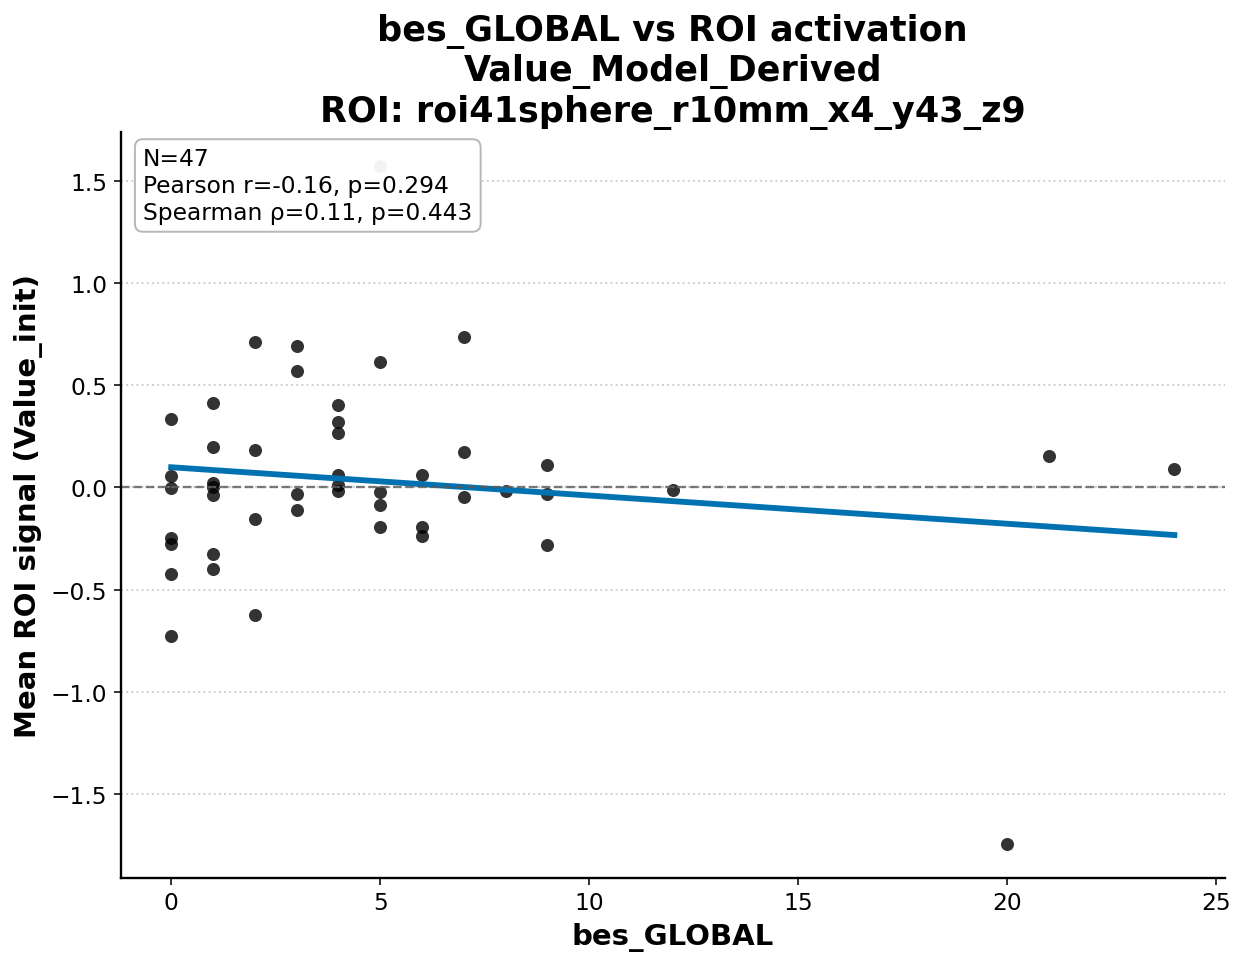

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_Model_Derived_figures/roi41sphere_r10mm_x4_y43_z9_Value_Model_Derived_besGLOBAL_correlation.jpeg
[OK] Saved merged data table: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_Model_Derived_figures/roi41sphere_r10mm_x4_y43_z9_Value_Model_Derived_besGLOBAL_roi_merged.csv


In [23]:
# Value_init sphere ROI: correlate bes_GLOBAL with mean ROI activation
# - Uses the existing sphere ROI mask
# - Uses the 4D Value_init file AND its saved subject order file
# - Loads survey_responses.csv, pulls bes_GLOBAL row (columns are subjects)
# - Aligns subjects by numeric 3-digit IDs (e.g., "2" -> "002")
# - Runs Pearson + Spearman correlations
# - Saves: ROI overlay (optional), correlation scatter with regression line, and merged data CSV

import os
import re
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn import input_data, plotting
from nilearn.image import load_img
from scipy import stats
import matplotlib.pyplot as plt

# -----------------------
# Helpers
# -----------------------
def safe_filename(s: str, maxlen: int = 140) -> str:
    s = s.strip()
    s = s.replace(">", "gt").replace("<", "lt")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s[:maxlen]

def normalize_to_digits3(s: str) -> str:
    """
    Canonical subject code: '002', '010', '221', etc.
    Works for: 2, '2', '002', 'FV002', 'sub-002', 'FVsub-002', etc.
    """
    s = str(s).strip()
    m = re.search(r"\b(\d{3})\b", s)
    if m:
        return m.group(1)
    m = re.search(r"(\d+)", s)
    if not m:
        raise ValueError(f"Could not extract digits from subject id: {s}")
    digits = m.group(1)
    return digits[-3:].zfill(3)

# -----------------------
# Plot settings
# -----------------------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
})

LINE_COLOR = "#0072B2"
ZERO_COLOR = "0.35"

# -----------------------
# Inputs
# -----------------------
contrast_key = "Value_Model_Derived"

functional_img_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_Model_Derived_all_sub_4d.nii.gz")
subject_order_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_Model_Derived_all_sub_4d_subject_order.txt")

roi_mask_path = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz"
anat_img = load_img(str(MEAN_ANAT))

survey_csv = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/data/survey_responses.csv"
survey_row_name = "bes_GLOBAL"

# Labels for filenames
try:
    contrast_label = contrast_display_name(contrast_key)
except NameError:
    contrast_label = contrast_key

roi_label = "roi41sphere_r10mm_x4_y43_z9"

roi_slug = safe_filename(roi_label)
contrast_slug = safe_filename(contrast_label)

# Output folder
FIG_DIR = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_Model_Derived_figures"
os.makedirs(FIG_DIR, exist_ok=True)

# -----------------------
# Load images
# -----------------------
functional_img = nib.load(functional_img_path)
roi_mask_img = nib.load(roi_mask_path)

print("ROI voxels:", int(np.sum(roi_mask_img.get_fdata() > 0)))

# -----------------------
# (Optional) Save ROI overlay
# -----------------------
display = plotting.plot_roi(
    roi_mask_img,
    bg_img=anat_img,
    title=f"ROI Mask (verification): {roi_label}",
    display_mode="ortho",
    draw_cross=False,
    colorbar=False,
)
roi_out = os.path.join(FIG_DIR, f"{roi_slug}_ROIMaskOverlay.jpeg")
display.savefig(roi_out, dpi=600)
display.close()
print(f"[OK] Saved: {roi_out}")

# -----------------------
# Load subject order (needed to align ROI values to survey columns)
# -----------------------
if not os.path.exists(subject_order_path):
    raise FileNotFoundError(
        f"Missing subject order file:\n{subject_order_path}\n"
        "Rebuild the 4D file with a builder that saves subject order."
    )

with open(subject_order_path, "r") as f:
    subject_order = [normalize_to_digits3(line.strip()) for line in f if line.strip()]

if functional_img.shape[3] != len(subject_order):
    raise ValueError(
        f"Mismatch: 4D has {functional_img.shape[3]} volumes but subject_order has {len(subject_order)} IDs."
    )

print("Example subject_order:", subject_order[:10])
print("N in 4D:", functional_img.shape[3])

# -----------------------
# Extract mean ROI signal per subject
# -----------------------
masker = input_data.NiftiMasker(
    mask_img=roi_mask_img,
    standardize=False,
    target_affine=functional_img.affine,
    target_shape=functional_img.shape[:3],
)
roi_vox = masker.fit_transform(functional_img)  # (n_subjects, n_voxels)
roi_mean = np.asarray(roi_vox.mean(axis=1)).ravel().astype(float)

roi_df = pd.DataFrame({
    "subject": subject_order,
    "roi_mean": roi_mean,
}).dropna(subset=["roi_mean"])

print(f"[INFO] ROI means available: N={len(roi_df)}")

# -----------------------
# Load survey CSV and pull bes_GLOBAL row
# -----------------------
survey_wide = pd.read_csv(survey_csv, sep=None, engine="python")  # auto-detect delimiter
row_label_col = survey_wide.columns[0]
survey_wide = survey_wide.set_index(row_label_col)

if survey_row_name not in survey_wide.index:
    raise KeyError(
        f"Row '{survey_row_name}' not found in {survey_csv}. "
        f"Check spelling/case. Example rows: {survey_wide.index[:20].tolist()} ..."
    )

bes_series = survey_wide.loc[survey_row_name]  # columns are subject IDs

survey_long = (
    bes_series.rename("bes_GLOBAL")
    .reset_index()
    .rename(columns={"index": "subject_raw"})
)

survey_long["subject"] = survey_long["subject_raw"].apply(normalize_to_digits3)
survey_long["bes_GLOBAL"] = pd.to_numeric(survey_long["bes_GLOBAL"], errors="coerce")
survey_long = survey_long.dropna(subset=["bes_GLOBAL"])

print(f"[INFO] bes_GLOBAL numeric values: N={len(survey_long)}")

# -----------------------
# Merge and correlate
# -----------------------
merged = pd.merge(
    roi_df,
    survey_long[["subject", "bes_GLOBAL"]],
    on="subject",
    how="inner",
).dropna(subset=["roi_mean", "bes_GLOBAL"])

n = int(len(merged))
print(f"[INFO] Overlap ROI x bes_GLOBAL: N={n}")
if n < 3:
    raise RuntimeError("Not enough overlapping subjects to compute correlation (need at least 3).")

x = merged["bes_GLOBAL"].to_numpy(dtype=float)
y = merged["roi_mean"].to_numpy(dtype=float)

r, p_r = stats.pearsonr(x, y)
rho, p_rho = stats.spearmanr(x, y)

print("\nCorrelation results (Value_init, sphere ROI):")
print(f"Pearson:  r = {r:.3f}, p = {p_r:.4g}")
print(f"Spearman: ρ = {rho:.3f}, p = {p_rho:.4g}")

# -----------------------
# Plot: scatter + regression line + stats box
# -----------------------
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(x, y, color="black", alpha=0.8, s=45, linewidths=0)

slope, intercept = np.polyfit(x, y, 1)
xx = np.linspace(np.min(x), np.max(x), 200)
yy = slope * xx + intercept
ax.plot(xx, yy, color=LINE_COLOR, linewidth=3)

ax.axhline(0, color=ZERO_COLOR, linestyle="--", linewidth=1.2, alpha=0.8)

ax.set_xlabel("bes_GLOBAL")
ax.set_ylabel("Mean ROI signal (Value_init)")
ax.set_title(f"bes_GLOBAL vs ROI activation\n{contrast_label}\nROI: {roi_label}")

stats_text = (
    f"N={n}\n"
    f"Pearson r={r:.2f}, p={p_r:.3g}\n"
    f"Spearman ρ={rho:.2f}, p={p_rho:.3g}"
)
ax.text(
    0.02, 0.98, stats_text,
    transform=ax.transAxes, va="top", ha="left",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.7", alpha=0.95),
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)

plt.tight_layout()

out_plot = os.path.join(FIG_DIR, f"{roi_slug}_{contrast_slug}_besGLOBAL_correlation.jpeg")
fig.savefig(out_plot, dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {out_plot}")

# -----------------------
# Save merged analysis table
# -----------------------
out_table = os.path.join(FIG_DIR, f"{roi_slug}_{contrast_slug}_besGLOBAL_roi_merged.csv")
merged.to_csv(out_table, index=False)
print(f"[OK] Saved merged data table: {out_table}")

#### BMI correlation (exploratory)

##### Value_init

ROI voxels: 528
[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures/roi41sphere_r10mm_x4_y43_z9_ROIMaskOverlay.jpeg
Example subject_order: ['002', '003', '004', '005', '006', '007', '008', '010', '011', '012']
N in 4D: 50
[NiftiMasker.wrapped] Resampling images
[INFO] ROI means available: N=50
[INFO] BMI numeric values: N=52
[INFO] Overlap ROI x BMI: N=50

Correlation results (Value_init, sphere ROI; BMI):
Pearson:  r = 0.042, p = 0.7739
Spearman: ρ = 0.032, p = 0.8273


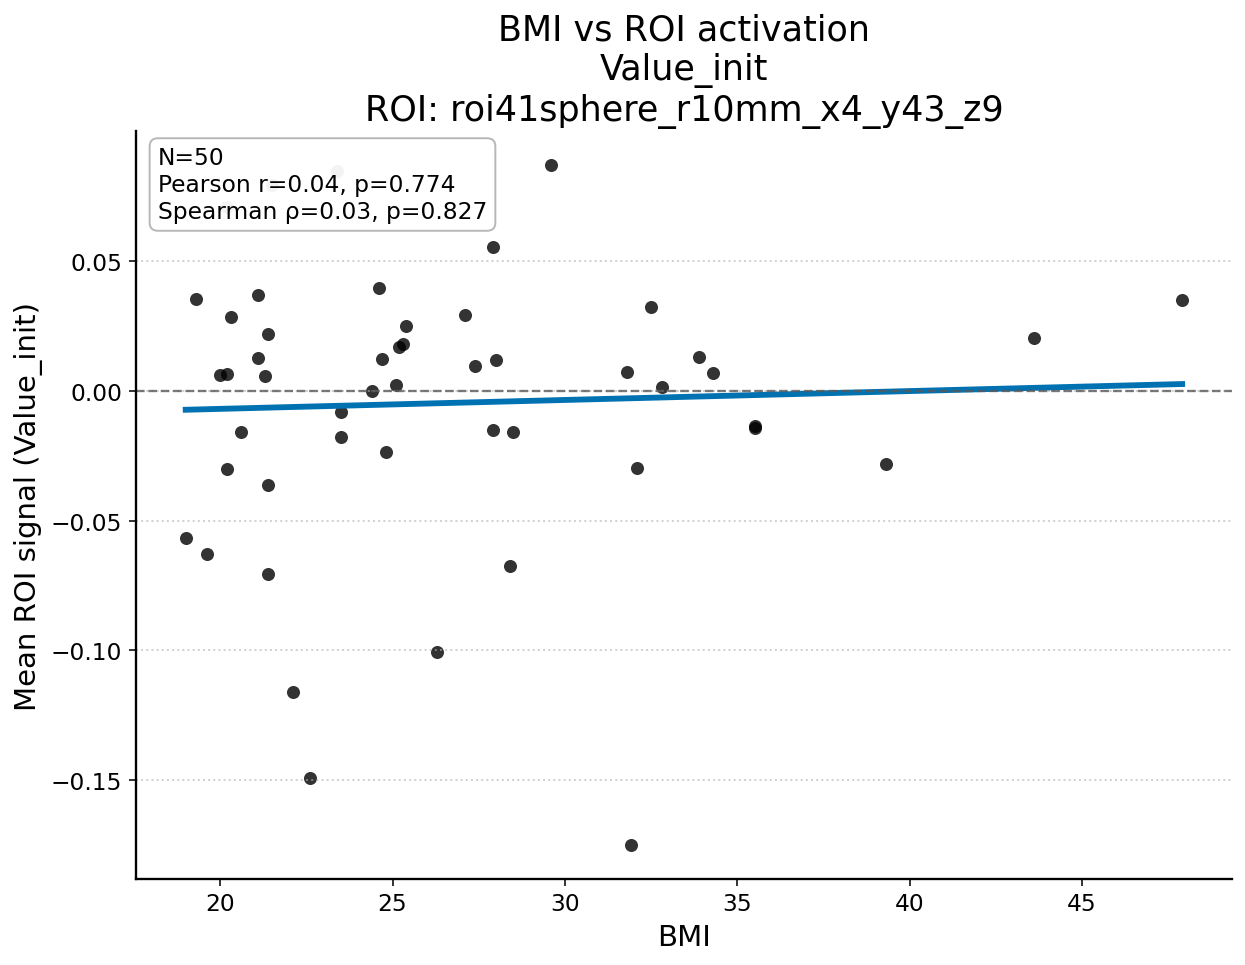

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures/roi41sphere_r10mm_x4_y43_z9_Value_init_BMI_correlation.jpeg
[OK] Saved merged data table: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures/roi41sphere_r10mm_x4_y43_z9_Value_init_BMI_roi_merged.csv


In [12]:
# Value_init sphere ROI: correlate BMI with mean ROI activation
# - Uses the existing sphere ROI mask
# - Uses the 4D Value_init file AND its saved subject order file
# - Loads survey_responses.csv, pulls BMI row (columns are subjects)
# - Aligns subjects by numeric 3-digit IDs (e.g., "2" -> "002")
# - Runs Pearson + Spearman correlations
# - Saves: ROI overlay (optional), correlation scatter with regression line, and merged data CSV

import os
import re
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn import input_data, plotting
from nilearn.image import load_img
from scipy import stats
import matplotlib.pyplot as plt

# -----------------------
# Helpers
# -----------------------
def safe_filename(s: str, maxlen: int = 140) -> str:
    s = s.strip()
    s = s.replace(">", "gt").replace("<", "lt")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s[:maxlen]

def normalize_to_digits3(s: str) -> str:
    """
    Canonical subject code: '002', '010', '221', etc.
    Works for: 2, '2', '002', 'FV002', 'sub-002', 'FVsub-002', etc.
    """
    s = str(s).strip()
    m = re.search(r"\b(\d{3})\b", s)
    if m:
        return m.group(1)
    m = re.search(r"(\d+)", s)
    if not m:
        raise ValueError(f"Could not extract digits from subject id: {s}")
    digits = m.group(1)
    return digits[-3:].zfill(3)

# -----------------------
# Plot settings
# -----------------------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
})

LINE_COLOR = "#0072B2"
ZERO_COLOR = "0.35"

# -----------------------
# Inputs
# -----------------------
contrast_key = "Value_init"

functional_img_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_init_all_sub_4d.nii.gz")
subject_order_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_init_all_sub_4d_subject_order.txt")

roi_mask_path = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz"
anat_img = load_img(str(MEAN_ANAT))

survey_csv = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/data/survey_responses.csv"
survey_row_name = "BMI"   # <-- CHANGED (was bes_GLOBAL)

# Labels for filenames
try:
    contrast_label = contrast_display_name(contrast_key)
except NameError:
    contrast_label = contrast_key

roi_label = "roi41sphere_r10mm_x4_y43_z9"

roi_slug = safe_filename(roi_label)
contrast_slug = safe_filename(contrast_label)

# Output folder
FIG_DIR = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_init_figures"
os.makedirs(FIG_DIR, exist_ok=True)

# -----------------------
# Load images
# -----------------------
functional_img = nib.load(functional_img_path)
roi_mask_img = nib.load(roi_mask_path)

print("ROI voxels:", int(np.sum(roi_mask_img.get_fdata() > 0)))

# -----------------------
# (Optional) Save ROI overlay
# -----------------------
display = plotting.plot_roi(
    roi_mask_img,
    bg_img=anat_img,
    title=f"ROI Mask (verification): {roi_label}",
    display_mode="ortho",
    draw_cross=False,
    colorbar=False,
)
roi_out = os.path.join(FIG_DIR, f"{roi_slug}_ROIMaskOverlay.jpeg")
display.savefig(roi_out, dpi=600)
display.close()
print(f"[OK] Saved: {roi_out}")

# -----------------------
# Load subject order (needed to align ROI values to survey columns)
# -----------------------
if not os.path.exists(subject_order_path):
    raise FileNotFoundError(
        f"Missing subject order file:\n{subject_order_path}\n"
        "Rebuild the 4D file with a builder that saves subject order."
    )

with open(subject_order_path, "r") as f:
    subject_order = [normalize_to_digits3(line.strip()) for line in f if line.strip()]

if functional_img.shape[3] != len(subject_order):
    raise ValueError(
        f"Mismatch: 4D has {functional_img.shape[3]} volumes but subject_order has {len(subject_order)} IDs."
    )

print("Example subject_order:", subject_order[:10])
print("N in 4D:", functional_img.shape[3])

# -----------------------
# Extract mean ROI signal per subject
# -----------------------
masker = input_data.NiftiMasker(
    mask_img=roi_mask_img,
    standardize=False,
    target_affine=functional_img.affine,
    target_shape=functional_img.shape[:3],
)
roi_vox = masker.fit_transform(functional_img)  # (n_subjects, n_voxels)
roi_mean = np.asarray(roi_vox.mean(axis=1)).ravel().astype(float)

roi_df = pd.DataFrame({
    "subject": subject_order,
    "roi_mean": roi_mean,
}).dropna(subset=["roi_mean"])

print(f"[INFO] ROI means available: N={len(roi_df)}")

# -----------------------
# Load survey CSV and pull BMI row
# -----------------------
survey_wide = pd.read_csv(survey_csv, sep=None, engine="python")  # auto-detect delimiter
row_label_col = survey_wide.columns[0]
survey_wide = survey_wide.set_index(row_label_col)

if survey_row_name not in survey_wide.index:
    raise KeyError(
        f"Row '{survey_row_name}' not found in {survey_csv}. "
        f"Check spelling/case. Example rows: {survey_wide.index[:20].tolist()} ..."
    )

bmi_series = survey_wide.loc[survey_row_name]  # columns are subject IDs

survey_long = (
    bmi_series.rename("BMI")
    .reset_index()
    .rename(columns={"index": "subject_raw"})
)

survey_long["subject"] = survey_long["subject_raw"].apply(normalize_to_digits3)
survey_long["BMI"] = pd.to_numeric(survey_long["BMI"], errors="coerce")
survey_long = survey_long.dropna(subset=["BMI"])

print(f"[INFO] BMI numeric values: N={len(survey_long)}")

# -----------------------
# Merge and correlate
# -----------------------
merged = pd.merge(
    roi_df,
    survey_long[["subject", "BMI"]],
    on="subject",
    how="inner",
).dropna(subset=["roi_mean", "BMI"])

n = int(len(merged))
print(f"[INFO] Overlap ROI x BMI: N={n}")
if n < 3:
    raise RuntimeError("Not enough overlapping subjects to compute correlation (need at least 3).")

x = merged["BMI"].to_numpy(dtype=float)
y = merged["roi_mean"].to_numpy(dtype=float)

r, p_r = stats.pearsonr(x, y)
rho, p_rho = stats.spearmanr(x, y)

print("\nCorrelation results (Value_init, sphere ROI; BMI):")
print(f"Pearson:  r = {r:.3f}, p = {p_r:.4g}")
print(f"Spearman: ρ = {rho:.3f}, p = {p_rho:.4g}")

# -----------------------
# Plot: scatter + regression line + stats box
# -----------------------
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(x, y, color="black", alpha=0.8, s=45, linewidths=0)

slope, intercept = np.polyfit(x, y, 1)
xx = np.linspace(np.min(x), np.max(x), 200)
yy = slope * xx + intercept
ax.plot(xx, yy, color=LINE_COLOR, linewidth=3)

ax.axhline(0, color=ZERO_COLOR, linestyle="--", linewidth=1.2, alpha=0.8)

ax.set_xlabel("BMI")
ax.set_ylabel("Mean ROI signal (Value_init)")
ax.set_title(f"BMI vs ROI activation\n{contrast_label}\nROI: {roi_label}")

stats_text = (
    f"N={n}\n"
    f"Pearson r={r:.2f}, p={p_r:.3g}\n"
    f"Spearman ρ={rho:.2f}, p={p_rho:.3g}"
)
ax.text(
    0.02, 0.98, stats_text,
    transform=ax.transAxes, va="top", ha="left",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.7", alpha=0.95),
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)

plt.tight_layout()

out_plot = os.path.join(FIG_DIR, f"{roi_slug}_{contrast_slug}_BMI_correlation.jpeg")
fig.savefig(out_plot, dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {out_plot}")

# -----------------------
# Save merged analysis table
# -----------------------
out_table = os.path.join(FIG_DIR, f"{roi_slug}_{contrast_slug}_BMI_roi_merged.csv")
merged.to_csv(out_table, index=False)
print(f"[OK] Saved merged data table: {out_table}")

##### Value_Model_Derived

ROI voxels: 528
[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_Model_Derived_figures/roi41sphere_r10mm_x4_y43_z9_ROIMaskOverlay.jpeg
Example subject_order: ['002', '003', '004', '005', '006', '007', '008', '010', '011', '012']
N in 4D: 50
[NiftiMasker.wrapped] Resampling images
[INFO] ROI means available: N=50
[INFO] BMI numeric values: N=52
[INFO] Overlap ROI x BMI: N=50

Correlation results (Value_init, sphere ROI; BMI):
Pearson:  r = -0.137, p = 0.3426
Spearman: ρ = -0.084, p = 0.5635


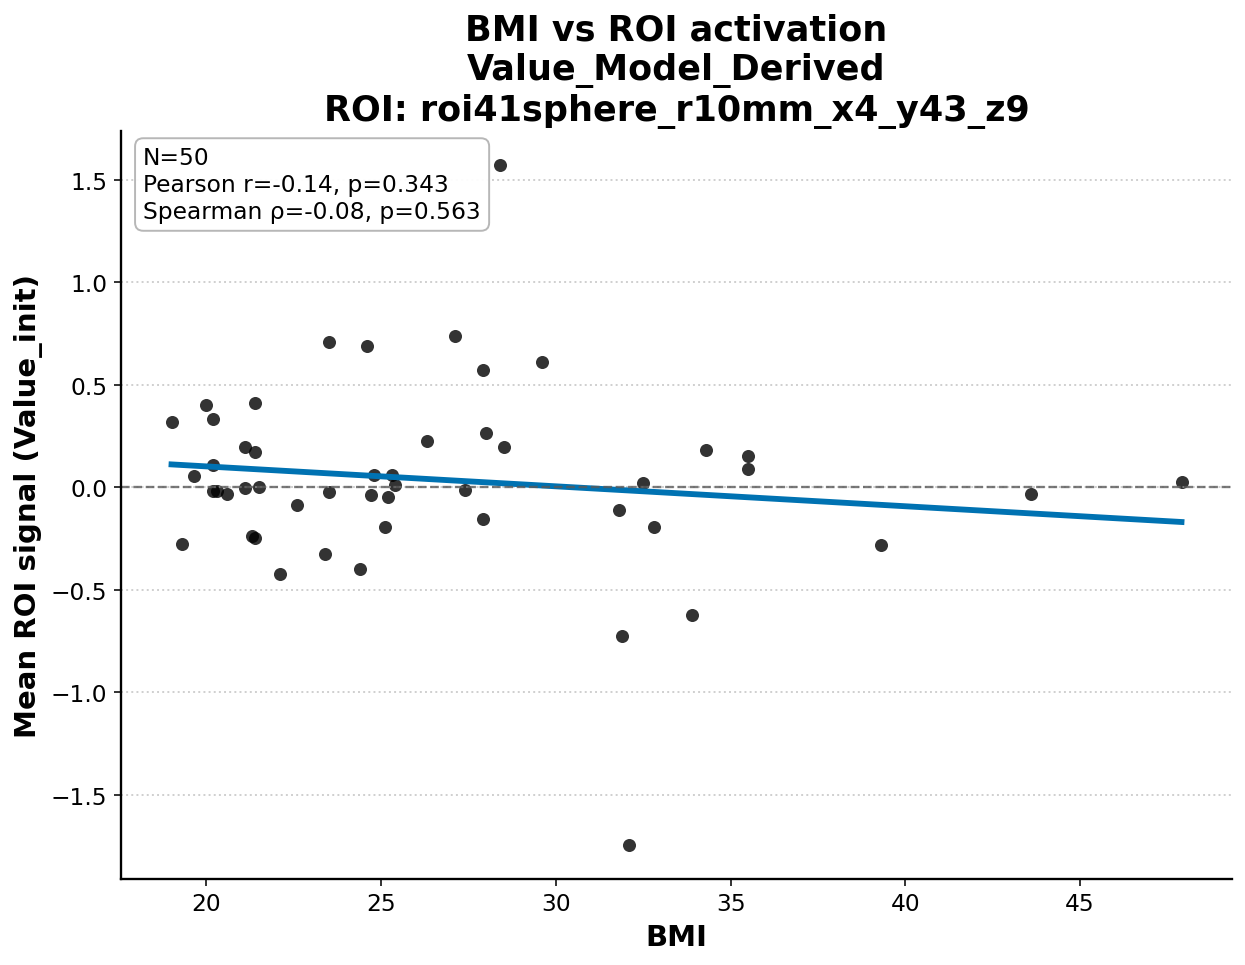

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_Model_Derived_figures/roi41sphere_r10mm_x4_y43_z9_Value_Model_Derived_BMI_correlation.jpeg
[OK] Saved merged data table: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_Model_Derived_figures/roi41sphere_r10mm_x4_y43_z9_Value_Model_Derived_BMI_roi_merged.csv


In [24]:
# Value_init sphere ROI: correlate BMI with mean ROI activation
# - Uses the existing sphere ROI mask
# - Uses the 4D Value_init file AND its saved subject order file
# - Loads survey_responses.csv, pulls BMI row (columns are subjects)
# - Aligns subjects by numeric 3-digit IDs (e.g., "2" -> "002")
# - Runs Pearson + Spearman correlations
# - Saves: ROI overlay (optional), correlation scatter with regression line, and merged data CSV

import os
import re
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn import input_data, plotting
from nilearn.image import load_img
from scipy import stats
import matplotlib.pyplot as plt

# -----------------------
# Helpers
# -----------------------
def safe_filename(s: str, maxlen: int = 140) -> str:
    s = s.strip()
    s = s.replace(">", "gt").replace("<", "lt")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s[:maxlen]

def normalize_to_digits3(s: str) -> str:
    """
    Canonical subject code: '002', '010', '221', etc.
    Works for: 2, '2', '002', 'FV002', 'sub-002', 'FVsub-002', etc.
    """
    s = str(s).strip()
    m = re.search(r"\b(\d{3})\b", s)
    if m:
        return m.group(1)
    m = re.search(r"(\d+)", s)
    if not m:
        raise ValueError(f"Could not extract digits from subject id: {s}")
    digits = m.group(1)
    return digits[-3:].zfill(3)

# -----------------------
# Plot settings
# -----------------------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
})

LINE_COLOR = "#0072B2"
ZERO_COLOR = "0.35"

# -----------------------
# Inputs
# -----------------------
contrast_key = "Value_Model_Derived"

functional_img_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_Model_Derived_all_sub_4d.nii.gz")
subject_order_path = os.path.join(str(OUTPUT_DIR), "none_glm_Value_Model_Derived_all_sub_4d_subject_order.txt")

roi_mask_path = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz"
anat_img = load_img(str(MEAN_ANAT))

survey_csv = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/data/survey_responses.csv"
survey_row_name = "BMI"   # <-- CHANGED (was bes_GLOBAL)

# Labels for filenames
try:
    contrast_label = contrast_display_name(contrast_key)
except NameError:
    contrast_label = contrast_key

roi_label = "roi41sphere_r10mm_x4_y43_z9"

roi_slug = safe_filename(roi_label)
contrast_slug = safe_filename(contrast_label)

# Output folder
FIG_DIR = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_Model_Derived_figures"
os.makedirs(FIG_DIR, exist_ok=True)

# -----------------------
# Load images
# -----------------------
functional_img = nib.load(functional_img_path)
roi_mask_img = nib.load(roi_mask_path)

print("ROI voxels:", int(np.sum(roi_mask_img.get_fdata() > 0)))

# -----------------------
# (Optional) Save ROI overlay
# -----------------------
display = plotting.plot_roi(
    roi_mask_img,
    bg_img=anat_img,
    title=f"ROI Mask (verification): {roi_label}",
    display_mode="ortho",
    draw_cross=False,
    colorbar=False,
)
roi_out = os.path.join(FIG_DIR, f"{roi_slug}_ROIMaskOverlay.jpeg")
display.savefig(roi_out, dpi=600)
display.close()
print(f"[OK] Saved: {roi_out}")

# -----------------------
# Load subject order (needed to align ROI values to survey columns)
# -----------------------
if not os.path.exists(subject_order_path):
    raise FileNotFoundError(
        f"Missing subject order file:\n{subject_order_path}\n"
        "Rebuild the 4D file with a builder that saves subject order."
    )

with open(subject_order_path, "r") as f:
    subject_order = [normalize_to_digits3(line.strip()) for line in f if line.strip()]

if functional_img.shape[3] != len(subject_order):
    raise ValueError(
        f"Mismatch: 4D has {functional_img.shape[3]} volumes but subject_order has {len(subject_order)} IDs."
    )

print("Example subject_order:", subject_order[:10])
print("N in 4D:", functional_img.shape[3])

# -----------------------
# Extract mean ROI signal per subject
# -----------------------
masker = input_data.NiftiMasker(
    mask_img=roi_mask_img,
    standardize=False,
    target_affine=functional_img.affine,
    target_shape=functional_img.shape[:3],
)
roi_vox = masker.fit_transform(functional_img)  # (n_subjects, n_voxels)
roi_mean = np.asarray(roi_vox.mean(axis=1)).ravel().astype(float)

roi_df = pd.DataFrame({
    "subject": subject_order,
    "roi_mean": roi_mean,
}).dropna(subset=["roi_mean"])

print(f"[INFO] ROI means available: N={len(roi_df)}")

# -----------------------
# Load survey CSV and pull BMI row
# -----------------------
survey_wide = pd.read_csv(survey_csv, sep=None, engine="python")  # auto-detect delimiter
row_label_col = survey_wide.columns[0]
survey_wide = survey_wide.set_index(row_label_col)

if survey_row_name not in survey_wide.index:
    raise KeyError(
        f"Row '{survey_row_name}' not found in {survey_csv}. "
        f"Check spelling/case. Example rows: {survey_wide.index[:20].tolist()} ..."
    )

bmi_series = survey_wide.loc[survey_row_name]  # columns are subject IDs

survey_long = (
    bmi_series.rename("BMI")
    .reset_index()
    .rename(columns={"index": "subject_raw"})
)

survey_long["subject"] = survey_long["subject_raw"].apply(normalize_to_digits3)
survey_long["BMI"] = pd.to_numeric(survey_long["BMI"], errors="coerce")
survey_long = survey_long.dropna(subset=["BMI"])

print(f"[INFO] BMI numeric values: N={len(survey_long)}")

# -----------------------
# Merge and correlate
# -----------------------
merged = pd.merge(
    roi_df,
    survey_long[["subject", "BMI"]],
    on="subject",
    how="inner",
).dropna(subset=["roi_mean", "BMI"])

n = int(len(merged))
print(f"[INFO] Overlap ROI x BMI: N={n}")
if n < 3:
    raise RuntimeError("Not enough overlapping subjects to compute correlation (need at least 3).")

x = merged["BMI"].to_numpy(dtype=float)
y = merged["roi_mean"].to_numpy(dtype=float)

r, p_r = stats.pearsonr(x, y)
rho, p_rho = stats.spearmanr(x, y)

print("\nCorrelation results (Value_init, sphere ROI; BMI):")
print(f"Pearson:  r = {r:.3f}, p = {p_r:.4g}")
print(f"Spearman: ρ = {rho:.3f}, p = {p_rho:.4g}")

# -----------------------
# Plot: scatter + regression line + stats box
# -----------------------
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(x, y, color="black", alpha=0.8, s=45, linewidths=0)

slope, intercept = np.polyfit(x, y, 1)
xx = np.linspace(np.min(x), np.max(x), 200)
yy = slope * xx + intercept
ax.plot(xx, yy, color=LINE_COLOR, linewidth=3)

ax.axhline(0, color=ZERO_COLOR, linestyle="--", linewidth=1.2, alpha=0.8)

ax.set_xlabel("BMI")
ax.set_ylabel("Mean ROI signal (Value_init)")
ax.set_title(f"BMI vs ROI activation\n{contrast_label}\nROI: {roi_label}")

stats_text = (
    f"N={n}\n"
    f"Pearson r={r:.2f}, p={p_r:.3g}\n"
    f"Spearman ρ={rho:.2f}, p={p_rho:.3g}"
)
ax.text(
    0.02, 0.98, stats_text,
    transform=ax.transAxes, va="top", ha="left",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.7", alpha=0.95),
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)

plt.tight_layout()

out_plot = os.path.join(FIG_DIR, f"{roi_slug}_{contrast_slug}_BMI_correlation.jpeg")
fig.savefig(out_plot, dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {out_plot}")

# -----------------------
# Save merged analysis table
# -----------------------
out_table = os.path.join(FIG_DIR, f"{roi_slug}_{contrast_slug}_BMI_roi_merged.csv")
merged.to_csv(out_table, index=False)
print(f"[OK] Saved merged data table: {out_table}")

# Making sure initial value and model-derived value predictors are not correlated

In [30]:
import os, glob
import numpy as np
import pandas as pd

OUTPUT_DIR = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_task_valuation2"
SUBJECT_LIST = ['007','030','002','003','004','005','006','008','010','011','012','013','016','017','019','020',
                '021','022','023','024','025','026','027','028','029','101','102','104','108','110','112','114',
                '116','117','119','121','124','201','204','205','207','209','211','212','213','214','215','219',
                '220','221']

COL_A = "resp_x_value_init"
COL_B = "resp_x_value_model_derived"

rows = []

for sid in SUBJECT_LIST:
    sub = f"sub-{sid}"
    dm_files = glob.glob(os.path.join(OUTPUT_DIR, sub, f"{sub}_ses-*_task-*_design_matrix.csv"))
    if not dm_files:
        print("[MISSING DM]", sub)
        continue

    for dm_path in dm_files:
        dm = pd.read_csv(dm_path, index_col=0)

        if (COL_A not in dm.columns) or (COL_B not in dm.columns):
            rows.append((sid, os.path.basename(dm_path), np.nan))
            continue

        a = dm[COL_A].to_numpy(dtype=float)
        b = dm[COL_B].to_numpy(dtype=float)

        # correlation of the *actual* regressors in the GLM
        r = np.corrcoef(a, b)[0, 1]
        rows.append((sid, os.path.basename(dm_path), r))

out = pd.DataFrame(rows, columns=["sub", "design_matrix", "r_dm"])
print(out["r_dm"].describe())
print(out.sort_values("r_dm").head(10))
print(out.sort_values("r_dm", ascending=False).head(10))

count    50.000000
mean      0.031144
std       0.291869
min      -0.843147
25%      -0.071429
50%      -0.012068
75%       0.072532
max       0.869934
Name: r_dm, dtype: float64
    sub                                  design_matrix      r_dm
35  121  sub-121_ses-1_task-learning_design_matrix.csv -0.843147
45  214  sub-214_ses-1_task-learning_design_matrix.csv -0.687371
39  205  sub-205_ses-1_task-learning_design_matrix.csv -0.239259
18  023  sub-023_ses-1_task-learning_design_matrix.csv -0.173260
2   002  sub-002_ses-1_task-learning_design_matrix.csv -0.157221
12  016  sub-016_ses-1_task-learning_design_matrix.csv -0.141089
14  019  sub-019_ses-1_task-learning_design_matrix.csv -0.129466
6   006  sub-006_ses-1_task-learning_design_matrix.csv -0.124619
33  117  sub-117_ses-1_task-learning_design_matrix.csv -0.113287
19  024  sub-024_ses-1_task-learning_design_matrix.csv -0.099880
    sub                                  design_matrix      r_dm
30  112  sub-112_ses-1_task-learning_desi

In [34]:
import os, glob
import numpy as np
import pandas as pd

# -----------------------
# Configure
# -----------------------
OUTPUT_DIR = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_task_valuation2"

SUBJECT_LIST = ['007','030','002','003','004','005','006','008','010','011','012','013','016','017','019','020',
                '021','022','023','024','025','026','027','028','029','101','102','104','108','110','112','114',
                '116','117','119','121','124','201','204','205','207','209','211','212','213','214','215','219',
                '220','221']

RUN_GLOB = "sub-*_ses-*_task-*_design_matrix.csv"

COL_RESP = "resp"
COL_A    = "resp_x_value_init"
COL_B    = "resp_x_value_model_derived"

# Optional: include other task regressors you care about
EXTRA_TASK_COLS = ["baseline", "outcome", "toolate"]

# -----------------------
# Helpers
# -----------------------
def corr_safe(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size < 3:
        return np.nan
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])

def vif_from_corr(r):
    # For 2 predictors only; still useful as a quick collinearity gauge
    if not np.isfinite(r):
        return np.nan
    denom = 1.0 - r**2
    return float(1.0 / denom) if denom > 0 else np.inf

def vifs_for_columns(dm, cols):
    """
    General VIF: for each column j, regress it on the others, VIF_j = 1/(1-R^2).
    Uses least squares; no sklearn required.
    """
    cols = [c for c in cols if c in dm.columns]
    if len(cols) < 2:
        return {c: np.nan for c in cols}

    Xall = dm[cols].to_numpy(dtype=float)
    out = {}

    for j, name in enumerate(cols):
        y = Xall[:, j]
        X = np.delete(Xall, j, axis=1)

        # drop rows with any non-finite values
        m = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
        y2 = y[m]
        X2 = X[m, :]
        if y2.size < 5:
            out[name] = np.nan
            continue

        # add intercept
        X2i = np.column_stack([np.ones(X2.shape[0]), X2])

        # if y is (near) constant, VIF not meaningful
        if np.std(y2) == 0:
            out[name] = np.nan
            continue

        beta, *_ = np.linalg.lstsq(X2i, y2, rcond=None)
        yhat = X2i @ beta

        ss_res = float(np.sum((y2 - yhat) ** 2))
        ss_tot = float(np.sum((y2 - np.mean(y2)) ** 2))
        R2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

        if not np.isfinite(R2):
            out[name] = np.nan
        elif R2 >= 1.0:
            out[name] = np.inf
        else:
            out[name] = float(1.0 / (1.0 - R2))

    return out

# -----------------------
# Main: loop through saved design matrices
# -----------------------
rows = []

for sid in SUBJECT_LIST:
    sub = f"sub-{sid}"
    dm_files = glob.glob(os.path.join(OUTPUT_DIR, sub, RUN_GLOB))
    if not dm_files:
        print("[MISSING DM]", sub)
        continue

    for dm_path in sorted(dm_files):
        dm = pd.read_csv(dm_path, index_col=0)

        cols_present = set(dm.columns)

        r_ab    = corr_safe(dm.get(COL_A, np.nan),    dm.get(COL_B, np.nan))
        r_aresp = corr_safe(dm.get(COL_A, np.nan),    dm.get(COL_RESP, np.nan))
        r_bresp = corr_safe(dm.get(COL_B, np.nan),    dm.get(COL_RESP, np.nan))

        # Quick 2-predictor VIF proxy just for A~B collinearity
        vif_ab = vif_from_corr(r_ab)

        # General VIFs for a small task-regressor set (if present)
        task_cols = [c for c in [COL_RESP, COL_A, COL_B] + EXTRA_TASK_COLS if c in cols_present]
        vifs = vifs_for_columns(dm, task_cols)

        row = {
            "sub": sid,
            "design_matrix": os.path.basename(dm_path),
            "r(A,B)": r_ab,
            "VIF_from_r(A,B)": vif_ab,
            "r(A,resp)": r_aresp,
            "r(B,resp)": r_bresp,
        }
        # add VIF columns
        for k, v in vifs.items():
            row[f"VIF_{k}"] = v

        rows.append(row)

out = pd.DataFrame(rows)

# -----------------------
# Summaries
# -----------------------
pd.set_option("display.max_columns", 200)

print("\n=== Correlations summary (design-matrix level) ===")
print(out[["r(A,B)", "r(A,resp)", "r(B,resp)", "VIF_from_r(A,B)"]].describe())

print("\n=== Worst collinearity between modulators (|r(A,B)| high) ===")
tmp = out.copy()
tmp["abs_r(A,B)"] = tmp["r(A,B)"].abs()
print(tmp.sort_values("abs_r(A,B)", ascending=False)[["sub","design_matrix","r(A,B)","VIF_from_r(A,B)"]].head(15))

# Show VIF summaries if computed
vif_cols = [c for c in out.columns if c.startswith("VIF_")]
if vif_cols:
    print("\n=== VIF summary (selected task regressors) ===")
    print(out[vif_cols].describe())


=== Correlations summary (design-matrix level) ===
          r(A,B)  r(A,resp)  r(B,resp)  VIF_from_r(A,B)
count  50.000000  50.000000  50.000000        50.000000
mean    0.031144  -0.003367  -0.001431         1.227354
std     0.291869   0.027722   0.026566         0.654888
min    -0.843147  -0.085924  -0.061475         1.000062
25%    -0.071429  -0.018832  -0.019593         1.001016
50%    -0.012068  -0.002738  -0.001300         1.005514
75%     0.072532   0.012810   0.014461         1.020544
max     0.869934   0.051042   0.061723         4.111583

=== Worst collinearity between modulators (|r(A,B)| high) ===
    sub                                  design_matrix    r(A,B)  \
30  112  sub-112_ses-1_task-learning_design_matrix.csv  0.869934   
35  121  sub-121_ses-1_task-learning_design_matrix.csv -0.843147   
44  213  sub-213_ses-1_task-learning_design_matrix.csv  0.830876   
24  029  sub-029_ses-1_task-learning_design_matrix.csv  0.708637   
5   005  sub-005_ses-1_task-learning_desi

# Comparing Value_init to Value_model_derived: which accounts better for activation in vmPFC spherical ROI? 

If the paired difference Value_model_derived − Value_init is reliably > 0, that supports stronger vmPFC encoding for the model-derived value (given your pipeline that generated these beta images). If it’s reliably < 0, that supports stronger encoding for initial stored value. If it’s near 0 with wide CI, your ROI doesn’t differentiate the two regressors (or the regressors are too collinear / underpowered).

ROI voxels: 528
Initial Value image: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_task_valuation2/none_glm_Value_init_all_sub_4d.nii.gz
Model-Derived Value image: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_task_valuation2/none_glm_Value_Model_Derived_all_sub_4d.nii.gz
[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_compare_figures/10-mm_sphere_MNI_-4_43_-9_ROIMaskOverlay.jpeg

ROI comparison
ROI: 10-mm sphere MNI [-4, 43, -9]
N=50, df=49
Initial Value: mean=-0.004928, 95% CI [-0.019337, 0.009482], t(49)=-0.687, p=0.4952, d=-0.097
Model-Derived Value: mean=0.039409, 95% CI [-0.090727, 0.169545], t(49)=0.609, p=0.5456, d=0.086
Paired (Model-Derived Value − Initial Value): mean=0.044337, 95% CI [-0.084712, 0.173386], t(49)=0.690, p=0.4932, dz=0.098
Corr(Initial Value,Model-Derived Value): r=0.130, p=0.3664
Wilcoxon paired (Model-Derived Value − Initial Value): W=569.000, p=0.5148
[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvalua

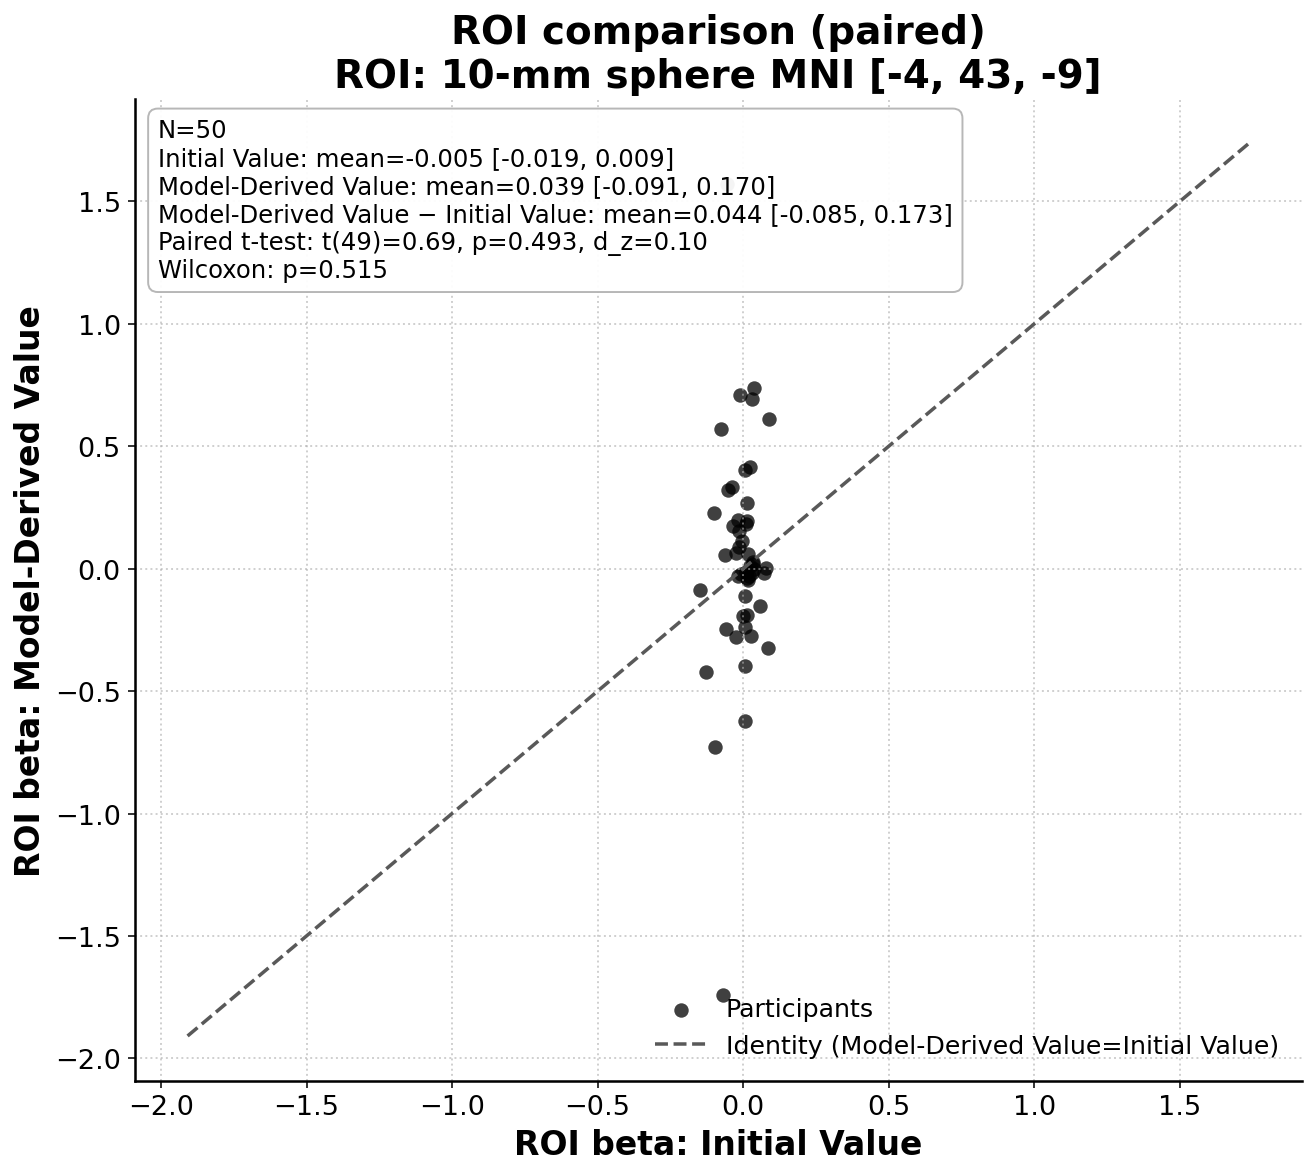

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_compare_figures/10-mm_sphere_MNI_-4_43_-9_Initial_Value_vs_Model-Derived_Value_PairedScatter.jpeg


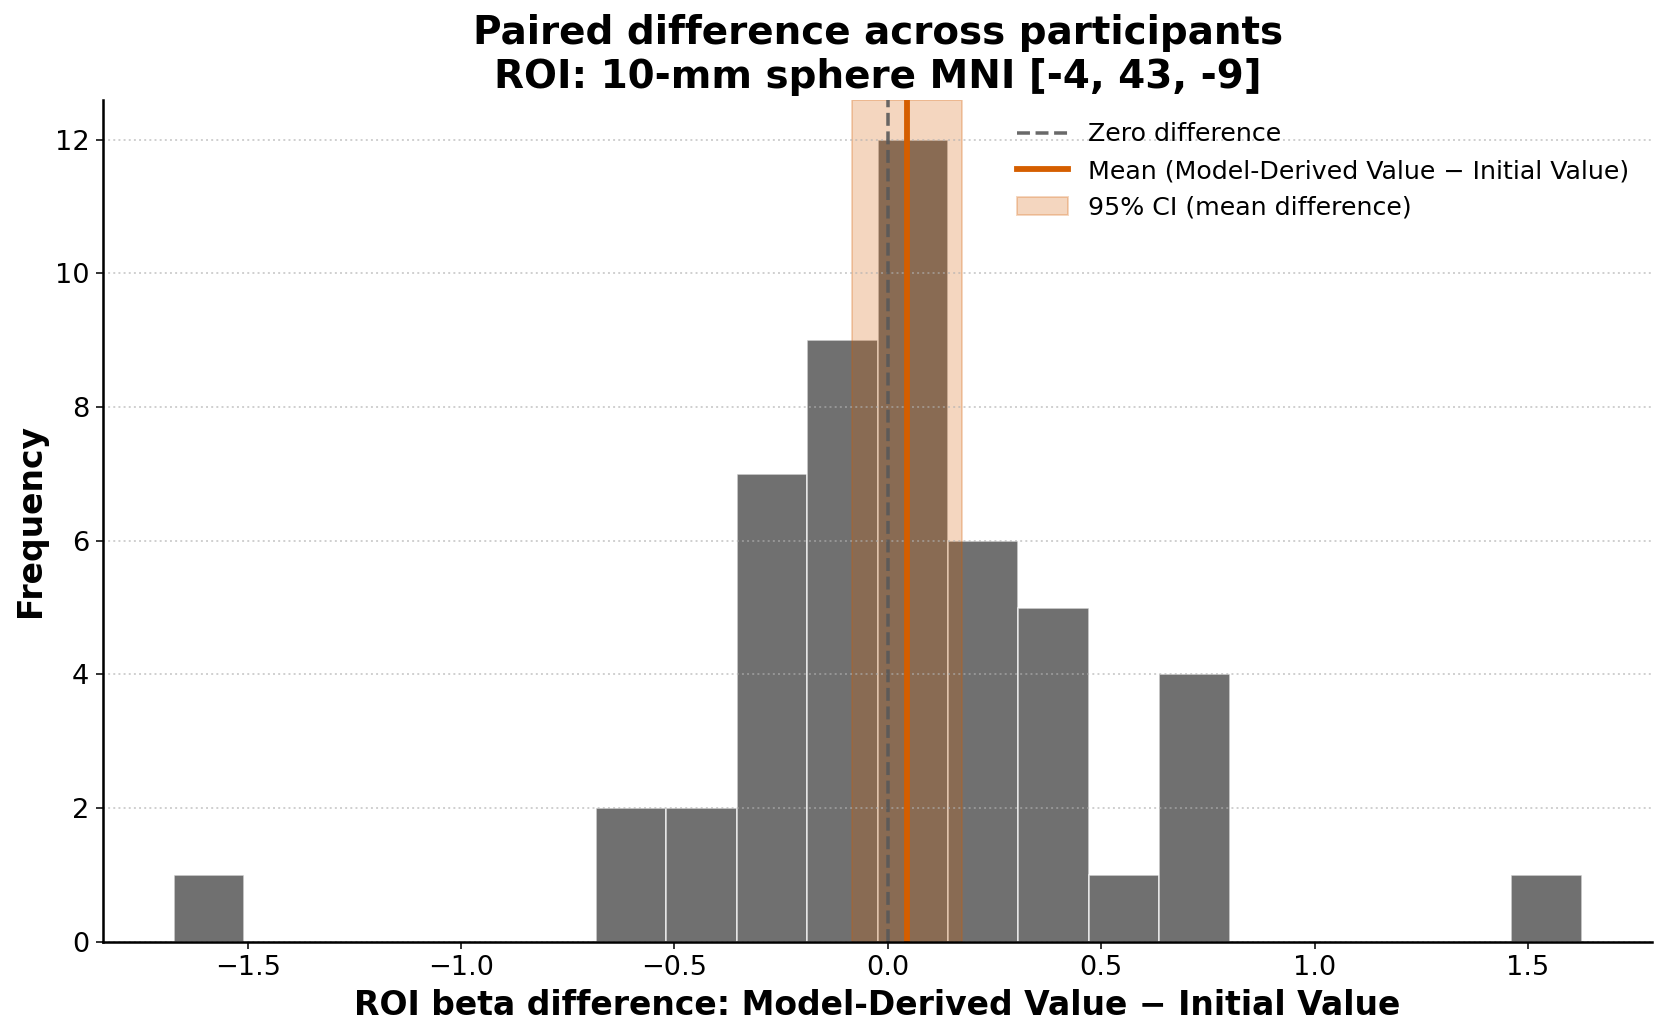

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_compare_figures/10-mm_sphere_MNI_-4_43_-9_Initial_Value_vs_Model-Derived_Value_DiffHistogram.jpeg


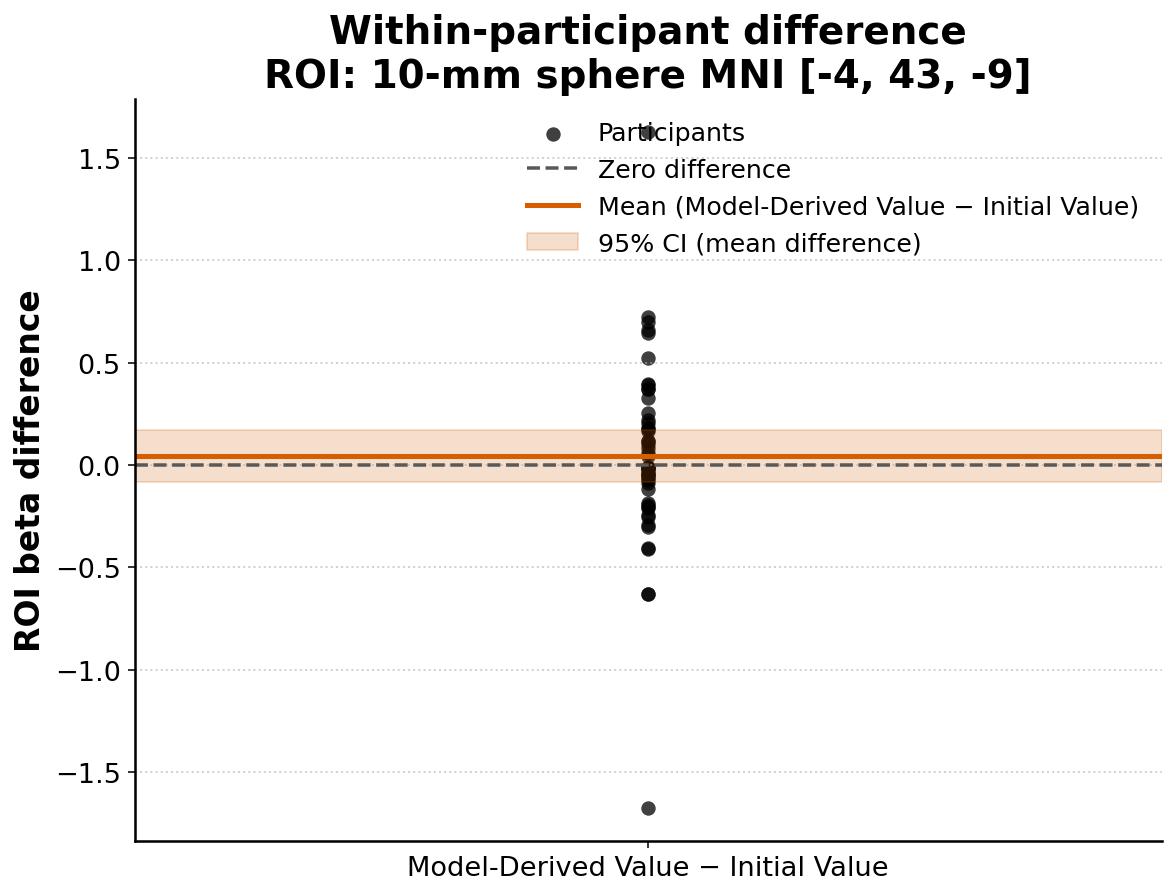

[OK] Saved: /nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_compare_figures/10-mm_sphere_MNI_-4_43_-9_Initial_Value_vs_Model-Derived_Value_DiffDotPlot.jpeg


In [38]:
import os
import re
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn import input_data, plotting
from nilearn.image import load_img
from scipy import stats
import matplotlib.pyplot as plt

# =============================================================================
# ROI comparison script: Initial Value vs Model-Derived Value (same GLM betas)
# =============================================================================

# -----------------------
# Helpers
# -----------------------
def mean_ci_t(x, confidence=0.95):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.size
    mean = float(np.mean(x))
    sem = float(stats.sem(x)) if n > 1 else np.nan
    df = n - 1
    tcrit = float(stats.t.ppf((1 + confidence) / 2, df)) if df > 0 else np.nan
    half = tcrit * sem if (np.isfinite(tcrit) and np.isfinite(sem)) else np.nan
    return mean, (mean - half, mean + half)

def cohens_d_onesample(x, mu0=0.0):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    sd = float(np.std(x, ddof=1)) if x.size > 1 else np.nan
    return float((np.mean(x) - mu0) / sd) if (np.isfinite(sd) and sd != 0) else np.nan

def cohens_d_paired(x, y):
    """Cohen's dz for paired samples = mean(diff) / sd(diff)."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = ~np.isnan(x) & ~np.isnan(y)
    d = x[m] - y[m]
    sd = float(np.std(d, ddof=1)) if d.size > 1 else np.nan
    return float(np.mean(d) / sd) if (np.isfinite(sd) and sd != 0) else np.nan

def safe_filename(s: str, maxlen: int = 140) -> str:
    s = s.strip()
    s = s.replace(">", "gt").replace("<", "lt")
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s[:maxlen]

def corr_safe(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size < 3:
        return np.nan, np.nan
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan
    r, p = stats.pearsonr(x, y)
    return float(r), float(p)

# -----------------------
# Plot settings
# -----------------------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "axes.titlesize": 20,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "axes.linewidth": 1.3,
})

MEAN_COLOR = "#0072B2"
ALT_COLOR  = "#D55E00"   # Okabe–Ito vermillion
ZERO_COLOR = "0.35"

# -----------------------
# Inputs you must define in your environment (as in your other scripts)
# -----------------------
# OUTPUT_DIR: base output directory containing the 4D images
# MEAN_ANAT: path to mean anatomical image for overlay

# -----------------------
# Regressors / files
# -----------------------
contrast_a_key = "Value_init"
contrast_b_key = "Value_Model_Derived"

contrast_a_label = "Initial Value"
contrast_b_label = "Model-Derived Value"
diff_label = f"{contrast_b_label} − {contrast_a_label}"  # explicit

functional_a_path = os.path.join(str(OUTPUT_DIR), f"none_glm_{contrast_a_key}_all_sub_4d.nii.gz")
functional_b_path = os.path.join(str(OUTPUT_DIR), f"none_glm_{contrast_b_key}_all_sub_4d.nii.gz")

roi_mask_path = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/results/nilearn_parametric/ROI/sphere_r10mm_x-4_y43_z-9_mask_RANKREGRESSION.nii.gz"
roi_label = "10-mm sphere MNI [-4, 43, -9]"

anat_img = load_img(str(MEAN_ANAT))

roi_slug = safe_filename(roi_label)
a_slug = safe_filename(contrast_a_label)
b_slug = safe_filename(contrast_b_label)

# -----------------------
# Output
# -----------------------
FIG_DIR = "/nfs/roberts/pi/pi_il77/Alex/foodvaluation/output/Valuation/Value_compare_figures"
os.makedirs(FIG_DIR, exist_ok=True)

# -----------------------
# Load images
# -----------------------
img_a = nib.load(functional_a_path)
img_b = nib.load(functional_b_path)
roi_mask_img = nib.load(roi_mask_path)

print("ROI voxels:", int(np.sum(roi_mask_img.get_fdata() > 0)))
print(f"{contrast_a_label} image:", functional_a_path)
print(f"{contrast_b_label} image:", functional_b_path)

# Sanity checks
if img_a.shape[:3] != img_b.shape[:3]:
    raise ValueError("Spatial dimensions differ between images.")
if img_a.shape[3] != img_b.shape[3]:
    raise ValueError(f"Different n_subjects: A has {img_a.shape[3]}, B has {img_b.shape[3]}.")

# -----------------------
# Figure 1: ROI overlay
# -----------------------
display = plotting.plot_roi(
    roi_mask_img,
    bg_img=anat_img,
    title=f"ROI Mask (verification): {roi_label}",
    display_mode="ortho",
    draw_cross=False,
    colorbar=False
)
roi_out = os.path.join(FIG_DIR, f"{roi_slug}_ROIMaskOverlay.jpeg")
display.savefig(roi_out, dpi=600)
display.close()
print(f"[OK] Saved: {roi_out}")

# -----------------------
# Extract mean ROI beta per subject for each regressor
# -----------------------
masker = input_data.NiftiMasker(mask_img=roi_mask_img, standardize=False)
masker.fit()

roi_a = masker.transform(img_a)  # (n_sub, n_vox)
roi_b = masker.transform(img_b)

x_a = np.asarray(roi_a.mean(axis=1)).ravel().astype(float)
x_b = np.asarray(roi_b.mean(axis=1)).ravel().astype(float)

m = np.isfinite(x_a) & np.isfinite(x_b)
x_a = x_a[m]
x_b = x_b[m]

n = int(x_a.size)
df = n - 1

diff = x_b - x_a  # positive => Model-Derived > Initial

# -----------------------
# Stats
# -----------------------
t_a, p_a = stats.ttest_1samp(x_a, popmean=0.0)
t_b, p_b = stats.ttest_1samp(x_b, popmean=0.0)

d_a = cohens_d_onesample(x_a, 0.0)
d_b = cohens_d_onesample(x_b, 0.0)

mean_a, (a_lo, a_hi) = mean_ci_t(x_a)
mean_b, (b_lo, b_hi) = mean_ci_t(x_b)

t_p, p_p = stats.ttest_rel(x_b, x_a)
d_p = cohens_d_paired(x_b, x_a)
mean_d, (d_lo, d_hi) = mean_ci_t(diff)

r_ab, p_ab = corr_safe(x_a, x_b)

try:
    w_stat, p_w = stats.wilcoxon(x_b, x_a, zero_method="wilcox", alternative="two-sided")
    w_stat = float(w_stat); p_w = float(p_w)
except Exception:
    w_stat, p_w = np.nan, np.nan

print("\nROI comparison")
print(f"ROI: {roi_label}")
print(f"N={n}, df={df}")
print(f"{contrast_a_label}: mean={mean_a:.6f}, 95% CI [{a_lo:.6f}, {a_hi:.6f}], "
      f"t({df})={float(t_a):.3f}, p={float(p_a):.4g}, d={d_a:.3f}")
print(f"{contrast_b_label}: mean={mean_b:.6f}, 95% CI [{b_lo:.6f}, {b_hi:.6f}], "
      f"t({df})={float(t_b):.3f}, p={float(p_b):.4g}, d={d_b:.3f}")
print(f"Paired ({diff_label}): mean={mean_d:.6f}, 95% CI [{d_lo:.6f}, {d_hi:.6f}], "
      f"t({df})={float(t_p):.3f}, p={float(p_p):.4g}, dz={d_p:.3f}")
print(f"Corr({contrast_a_label},{contrast_b_label}): r={r_ab:.3f}, p={p_ab:.4g}")
print(f"Wilcoxon paired ({diff_label}): W={w_stat:.3f}, p={p_w:.4g}")

# Explicit, readable inset text (no A/B shorthand)
stats_text = (
    f"N={n}\n"
    f"{contrast_a_label}: mean={mean_a:.3f} [{a_lo:.3f}, {a_hi:.3f}]\n"
    f"{contrast_b_label}: mean={mean_b:.3f} [{b_lo:.3f}, {b_hi:.3f}]\n"
    f"{diff_label}: mean={mean_d:.3f} [{d_lo:.3f}, {d_hi:.3f}]\n"
    f"Paired t-test: t({df})={float(t_p):.2f}, p={float(p_p):.3g}, d_z={d_p:.2f}\n"
    f"Wilcoxon: p={p_w:.3g}"
)

# -----------------------
# Save per-subject ROI values
# -----------------------
roi_df = pd.DataFrame({
    "beta_initial_value": x_a,
    "beta_model_derived_value": x_b,
    "diff_model_derived_minus_initial": diff
})
roi_csv = os.path.join(FIG_DIR, f"{roi_slug}_{a_slug}_vs_{b_slug}_ROIbetas.csv")
roi_df.to_csv(roi_csv, index=False)
print(f"[OK] Saved: {roi_csv}")

# -----------------------
# Figure 2: paired scatter with identity line
# -----------------------
fig, ax = plt.subplots(figsize=(9.5, 8.5))
ax.scatter(x_a, x_b, s=55, color="black", alpha=0.75, linewidths=0, label="Participants")

lims = [np.nanmin([x_a.min(), x_b.min()]), np.nanmax([x_a.max(), x_b.max()])]
pad = 0.05 * (lims[1] - lims[0] if lims[1] > lims[0] else 1.0)

ax.plot([lims[0]-pad, lims[1]+pad], [lims[0]-pad, lims[1]+pad],
        linestyle="--", color=ZERO_COLOR, linewidth=1.8,
        label=f"Identity ({contrast_b_label}={contrast_a_label})")

ax.set_xlabel(f"ROI beta: {contrast_a_label}")
ax.set_ylabel(f"ROI beta: {contrast_b_label}")
ax.set_title(f"ROI comparison (paired)\nROI: {roi_label}")

ax.grid(True, linestyle=":", linewidth=1.0, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0.02, 0.98, stats_text,
    transform=ax.transAxes, va="top", ha="left",
    fontsize=12.5,
    bbox=dict(boxstyle="round,pad=0.40", facecolor="white", edgecolor="0.7", alpha=0.95)
)

ax.legend(frameon=False, loc="lower right")
plt.tight_layout()

out_scatter = os.path.join(FIG_DIR, f"{roi_slug}_{a_slug}_vs_{b_slug}_PairedScatter.jpeg")
fig.savefig(out_scatter, format="jpeg", dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {out_scatter}")

# -----------------------
# Figure 3: histogram of paired differences
# -----------------------
fig2, ax2 = plt.subplots(figsize=(12, 7.5))
ax2.hist(diff, bins=20, color="0.25", alpha=0.75, edgecolor="white", linewidth=0.8)

ax2.axvline(x=0, color=ZERO_COLOR, linestyle="--", linewidth=1.8, alpha=0.9,
            label="Zero difference")
ax2.axvline(mean_d, color=ALT_COLOR, linewidth=3.0, label=f"Mean ({diff_label})")
ax2.axvspan(d_lo, d_hi, color=ALT_COLOR, alpha=0.25, label="95% CI (mean difference)")

ax2.set_xlabel(f"ROI beta difference: {diff_label}")
ax2.set_ylabel("Frequency")
ax2.set_title(f"Paired difference across participants\nROI: {roi_label}")

ax2.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

#ax2.text(
#    0.02, 0.98, stats_text,
#    transform=ax2.transAxes, va="top", ha="left",
#    fontsize=13,
#    bbox=dict(boxstyle="round,pad=0.40", facecolor="white", edgecolor="0.7", alpha=0.95)
#)

ax2.legend(frameon=False, loc="upper right")
plt.tight_layout()

out_hist = os.path.join(FIG_DIR, f"{roi_slug}_{a_slug}_vs_{b_slug}_DiffHistogram.jpeg")
fig2.savefig(out_hist, format="jpeg", dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {out_hist}")

# -----------------------
# Figure 4: dot plot of paired differences
# -----------------------
fig4, ax4 = plt.subplots(figsize=(8.5, 6.5))
ax4.scatter(np.ones_like(diff), diff, s=55, color="black", alpha=0.75, linewidths=0,
            label="Participants")
ax4.axhline(0, linestyle="--", color=ZERO_COLOR, linewidth=1.8, label="Zero difference")

ax4.axhline(mean_d, color=ALT_COLOR, linewidth=2.6, label=f"Mean ({diff_label})")
ax4.axhspan(d_lo, d_hi, color=ALT_COLOR, alpha=0.20, label="95% CI (mean difference)")

ax4.set_xlim(0.7, 1.3)
ax4.set_xticks([1.0])
ax4.set_xticklabels([diff_label])
ax4.set_ylabel("ROI beta difference")
ax4.set_title(f"Within-participant difference\nROI: {roi_label}")

ax4.grid(True, axis="y", linestyle=":", linewidth=1.0, alpha=0.6)
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)
ax4.legend(frameon=False, loc="upper right")

plt.tight_layout()
out_diffplot = os.path.join(FIG_DIR, f"{roi_slug}_{a_slug}_vs_{b_slug}_DiffDotPlot.jpeg")
fig4.savefig(out_diffplot, format="jpeg", dpi=600, bbox_inches="tight")
plt.show()
print(f"[OK] Saved: {out_diffplot}")